# Advanced Behavioral Spotify EDA

## Research question

**How does my music listening behavior change across different contexts, especially on special days such as exams, deadlines, and stress periods?**

This notebook treats Spotify listening history as behavioral event data. Each row is a listening event, and the goal is to transform those events into interpretable behavioral signals:

- **Intensity:** how much time I spend listening.
- **Frequency:** how many listening events happen.
- **Engagement:** whether I skip, shuffle, or end tracks early.
- **Diversity:** whether I repeat familiar music or explore more artists and tracks.
- **Context sensitivity:** whether exams, deadlines, and stress periods shift these behaviors.

The notebook is exploratory, but it is designed to produce research-level insights that can guide formal hypothesis testing later.


# Section 1 — Setup

This notebook uses only `pandas` and `matplotlib`. The code is written defensively because exported Spotify files may have slightly different column names.


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

BASE_DIR = Path.home() / "Desktop" / "DSA210 TERM PROJECT"
SPOTIFY_PATH = BASE_DIR /"extended_streaming_history_data"/ "spotify_cleaned.csv"
SPECIAL_DATES_PATH = BASE_DIR / "special_days_data"/ "special_dates.csv"

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

print("Project folder:", BASE_DIR)
print("Spotify file exists:", SPOTIFY_PATH.exists())
print("Special dates file exists:", SPECIAL_DATES_PATH.exists())


Project folder: /Users/boratansoy/Desktop/DSA210 TERM PROJECT
Spotify file exists: True
Special dates file exists: True


# Section 2 — Data overview

The project combines event-level Spotify listening history with daily calendar labels. The first dataset captures what I listened to and how I interacted with it. The second dataset gives contextual labels such as exam days, deadlines, and stress periods.


In [2]:
def resolve_project_file(filename, preferred_path):
    """Return the preferred path when present, otherwise search inside BASE_DIR."""
    preferred_path = Path(preferred_path)
    if preferred_path.exists():
        return preferred_path

    matches = sorted(BASE_DIR.rglob(filename))
    if matches:
        return matches[0]

    raise FileNotFoundError(
        f"Missing {filename}. Expected it at {preferred_path} or somewhere under {BASE_DIR}."
    )


SPOTIFY_PATH = resolve_project_file("spotify_cleaned.csv", SPOTIFY_PATH)
SPECIAL_DATES_PATH = resolve_project_file("special_dates.csv", SPECIAL_DATES_PATH)

spotify_raw = pd.read_csv(SPOTIFY_PATH)
special_raw = pd.read_csv(SPECIAL_DATES_PATH)

print("Spotify data path:", SPOTIFY_PATH)
print("Special dates path:", SPECIAL_DATES_PATH)
print("spotify_raw shape:", spotify_raw.shape)
print("special_raw shape:", special_raw.shape)

display(spotify_raw.head())
display(special_raw.head())

Spotify data path: /Users/boratansoy/Desktop/DSA210 TERM PROJECT/extended_streaming_history_data/spotify_cleaned.csv
Special dates path: /Users/boratansoy/Desktop/DSA210 TERM PROJECT/special_days_data/special_dates.csv
spotify_raw shape: (175826, 12)
special_raw shape: (251, 8)


,ts,date,hour,weekday,ms_played,master_metadata_track_name,master_metadata_album_artist_name,reason_start,reason_end,shuffle,skipped,session_id
0,2018-09-21 16:18:51+00:00,2018-09-21,16,Friday,197560,Mary Jane (Ilkay Şencan Remix),Burry Soprano,clickrow,trackdone,False,False,0
1,2018-09-21 16:21:06+00:00,2018-09-21,16,Friday,9980,Uyan,Velet,trackdone,endplay,False,False,0
2,2018-09-21 16:58:43+00:00,2018-09-21,16,Friday,83360,"RAF (feat. A$AP Rocky, Playboi Carti, Quavo, L...",A$AP Mob,clickrow,logout,False,False,1
3,2018-09-21 17:01:45+00:00,2018-09-21,17,Friday,166470,"RAF (feat. A$AP Rocky, Playboi Carti, Quavo, L...",A$AP Mob,appload,endplay,False,False,1
4,2018-09-21 17:05:14+00:00,2018-09-21,17,Friday,209680,Gorgeous,Taylor Swift,clickrow,trackdone,False,False,1


,date,is_exam,is_deadline,is_academic_event,is_personal,is_stress_period,source_events,categories
0,2024-07-15,0,0,0,0,1,Ehliyet E-sınav,stress_before_exam
1,2024-07-16,0,0,0,0,1,Ehliyet E-sınav,stress_before_exam
2,2024-07-17,0,0,0,0,1,Ehliyet E-sınav,stress_before_exam
3,2024-07-18,0,0,0,0,1,Ehliyet E-sınav,stress_before_exam
4,2024-07-19,0,0,0,0,1,Ehliyet E-sınav,stress_before_exam


In [3]:
print("Spotify columns")
display(pd.DataFrame({"column": spotify_raw.columns}))

print("Special-date columns")
display(pd.DataFrame({"column": special_raw.columns}))


Spotify columns


,column
0,ts
1,date
2,hour
3,weekday
4,ms_played
5,master_metadata_track_name
6,master_metadata_album_artist_name
7,reason_start
8,reason_end
9,shuffle


Special-date columns


,column
0,date
1,is_exam
2,is_deadline
3,is_academic_event
4,is_personal
5,is_stress_period
6,source_events
7,categories


In [4]:
def first_existing(df, candidates):
    for column in candidates:
        if column in df.columns:
            return column
    return None


ts_col = first_existing(spotify_raw, ["ts", "timestamp", "played_at", "event_timestamp"])
ms_col = first_existing(spotify_raw, ["ms_played", "msPlayed", "milliseconds_played"])
artist_col = first_existing(spotify_raw, ["master_metadata_album_artist_name", "artist_name", "artist", "album_artist"])
track_col = first_existing(spotify_raw, ["master_metadata_track_name", "track_name", "track"])
album_col = first_existing(spotify_raw, ["master_metadata_album_album_name", "album_name", "album"])
reason_start_col = first_existing(spotify_raw, ["reason_start", "message_reason_start"])
reason_end_col = first_existing(spotify_raw, ["reason_end", "message_reason_end"])
shuffle_col = first_existing(spotify_raw, ["shuffle", "is_shuffle", "message_shuffle"])
skipped_col = first_existing(spotify_raw, ["skipped", "skip", "was_skipped"])

detected_columns = pd.DataFrame(
    {
        "semantic_role": [
            "timestamp", "duration_ms", "artist", "track", "album",
            "reason_start", "reason_end", "shuffle", "skipped"
        ],
        "detected_column": [
            ts_col, ms_col, artist_col, track_col, album_col,
            reason_start_col, reason_end_col, shuffle_col, skipped_col
        ],
    }
)
display(detected_columns)

if ts_col is None:
    raise ValueError("No timestamp column found. A timestamp is required for this project.")
if ms_col is None:
    raise ValueError("No listening-duration column found. ms_played or equivalent is required.")


,semantic_role,detected_column
0,timestamp,ts
1,duration_ms,ms_played
2,artist,master_metadata_album_artist_name
3,track,master_metadata_track_name
4,album,None
5,reason_start,reason_start
6,reason_end,reason_end
7,shuffle,shuffle
8,skipped,skipped


**Insight:** The available fields support a behavioral study rather than just a usage summary. Duration and stream counts measure volume, skip and end reasons measure engagement, and artist/track counts measure diversity.


# Core processing — event data to daily behavior

The Spotify dataset is event-based, while calendar context is daily. I therefore build a daily behavioral dataset where each row represents one day.


In [5]:
def to_binary(series):
    if series.dtype == bool:
        return series.astype(int)
    normalized = series.astype(str).str.lower().str.strip()
    mapped = normalized.map({
        "true": 1, "false": 0, "1": 1, "0": 0,
        "yes": 1, "no": 0, "nan": 0, "none": 0
    })
    return mapped.fillna(pd.to_numeric(series, errors="coerce")).fillna(0)


spotify = spotify_raw.copy()
special = special_raw.copy()

spotify[ts_col] = pd.to_datetime(spotify[ts_col], errors="coerce", utc=True)
spotify = spotify.dropna(subset=[ts_col]).copy()
spotify["date"] = pd.to_datetime(spotify[ts_col].dt.date)
spotify["hour"] = spotify[ts_col].dt.hour
spotify[ms_col] = pd.to_numeric(spotify[ms_col], errors="coerce").fillna(0)
spotify["minutes_played"] = spotify[ms_col] / 60000

special["date"] = pd.to_datetime(special["date"], errors="coerce")
special = special.dropna(subset=["date"]).copy()

label_cols = ["is_exam", "is_deadline", "is_stress_period", "is_academic_event", "is_personal"]
for column in label_cols:
    if column not in special.columns:
        special[column] = 0
    special[column] = pd.to_numeric(special[column], errors="coerce").fillna(0).astype(int)

for column in ["source_events", "categories"]:
    if column not in special.columns:
        special[column] = ""
    special[column] = special[column].fillna("").astype(str)

if skipped_col is not None:
    spotify["skipped_numeric"] = to_binary(spotify[skipped_col])
else:
    spotify["skipped_numeric"] = pd.NA

if shuffle_col is not None:
    spotify["shuffle_numeric"] = to_binary(spotify[shuffle_col])
else:
    spotify["shuffle_numeric"] = pd.NA

agg_dict = {ms_col: "sum"}
if artist_col is not None:
    agg_dict[artist_col] = pd.Series.nunique
if track_col is not None:
    agg_dict[track_col] = pd.Series.nunique

daily_df = spotify.groupby("date").agg(agg_dict).reset_index()
daily_df = daily_df.rename(columns={ms_col: "total_ms"})
daily_df["total_minutes"] = daily_df["total_ms"] / 60000
daily_df["num_streams"] = spotify.groupby("date").size().reindex(daily_df["date"]).values

if artist_col is not None:
    daily_df = daily_df.rename(columns={artist_col: "unique_artists"})
else:
    daily_df["unique_artists"] = pd.NA

if track_col is not None:
    daily_df = daily_df.rename(columns={track_col: "unique_tracks"})
else:
    daily_df["unique_tracks"] = pd.NA

if skipped_col is not None:
    daily_df = daily_df.merge(
        spotify.groupby("date")["skipped_numeric"].mean().reset_index(name="skip_rate"),
        on="date",
        how="left",
    )
else:
    daily_df["skip_rate"] = pd.NA

if shuffle_col is not None:
    daily_df = daily_df.merge(
        spotify.groupby("date")["shuffle_numeric"].mean().reset_index(name="shuffle_rate"),
        on="date",
        how="left",
    )
else:
    daily_df["shuffle_rate"] = pd.NA

daily_df["avg_stream_length"] = daily_df["total_minutes"] / daily_df["num_streams"].replace(0, pd.NA)
daily_df["delta_total_minutes"] = daily_df["total_minutes"].diff()
daily_df["rolling_7"] = daily_df["total_minutes"].rolling(7, min_periods=3).mean()

analysis_df = daily_df.merge(special, on="date", how="left")
for column in label_cols:
    analysis_df[column] = pd.to_numeric(analysis_df[column], errors="coerce").fillna(0).astype(int)
for column in ["source_events", "categories"]:
    analysis_df[column] = analysis_df[column].fillna("").astype(str)

analysis_df["any_special_day"] = analysis_df[label_cols].max(axis=1)
analysis_df["weekday"] = analysis_df["date"].dt.day_name()
analysis_df["weekday_num"] = analysis_df["date"].dt.dayofweek
analysis_df["month"] = analysis_df["date"].dt.month
analysis_df["year"] = analysis_df["date"].dt.year

analysis_df = analysis_df.sort_values("date").reset_index(drop=True)

print("Daily behavioral dataset shape:", analysis_df.shape)
display(analysis_df.head())


Daily behavioral dataset shape: (2686, 23)


,date,total_ms,unique_artists,unique_tracks,total_minutes,num_streams,skip_rate,shuffle_rate,avg_stream_length,delta_total_minutes,rolling_7,is_exam,is_deadline,is_academic_event,is_personal,is_stress_period,source_events,categories,any_special_day,weekday,weekday_num,month,year
0,2018-09-21,10998656,52,53,183.310933,54,0.0,0.000,3.394647,NaN,NaN,0,0,0,0,0,,,0,Friday,4,9,2018
1,2018-09-22,9692768,43,44,161.546133,46,0.0,0.000,3.511872,-21.764800,NaN,0,0,0,0,0,,,0,Saturday,5,9,2018
2,2018-09-23,22268149,73,81,371.135817,105,0.0,0.000,3.534627,209.589683,238.664294,0,0,0,0,0,,,0,Sunday,6,9,2018
3,2018-09-24,5524854,20,22,92.080900,27,0.0,1.000,3.410404,-279.054917,202.018446,0,0,0,0,0,,,0,Monday,0,9,2018
4,2018-09-25,4691250,30,32,78.187500,40,0.0,0.725,1.954687,-13.893400,177.252257,0,0,0,0,0,,,0,Tuesday,1,9,2018


In [6]:
behavior_metrics = [
    "total_minutes", "num_streams", "avg_stream_length",
    "unique_artists", "unique_tracks", "skip_rate", "shuffle_rate"
]
behavior_metrics = [column for column in behavior_metrics if column in analysis_df.columns]

display(analysis_df[behavior_metrics].describe().T.round(2))
display(analysis_df[label_cols + ["any_special_day"]].sum().to_frame("number_of_days"))


,count,mean,std,min,25%,50%,75%,max
total_minutes,2686.0,86.96,57.36,0.02,43.45,77.84,120.44,384.91
num_streams,2686.0,65.46,48.28,1.00,30.00,55.00,90.00,333.00
avg_stream_length,2686.0,1.49,0.60,0.02,1.07,1.43,1.82,5.91
unique_artists,2686.0,33.50,25.26,1.00,16.00,28.00,45.00,227.00
unique_tracks,2686.0,49.36,37.99,1.00,22.00,40.00,66.00,285.00
skip_rate,2686.0,0.29,0.35,0.00,0.00,0.00,0.66,1.00
shuffle_rate,2686.0,0.07,0.20,0.00,0.00,0.00,0.00,1.00


,number_of_days
is_exam,17
is_deadline,42
is_stress_period,150
is_academic_event,39
is_personal,12
any_special_day,206


**Insight:** The daily table creates a behavioral fingerprint for each day. It allows the project to compare intensity, frequency, engagement, and diversity across normal and special contexts.


# Section 2 — Baseline behavior: Who am I as a listener?

Before studying exams or deadlines, I first establish my baseline listening identity. This section asks: Do I listen consistently, in bursts, with diverse artists, or with repeated routines?


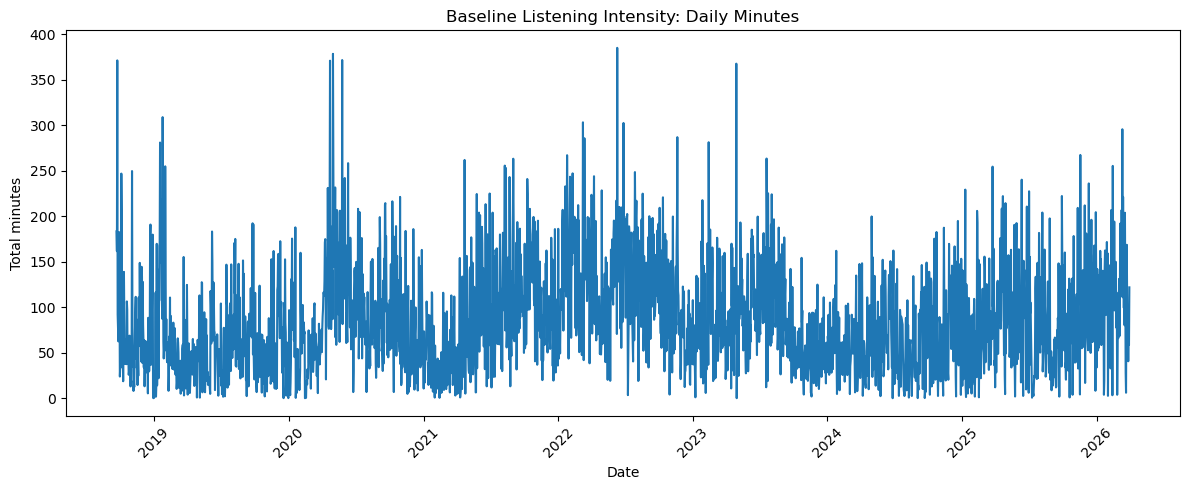

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(analysis_df["date"], analysis_df["total_minutes"])
plt.title("Baseline Listening Intensity: Daily Minutes")
plt.xlabel("Date")
plt.ylabel("Total minutes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [8]:
peak_day = analysis_df.loc[analysis_df["total_minutes"].idxmax()]
median_minutes = analysis_df["total_minutes"].median()
mean_minutes = analysis_df["total_minutes"].mean()
display(Markdown(
    f"**Insight:** My baseline listening is uneven rather than flat. The average day has **{mean_minutes:.1f} minutes**, while the median is **{median_minutes:.1f} minutes**, showing whether a few high-volume days pull the average upward. The peak day, **{peak_day['date'].date()}**, reached **{peak_day['total_minutes']:.1f} minutes**, suggesting that some days represent exceptional listening contexts rather than normal routine."
))


**Insight:** My baseline listening is uneven rather than flat. The average day has **87.0 minutes**, while the median is **77.8 minutes**, showing whether a few high-volume days pull the average upward. The peak day, **2022-06-10**, reached **384.9 minutes**, suggesting that some days represent exceptional listening contexts rather than normal routine.

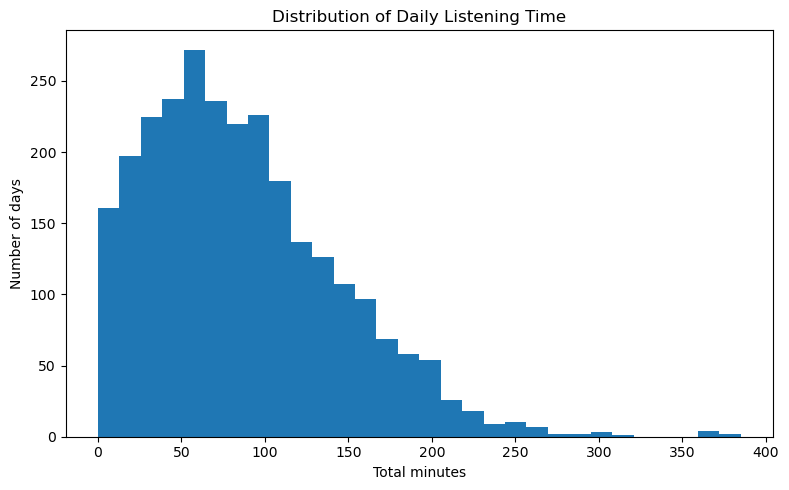

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(analysis_df["total_minutes"].dropna(), bins=30)
plt.title("Distribution of Daily Listening Time")
plt.xlabel("Total minutes")
plt.ylabel("Number of days")
plt.tight_layout()
plt.show()


In [10]:
skew_direction = "right-skewed" if analysis_df["total_minutes"].mean() > analysis_df["total_minutes"].median() else "not strongly right-skewed"
display(Markdown(
    f"**Insight:** The listening-time distribution is **{skew_direction}**. This means averages alone may overstate typical behavior. For special-day analysis, medians and boxplots are necessary because stress-related effects may appear as changes in variability rather than simple mean shifts."
))


**Insight:** The listening-time distribution is **right-skewed**. This means averages alone may overstate typical behavior. For special-day analysis, medians and boxplots are necessary because stress-related effects may appear as changes in variability rather than simple mean shifts.

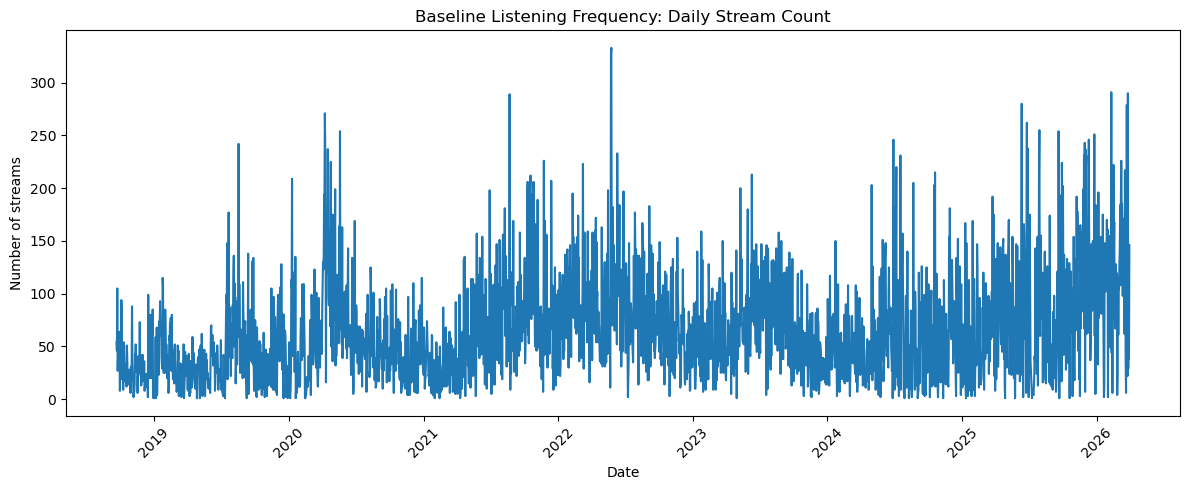

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(analysis_df["date"], analysis_df["num_streams"])
plt.title("Baseline Listening Frequency: Daily Stream Count")
plt.xlabel("Date")
plt.ylabel("Number of streams")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [12]:
stream_peak = analysis_df.loc[analysis_df["num_streams"].idxmax()]
display(Markdown(
    f"**Insight:** Stream frequency captures interaction with Spotify, not just time spent. The highest-frequency day was **{stream_peak['date'].date()}** with **{int(stream_peak['num_streams'])} streams**. If frequency spikes without similar listening-time growth, that suggests more fragmented or skip-heavy behavior."
))


**Insight:** Stream frequency captures interaction with Spotify, not just time spent. The highest-frequency day was **2022-05-25** with **333 streams**. If frequency spikes without similar listening-time growth, that suggests more fragmented or skip-heavy behavior.

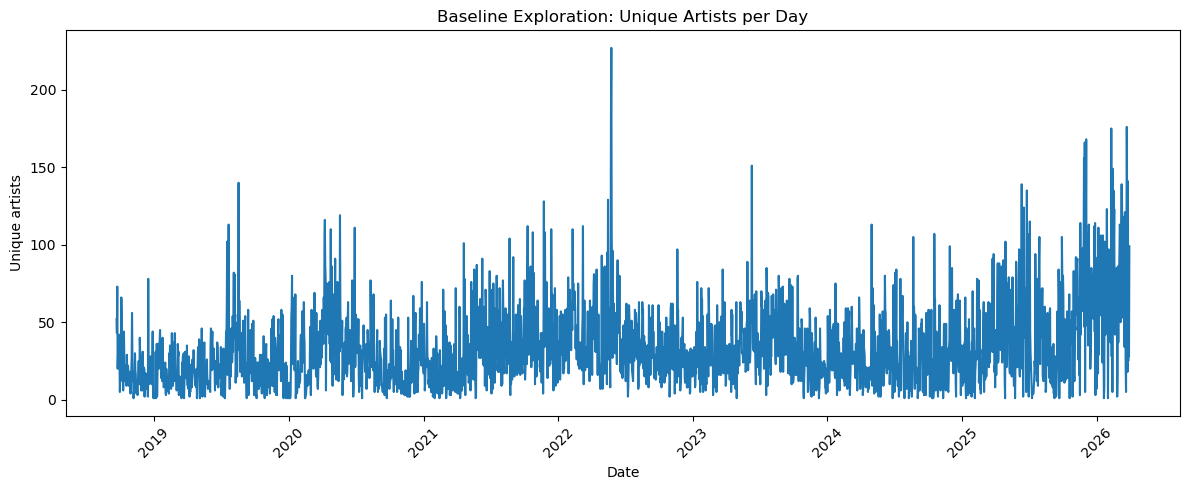

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(analysis_df["date"], analysis_df["unique_artists"])
plt.title("Baseline Exploration: Unique Artists per Day")
plt.xlabel("Date")
plt.ylabel("Unique artists")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [14]:
diversity_median = analysis_df["unique_artists"].median()
diversity_peak = analysis_df.loc[analysis_df["unique_artists"].idxmax()]
display(Markdown(
    f"**Insight:** Artist diversity shows exploration versus repetition. The median day has **{diversity_median:.0f} unique artists**, while the most diverse day reached **{diversity_peak['unique_artists']:.0f} artists**. This dimension is behaviorally important because stress might push me toward familiar comfort music or toward broader exploration for mood regulation."
))


**Insight:** Artist diversity shows exploration versus repetition. The median day has **28 unique artists**, while the most diverse day reached **227 artists**. This dimension is behaviorally important because stress might push me toward familiar comfort music or toward broader exploration for mood regulation.

# Section 3 — Listening intensity vs frequency

Listening for a long time is not the same as listening frequently. This section separates deep, sustained listening from fragmented, high-interaction listening.


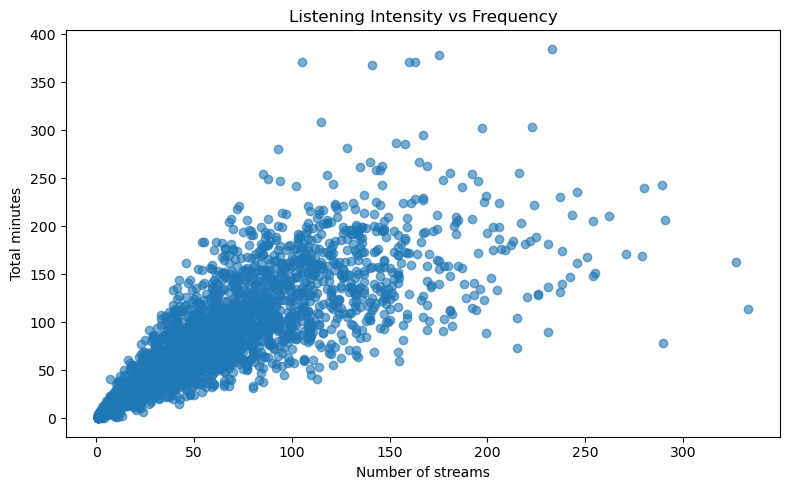

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(analysis_df["num_streams"], analysis_df["total_minutes"], alpha=0.6)
plt.title("Listening Intensity vs Frequency")
plt.xlabel("Number of streams")
plt.ylabel("Total minutes")
plt.tight_layout()
plt.show()


In [16]:
correlation = analysis_df[["num_streams", "total_minutes"]].corr().iloc[0, 1]
display(Markdown(
    f"**Insight:** The correlation between stream count and listening time is **{correlation:.2f}**. A high value suggests that frequent listening generally means longer listening, while gaps from the trend may reveal fragmented days with many short plays or focused days with fewer longer plays."
))


**Insight:** The correlation between stream count and listening time is **0.77**. A high value suggests that frequent listening generally means longer listening, while gaps from the trend may reveal fragmented days with many short plays or focused days with fewer longer plays.

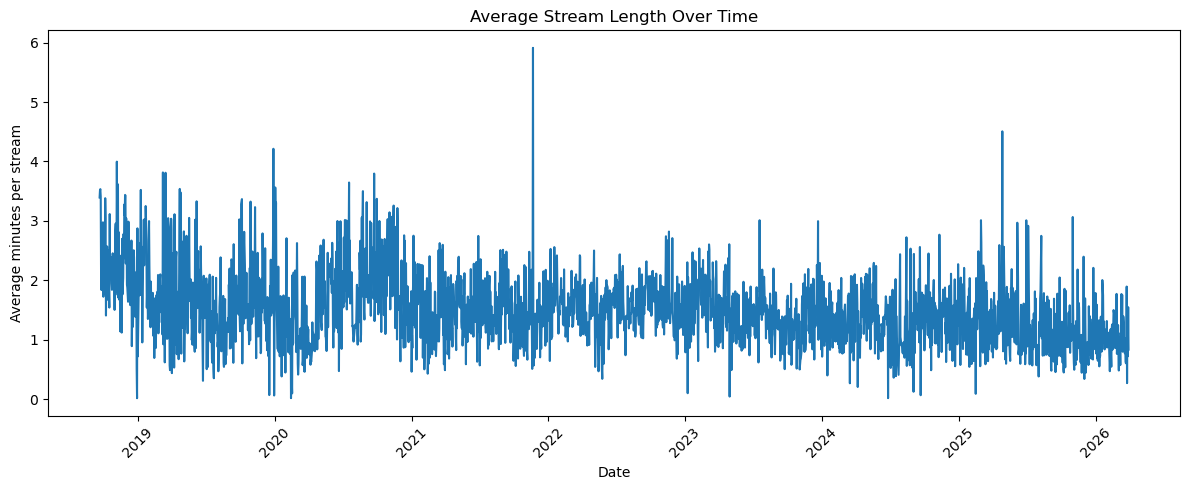

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(analysis_df["date"], analysis_df["avg_stream_length"])
plt.title("Average Stream Length Over Time")
plt.xlabel("Date")
plt.ylabel("Average minutes per stream")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [18]:
avg_length_median = analysis_df["avg_stream_length"].median()
display(Markdown(
    f"**Insight:** Average stream length is a proxy for listening continuity. A median of **{avg_length_median:.2f} minutes per stream** indicates how complete or fragmented my typical listening is. Shorter average stream lengths during special contexts may suggest distraction, dissatisfaction, or rapid switching."
))


**Insight:** Average stream length is a proxy for listening continuity. A median of **1.43 minutes per stream** indicates how complete or fragmented my typical listening is. Shorter average stream lengths during special contexts may suggest distraction, dissatisfaction, or rapid switching.

# Section 4 — Engagement analysis

Engagement is measured through skipping, shuffling, and track-ending behavior. These variables are behavioral signals: skipping can indicate dissatisfaction or distraction, while shuffle can indicate openness to randomness instead of controlled selection.


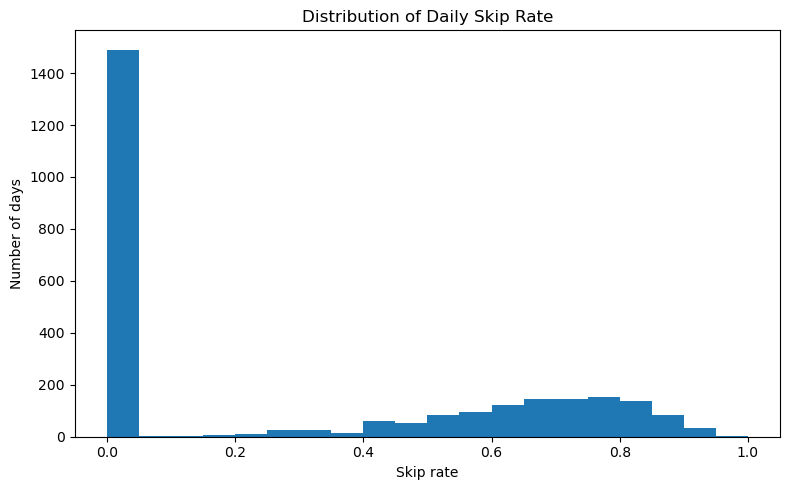

In [19]:
if analysis_df["skip_rate"].notna().any():
    plt.figure(figsize=(8, 5))
    plt.hist(analysis_df["skip_rate"].dropna(), bins=20)
    plt.title("Distribution of Daily Skip Rate")
    plt.xlabel("Skip rate")
    plt.ylabel("Number of days")
    plt.tight_layout()
    plt.show()
else:
    print("Skip-rate data is unavailable.")


In [20]:
if analysis_df["skip_rate"].notna().any():
    display(Markdown(
        f"**Insight:** The average daily skip rate is **{analysis_df['skip_rate'].mean():.2f}**. Higher skip-rate days may reflect lower attention, less music satisfaction, or more active searching for the right mood."
    ))
else:
    display(Markdown("**Insight:** Skip behavior is unavailable, so engagement must be inferred from stream frequency and average stream length."))


**Insight:** The average daily skip rate is **0.29**. Higher skip-rate days may reflect lower attention, less music satisfaction, or more active searching for the right mood.

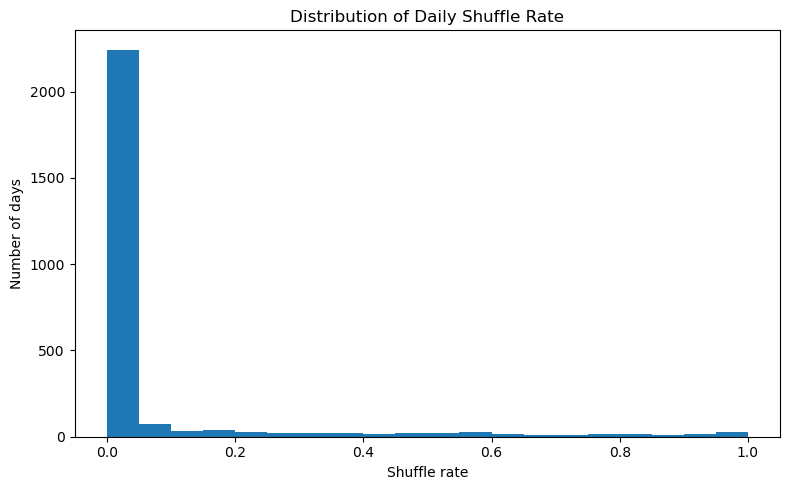

In [21]:
if analysis_df["shuffle_rate"].notna().any():
    plt.figure(figsize=(8, 5))
    plt.hist(analysis_df["shuffle_rate"].dropna(), bins=20)
    plt.title("Distribution of Daily Shuffle Rate")
    plt.xlabel("Shuffle rate")
    plt.ylabel("Number of days")
    plt.tight_layout()
    plt.show()
else:
    print("Shuffle-rate data is unavailable.")


In [22]:
if analysis_df["shuffle_rate"].notna().any():
    display(Markdown(
        f"**Insight:** The average shuffle rate is **{analysis_df['shuffle_rate'].mean():.2f}**. Higher shuffle use can indicate passive or exploratory listening, while lower shuffle use may indicate controlled, intentional song choice."
    ))


**Insight:** The average shuffle rate is **0.07**. Higher shuffle use can indicate passive or exploratory listening, while lower shuffle use may indicate controlled, intentional song choice.

,count
reason_end,
fwdbtn,69023
trackdone,51634
endplay,40433
logout,4652
unexpected-exit-while-paused,4522
backbtn,4004
remote,726
unknown,350
unexpected-exit,248


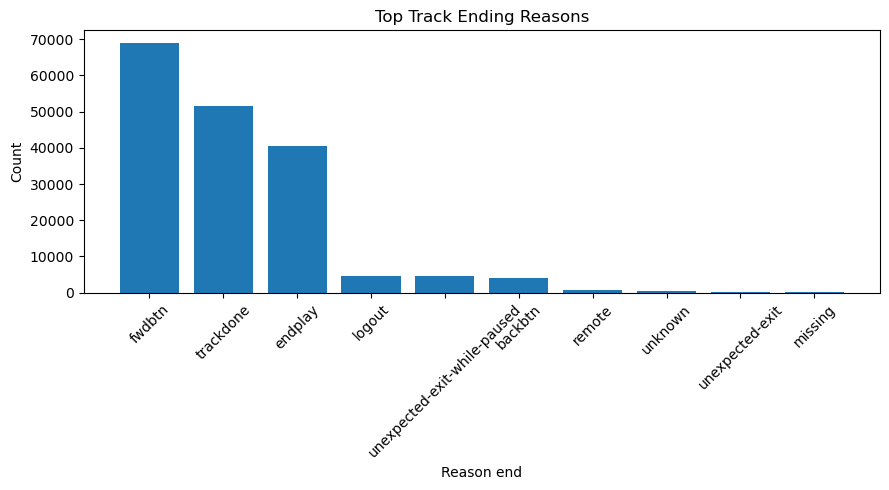

In [23]:
if reason_end_col is not None:
    reason_end_counts = spotify[reason_end_col].fillna("missing").value_counts().head(10)
    display(reason_end_counts.to_frame("count"))
    plt.figure(figsize=(9, 5))
    plt.bar(reason_end_counts.index.astype(str), reason_end_counts.values)
    plt.title("Top Track Ending Reasons")
    plt.xlabel("Reason end")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("reason_end column is unavailable.")


In [24]:
if reason_end_col is not None:
    dominant_reason = reason_end_counts.index[0]
    display(Markdown(
        f"**Insight:** The most common ending reason is **{dominant_reason}**. Ending reasons help distinguish passive completion from active interruption. This is useful for stress analysis because stressed listening may involve more active control, skipping, or interruption."
    ))


**Insight:** The most common ending reason is **fwdbtn**. Ending reasons help distinguish passive completion from active interruption. This is useful for stress analysis because stressed listening may involve more active control, skipping, or interruption.

# Section 5 — Artist and track behavior

This section studies repetition versus exploration. Top artists and tracks show the stable core of my listening identity, while diversity over time shows how flexible that identity is across contexts.


,streams
master_metadata_album_artist_name,
Ati242,4326
Motive,3850
Lvbel C5,3737
cakal,3388
Rammstein,2908
UZI,2903
Organize,2022
BLOK3,1938
Reckol,1884


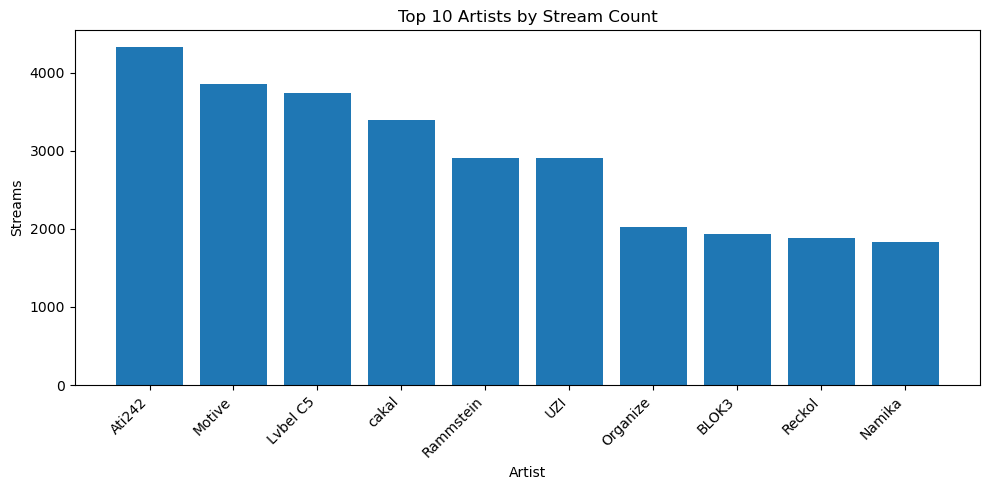

In [25]:
if artist_col is not None:
    top_artists = spotify[artist_col].dropna().value_counts().head(10)
    display(top_artists.to_frame("streams"))
    plt.figure(figsize=(10, 5))
    plt.bar(top_artists.index.astype(str), top_artists.values)
    plt.title("Top 10 Artists by Stream Count")
    plt.xlabel("Artist")
    plt.ylabel("Streams")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Artist column unavailable.")


In [26]:
if artist_col is not None:
    top_artist_share = top_artists.iloc[0] / len(spotify) * 100
    display(Markdown(
        f"**Insight:** The top artist accounts for **{top_artist_share:.1f}%** of all streams. A concentrated top-artist profile suggests comfort repetition, while a flatter profile would suggest exploratory behavior."
    ))


**Insight:** The top artist accounts for **2.5%** of all streams. A concentrated top-artist profile suggests comfort repetition, while a flatter profile would suggest exploratory behavior.

,streams
master_metadata_track_name,
Deutschland,398
Tiki Taka Flow,342
Italy Forma,329
Dalga,329
Paranoya,313
Shoote Shoote,302
Inzaghi,291
Trankobuskas - Remix,278
Gülşen,269


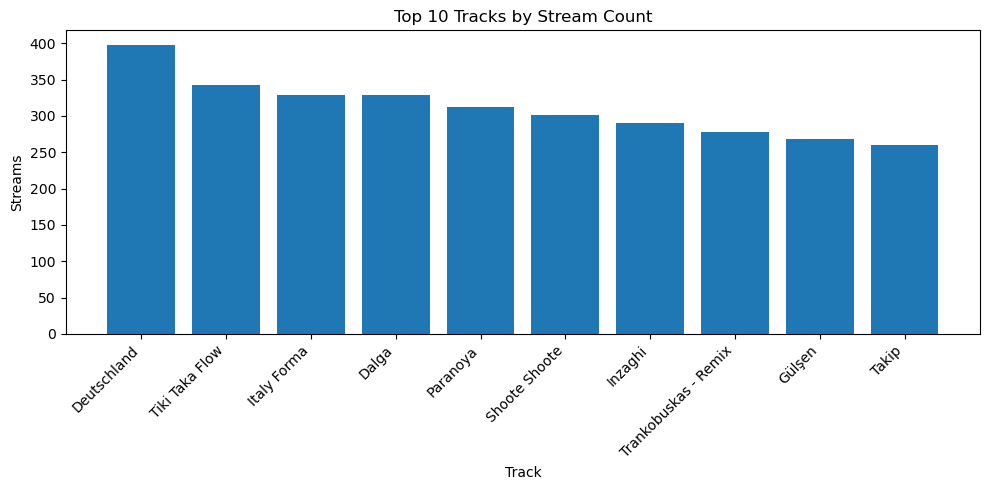

In [27]:
if track_col is not None:
    top_tracks = spotify[track_col].dropna().value_counts().head(10)
    display(top_tracks.to_frame("streams"))
    plt.figure(figsize=(10, 5))
    plt.bar(top_tracks.index.astype(str), top_tracks.values)
    plt.title("Top 10 Tracks by Stream Count")
    plt.xlabel("Track")
    plt.ylabel("Streams")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Track column unavailable.")


In [28]:
if track_col is not None:
    display(Markdown(
        "**Insight:** Top tracks represent repeated emotional or situational anchors. If these tracks become more dominant during stress periods, that would suggest music is being used as a stabilizing routine rather than just background entertainment."
    ))


**Insight:** Top tracks represent repeated emotional or situational anchors. If these tracks become more dominant during stress periods, that would suggest music is being used as a stabilizing routine rather than just background entertainment.

# Section 6 — Time-based behavior

Time patterns reveal routine. Hourly, weekday, and monthly listening patterns show when music fits into daily life and academic rhythms.


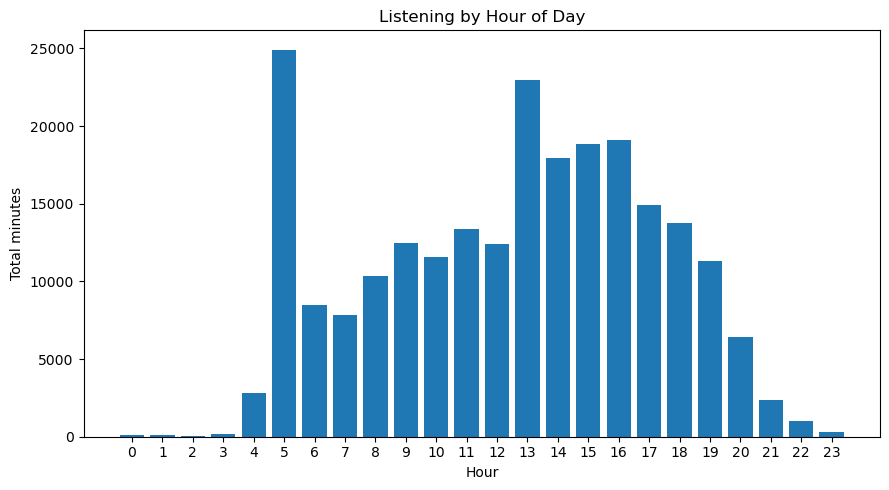

In [29]:
hourly = spotify.groupby("hour")["minutes_played"].sum().reset_index()
plt.figure(figsize=(9, 5))
plt.bar(hourly["hour"].astype(str), hourly["minutes_played"])
plt.title("Listening by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Total minutes")
plt.tight_layout()
plt.show()


In [30]:
peak_hour = hourly.loc[hourly["minutes_played"].idxmax(), "hour"]
display(Markdown(
    f"**Insight:** The peak listening hour is **{int(peak_hour)}:00**. This indicates the part of the day when music is most embedded in routine, such as commuting, studying, relaxing, or late-night decompression."
))


**Insight:** The peak listening hour is **5:00**. This indicates the part of the day when music is most embedded in routine, such as commuting, studying, relaxing, or late-night decompression.

,weekday_num,weekday,total_minutes,num_streams,unique_artists
0,0,Monday,92.46,69.66,35.74
1,1,Tuesday,92.04,71.16,36.16
2,2,Wednesday,93.34,71.96,37.02
3,3,Thursday,90.85,67.93,34.35
4,4,Friday,94.66,69.12,34.93
5,5,Saturday,73.45,52.60,27.57
6,6,Sunday,71.06,55.09,28.43


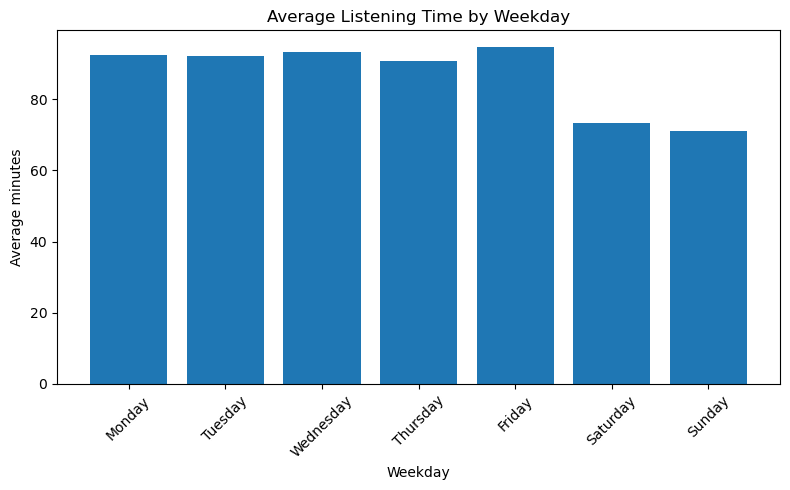

In [31]:
weekday_summary = (
    analysis_df.groupby(["weekday_num", "weekday"])[["total_minutes", "num_streams", "unique_artists"]]
    .mean()
    .reset_index()
    .sort_values("weekday_num")
)
display(weekday_summary.round(2))

plt.figure(figsize=(8, 5))
plt.bar(weekday_summary["weekday"], weekday_summary["total_minutes"])
plt.title("Average Listening Time by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average minutes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [32]:
weekday_high = weekday_summary.loc[weekday_summary["total_minutes"].idxmax()]
weekday_low = weekday_summary.loc[weekday_summary["total_minutes"].idxmin()]
display(Markdown(
    f"**Insight:** Listening is highest on **{weekday_high['weekday']}** and lowest on **{weekday_low['weekday']}**. This baseline matters because special days may appear abnormal partly because they interrupt or intensify existing weekday routines."
))


**Insight:** Listening is highest on **Friday** and lowest on **Sunday**. This baseline matters because special days may appear abnormal partly because they interrupt or intensify existing weekday routines.

,month,total_minutes,num_streams,unique_artists
0,1,83.63,60.30,31.47
1,2,78.60,60.43,34.05
2,3,79.65,64.04,35.98
3,4,89.35,68.36,33.92
4,5,92.67,69.69,36.92
5,6,104.58,76.29,39.06
6,7,95.32,70.42,34.05
7,8,96.68,76.32,36.73
8,9,92.67,65.38,30.44
9,10,84.63,62.07,29.48


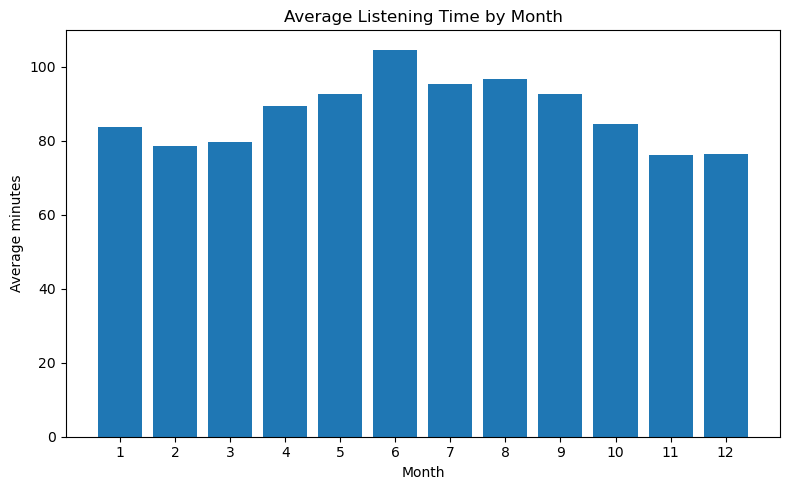

In [33]:
monthly_summary = analysis_df.groupby("month")[["total_minutes", "num_streams", "unique_artists"]].mean().reset_index()
display(monthly_summary.round(2))

plt.figure(figsize=(8, 5))
plt.bar(monthly_summary["month"].astype(str), monthly_summary["total_minutes"])
plt.title("Average Listening Time by Month")
plt.xlabel("Month")
plt.ylabel("Average minutes")
plt.tight_layout()
plt.show()


In [34]:
month_high = monthly_summary.loc[monthly_summary["total_minutes"].idxmax()]
display(Markdown(
    f"**Insight:** Month **{int(month_high['month'])}** has the highest average listening time. Monthly variation may reflect semester rhythm, holidays, exams, or lifestyle changes rather than isolated daily effects."
))


**Insight:** Month **6** has the highest average listening time. Monthly variation may reflect semester rhythm, holidays, exams, or lifestyle changes rather than isolated daily effects.

# Section 7 — Special day impact

This is the core context analysis. For exams, deadlines, and stress periods, I compare intensity, frequency, and diversity using tables, boxplots, and histograms.


In [35]:
core_metrics = ["total_minutes", "num_streams", "unique_artists"]


def comparison_table(df, label):
    summary = df.groupby(label)[core_metrics].agg(["count", "mean", "median", "std"]).round(2)
    return summary


def effect_size_table(df, label):
    rows = []
    for metric in core_metrics:
        normal = df.loc[df[label] == 0, metric].dropna()
        special_group = df.loc[df[label] == 1, metric].dropna()
        if normal.empty or special_group.empty:
            continue
        normal_mean = normal.mean()
        special_mean = special_group.mean()
        rows.append({
            "metric": metric,
            "normal_mean": normal_mean,
            "label_mean": special_mean,
            "mean_difference": special_mean - normal_mean,
            "percent_change": ((special_mean - normal_mean) / normal_mean * 100) if normal_mean != 0 else pd.NA,
            "normal_median": normal.median(),
            "label_median": special_group.median(),
            "normal_std": normal.std(),
            "label_std": special_group.std(),
        })
    return pd.DataFrame(rows).round(2)


def boxplot_metric(df, label, metric):
    normal = df.loc[df[label] == 0, metric].dropna()
    special_group = df.loc[df[label] == 1, metric].dropna()
    if normal.empty or special_group.empty:
        print(f"Skipping {metric} boxplot for {label}; one group has no data.")
        return
    plt.figure(figsize=(7, 5))
    plt.boxplot([normal, special_group], labels=[f"{label}=0", f"{label}=1"])
    plt.title(f"{metric} by {label}")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()


def histogram_metric(df, label, metric):
    normal = df.loc[df[label] == 0, metric].dropna()
    special_group = df.loc[df[label] == 1, metric].dropna()
    if normal.empty or special_group.empty:
        print(f"Skipping {metric} histogram for {label}; one group has no data.")
        return
    plt.figure(figsize=(8, 5))
    plt.hist(normal, bins=25, alpha=0.6, label=f"{label}=0")
    plt.hist(special_group, bins=25, alpha=0.6, label=f"{label}=1")
    plt.title(f"{metric} distribution by {label}")
    plt.xlabel(metric)
    plt.ylabel("Days")
    plt.legend()
    plt.tight_layout()
    plt.show()


def contextual_insight(df, label, context_name):
    effects = effect_size_table(df, label)
    if effects.empty:
        display(Markdown(f"**Insight:** {context_name} cannot be interpreted because one group has no observations."))
        return
    indexed = effects.set_index("metric")
    minutes_change = indexed.loc["total_minutes", "percent_change"]
    streams_change = indexed.loc["num_streams", "percent_change"]
    diversity_change = indexed.loc["unique_artists", "percent_change"]
    variability = "more variable" if indexed.loc["total_minutes", "label_std"] > indexed.loc["total_minutes", "normal_std"] else "less variable"
    direction = "increases" if minutes_change > 0 else "decreases"
    display(Markdown(
        f"**Insight for {context_name}:** Listening time **{direction}** by about **{minutes_change:.1f}%**, stream frequency changes by **{streams_change:.1f}%**, and artist diversity changes by **{diversity_change:.1f}%**. The labeled-day listening distribution is **{variability}**, which is important because stress may show up as instability rather than a simple average shift."
    ))


## 7A — Exam impact

Exam days are acute pressure points. I test whether listening becomes reduced, intensified, or more variable on these days.


total_minutes                      num_streams                      unique_artists                     
                count   mean median    std       count   mean median    std          count   mean median    std
is_exam                                                                                                        
0                2669  86.98  77.91  57.39        2669  65.27   55.0  48.18           2669  33.33   28.0  25.11
1                  17  83.81  68.90  53.52          17  95.35  106.0  55.97             17  60.18   60.0  34.87

,metric,normal_mean,label_mean,mean_difference,percent_change,normal_median,label_median,normal_std,label_std
0,total_minutes,86.98,83.81,-3.17,-3.64,77.91,68.9,57.39,53.52
1,num_streams,65.27,95.35,30.08,46.09,55.00,106.0,48.18,55.97
2,unique_artists,33.33,60.18,26.84,80.53,28.00,60.0,25.11,34.87


/var/folders/6s/_z262h2n0730l977pljhpqvm0000gn/T/ipykernel_66857/1324407902.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([normal, special_group], labels=[f"{label}=0", f"{label}=1"])


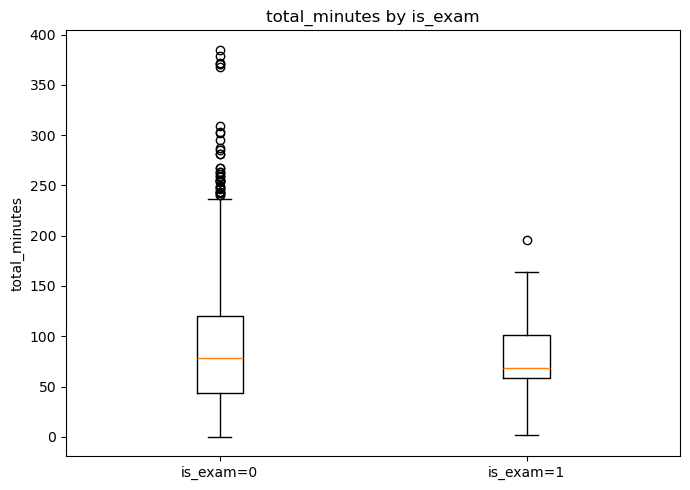

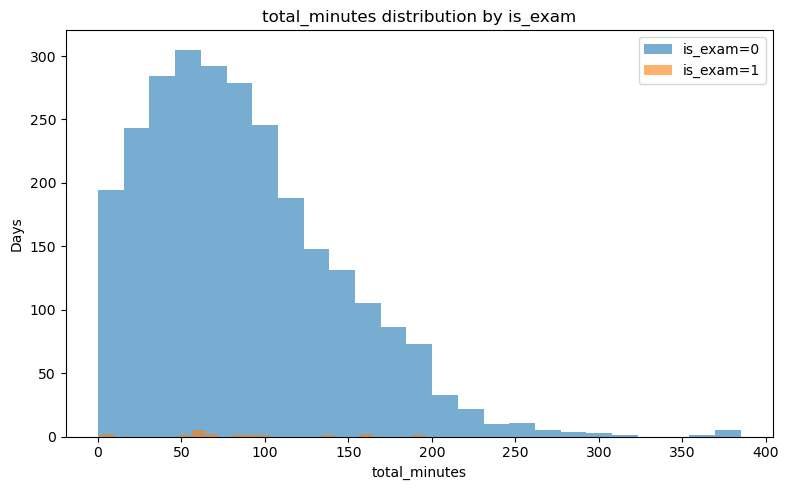

/var/folders/6s/_z262h2n0730l977pljhpqvm0000gn/T/ipykernel_66857/1324407902.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([normal, special_group], labels=[f"{label}=0", f"{label}=1"])


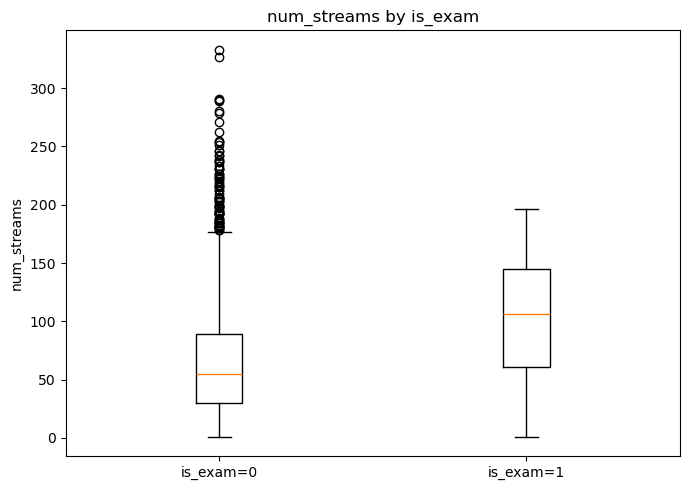

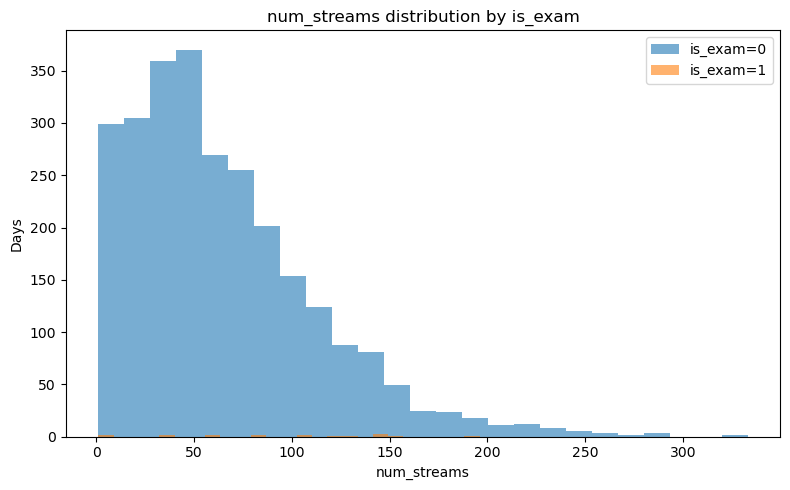

/var/folders/6s/_z262h2n0730l977pljhpqvm0000gn/T/ipykernel_66857/1324407902.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([normal, special_group], labels=[f"{label}=0", f"{label}=1"])


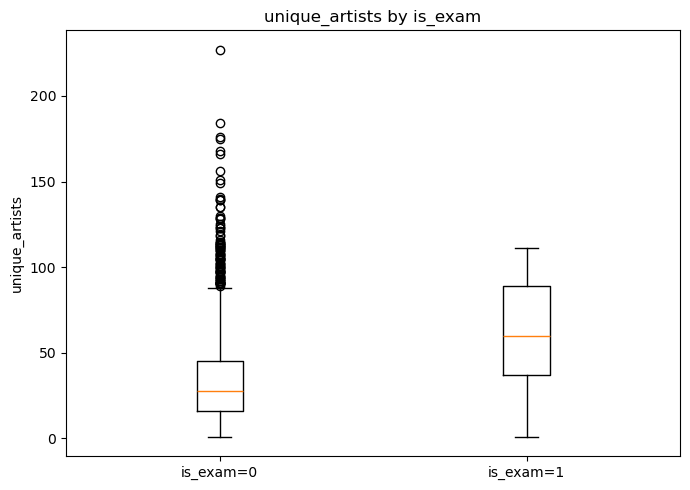

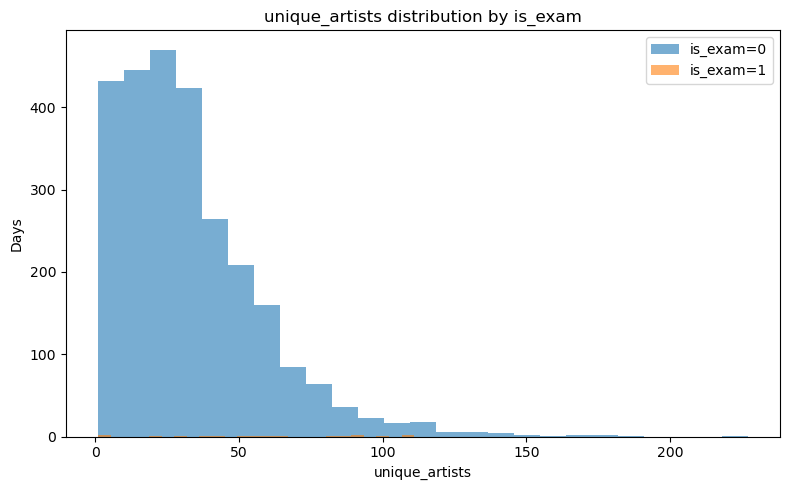

**Insight for exam days:** Listening time **decreases** by about **-3.6%**, stream frequency changes by **46.1%**, and artist diversity changes by **80.5%**. The labeled-day listening distribution is **less variable**, which is important because stress may show up as instability rather than a simple average shift.

In [36]:
display(comparison_table(analysis_df, "is_exam"))
display(effect_size_table(analysis_df, "is_exam"))
for metric in core_metrics:
    boxplot_metric(analysis_df, "is_exam", metric)
    histogram_metric(analysis_df, "is_exam", metric)
contextual_insight(analysis_df, "is_exam", "exam days")


## 7B — Deadline impact

Deadline days may reflect focus pressure. Music could become background support for work or disappear because the day is too disrupted.


total_minutes                        num_streams                       unique_artists                    
                    count    mean  median    std       count    mean median    std          count   mean median   std
is_deadline                                                                                                          
0                    2644   86.57   77.14  57.38        2644   64.68   54.0  47.64           2644  32.98   28.0  24.7
1                      42  111.39  113.59  51.18          42  114.83  101.5  61.99             42  66.21   65.5  36.5

,metric,normal_mean,label_mean,mean_difference,percent_change,normal_median,label_median,normal_std,label_std
0,total_minutes,86.57,111.39,24.82,28.67,77.14,113.59,57.38,51.18
1,num_streams,64.68,114.83,50.16,77.55,54.00,101.50,47.64,61.99
2,unique_artists,32.98,66.21,33.23,100.75,28.00,65.50,24.70,36.50


/var/folders/6s/_z262h2n0730l977pljhpqvm0000gn/T/ipykernel_66857/1324407902.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([normal, special_group], labels=[f"{label}=0", f"{label}=1"])


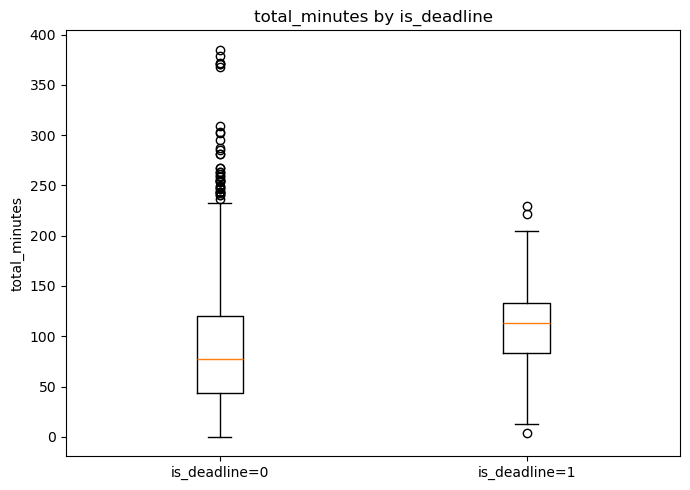

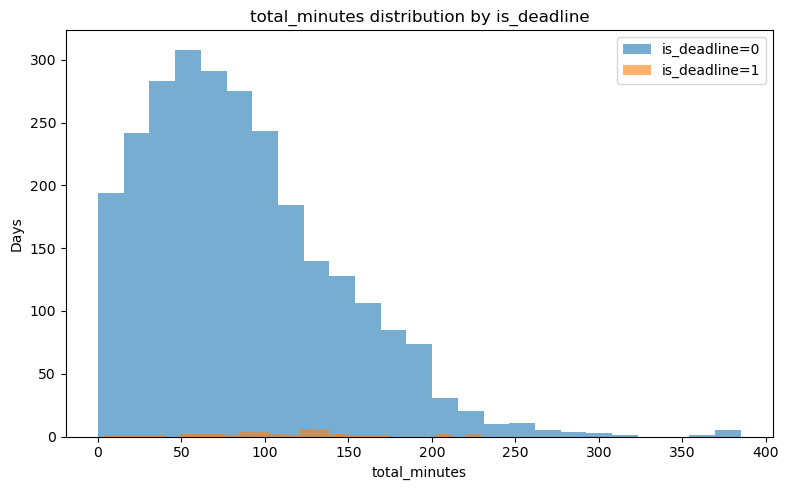

/var/folders/6s/_z262h2n0730l977pljhpqvm0000gn/T/ipykernel_66857/1324407902.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([normal, special_group], labels=[f"{label}=0", f"{label}=1"])


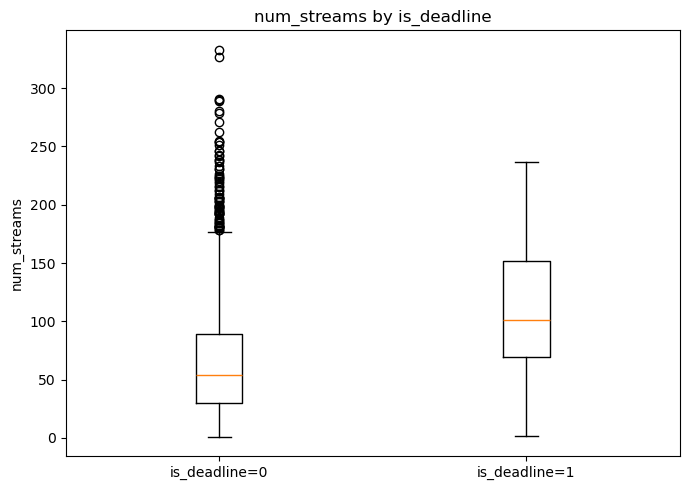

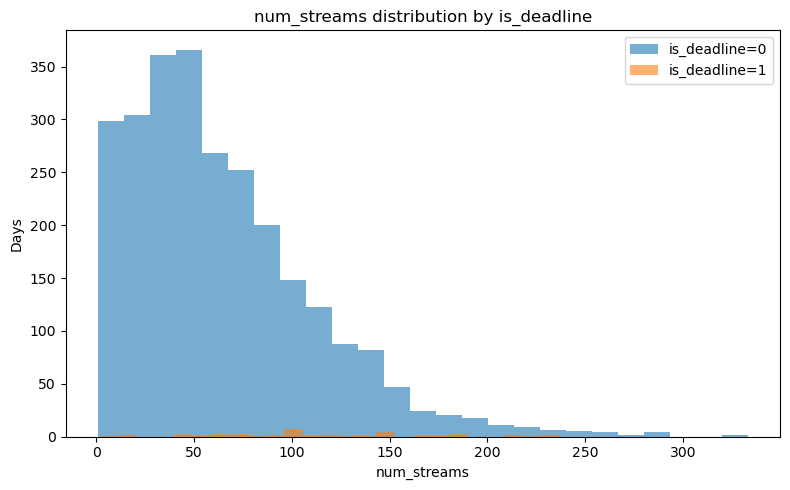

/var/folders/6s/_z262h2n0730l977pljhpqvm0000gn/T/ipykernel_66857/1324407902.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([normal, special_group], labels=[f"{label}=0", f"{label}=1"])


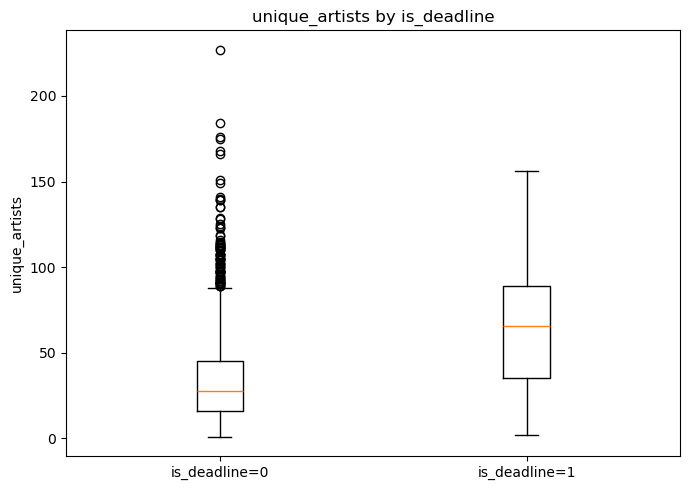

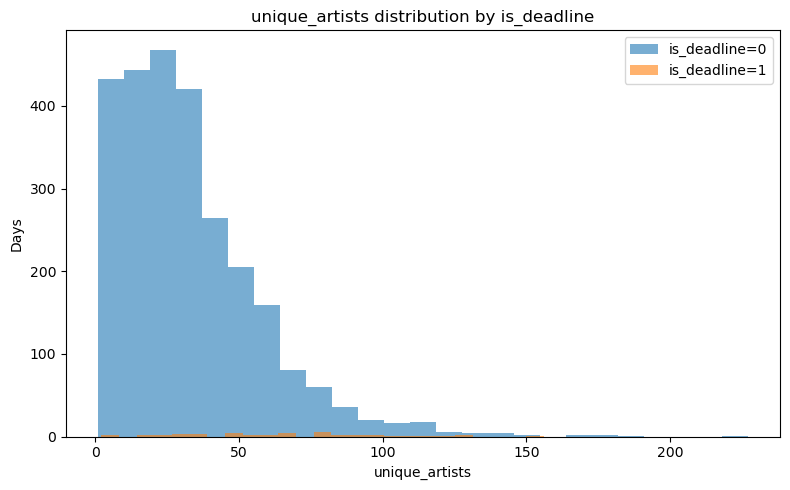

**Insight for deadline days:** Listening time **increases** by about **28.7%**, stream frequency changes by **77.5%**, and artist diversity changes by **100.8%**. The labeled-day listening distribution is **less variable**, which is important because stress may show up as instability rather than a simple average shift.

In [37]:
display(comparison_table(analysis_df, "is_deadline"))
display(effect_size_table(analysis_df, "is_deadline"))
for metric in core_metrics:
    boxplot_metric(analysis_df, "is_deadline", metric)
    histogram_metric(analysis_df, "is_deadline", metric)
contextual_insight(analysis_df, "is_deadline", "deadline days")


## 7C — Stress-period impact

Stress periods are anticipatory windows before major events. They may be more behaviorally revealing than the event day itself.


total_minutes                       num_streams                      unique_artists                     
                         count    mean median    std       count   mean median    std          count   mean median    std
is_stress_period                                                                                                         
0                         2536   86.15  76.90  57.14        2536  63.43   54.0  46.14           2536  32.09   28.0  23.30
1                          150  100.67  98.14  59.60         150  99.76   92.0  67.28            150  57.40   52.0  40.66

,metric,normal_mean,label_mean,mean_difference,percent_change,normal_median,label_median,normal_std,label_std
0,total_minutes,86.15,100.67,14.52,16.85,76.9,98.14,57.14,59.60
1,num_streams,63.43,99.76,36.33,57.27,54.0,92.00,46.14,67.28
2,unique_artists,32.09,57.40,25.31,78.87,28.0,52.00,23.30,40.66


/var/folders/6s/_z262h2n0730l977pljhpqvm0000gn/T/ipykernel_66857/1324407902.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([normal, special_group], labels=[f"{label}=0", f"{label}=1"])


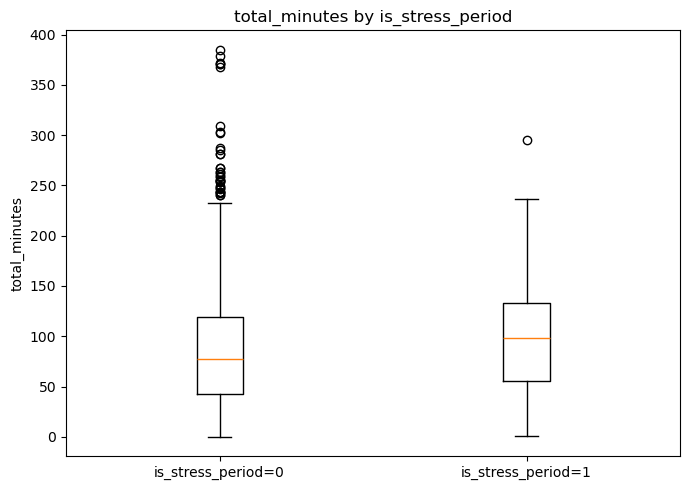

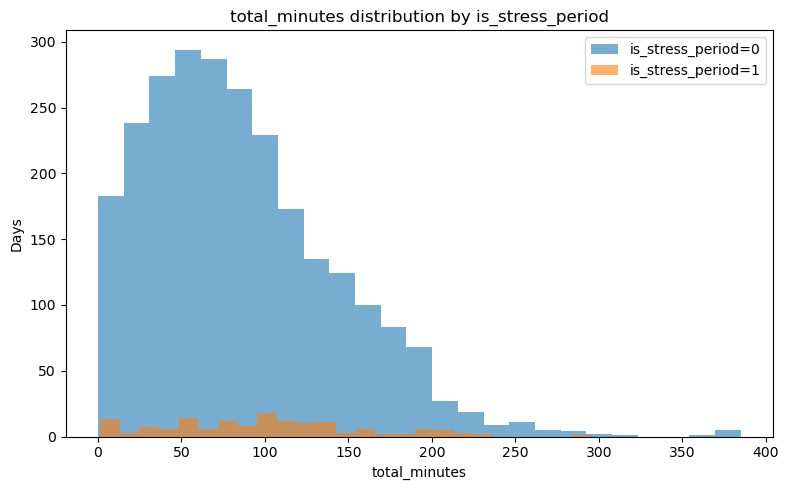

/var/folders/6s/_z262h2n0730l977pljhpqvm0000gn/T/ipykernel_66857/1324407902.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([normal, special_group], labels=[f"{label}=0", f"{label}=1"])


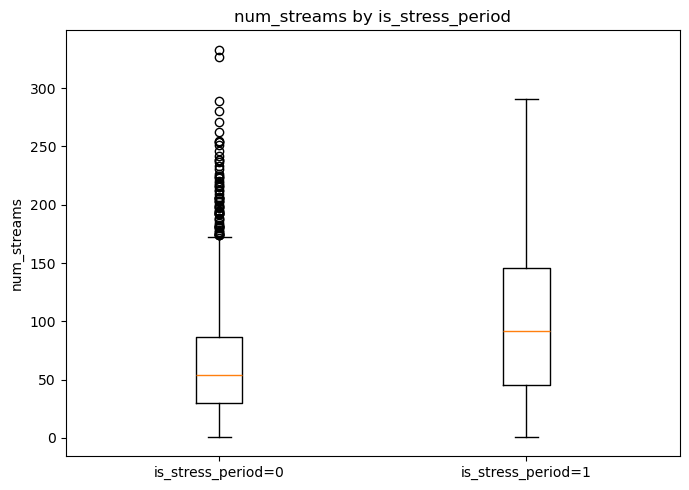

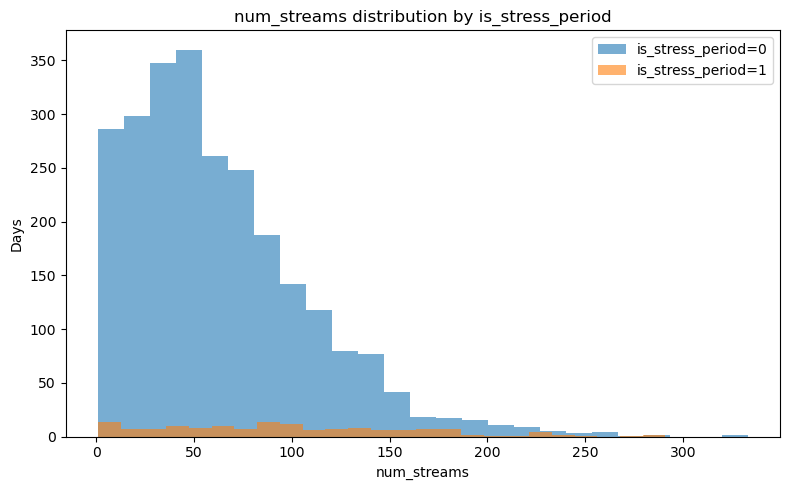

/var/folders/6s/_z262h2n0730l977pljhpqvm0000gn/T/ipykernel_66857/1324407902.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([normal, special_group], labels=[f"{label}=0", f"{label}=1"])


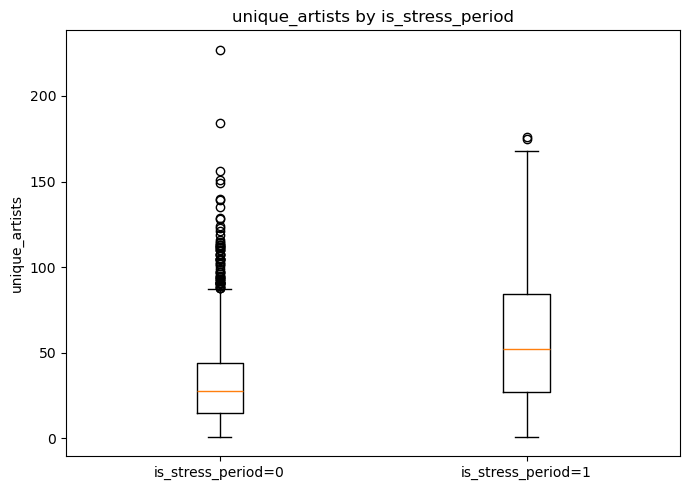

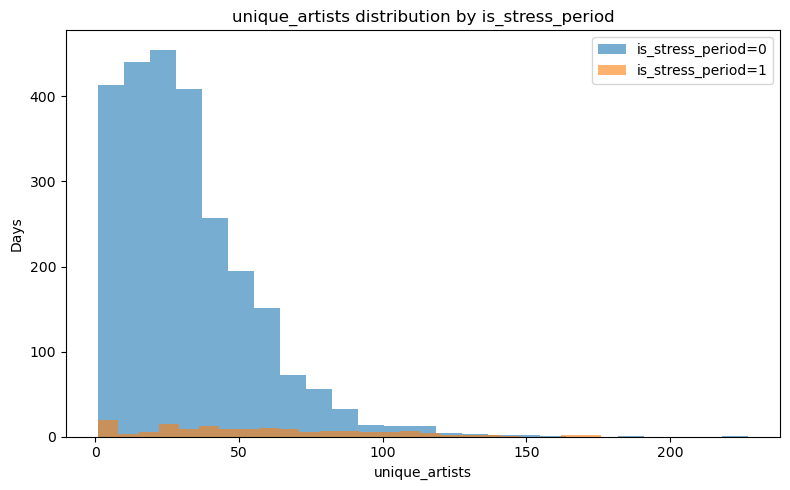

**Insight for stress periods:** Listening time **increases** by about **16.9%**, stream frequency changes by **57.3%**, and artist diversity changes by **78.9%**. The labeled-day listening distribution is **more variable**, which is important because stress may show up as instability rather than a simple average shift.

In [38]:
display(comparison_table(analysis_df, "is_stress_period"))
display(effect_size_table(analysis_df, "is_stress_period"))
for metric in core_metrics:
    boxplot_metric(analysis_df, "is_stress_period", metric)
    histogram_metric(analysis_df, "is_stress_period", metric)
contextual_insight(analysis_df, "is_stress_period", "stress periods")


# Section 8 — Behavior shift analysis

This section focuses on changes rather than levels. A day may not be extreme in absolute listening time but may still represent a sharp behavioral shift from the previous day.


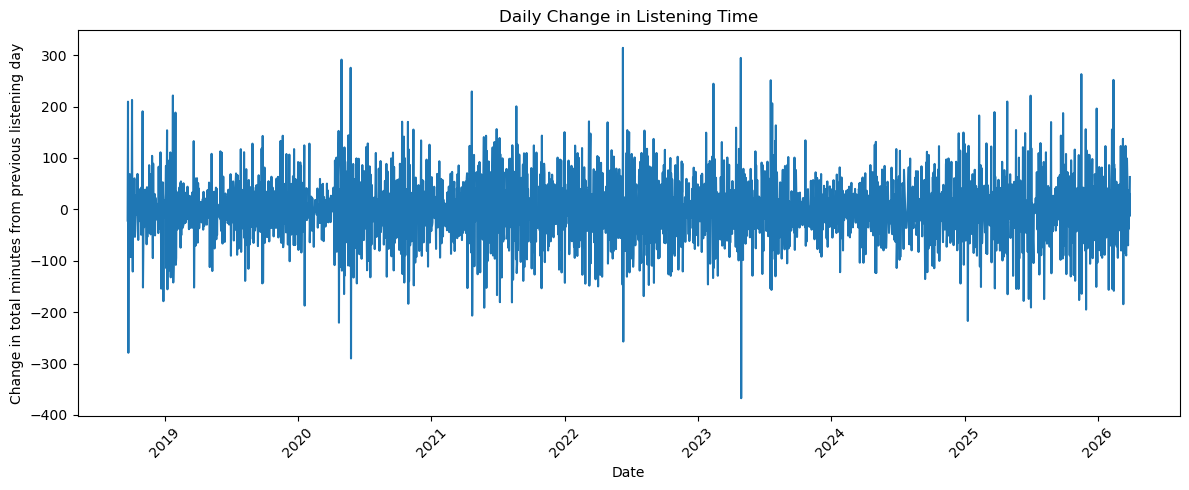

In [39]:
plt.figure(figsize=(12, 5))
plt.plot(analysis_df["date"], analysis_df["delta_total_minutes"])
plt.title("Daily Change in Listening Time")
plt.xlabel("Date")
plt.ylabel("Change in total minutes from previous listening day")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [40]:
largest_increase = analysis_df.loc[analysis_df["delta_total_minutes"].idxmax()]
largest_drop = analysis_df.loc[analysis_df["delta_total_minutes"].idxmin()]
display(Markdown(
    f"**Insight:** The largest increase happened on **{largest_increase['date'].date()}**, while the sharpest drop happened on **{largest_drop['date'].date()}**. Sudden changes may reflect routine disruption, mood changes, travel, deadlines, or recovery after high-pressure periods."
))


**Insight:** The largest increase happened on **2022-06-10**, while the sharpest drop happened on **2023-04-30**. Sudden changes may reflect routine disruption, mood changes, travel, deadlines, or recovery after high-pressure periods.

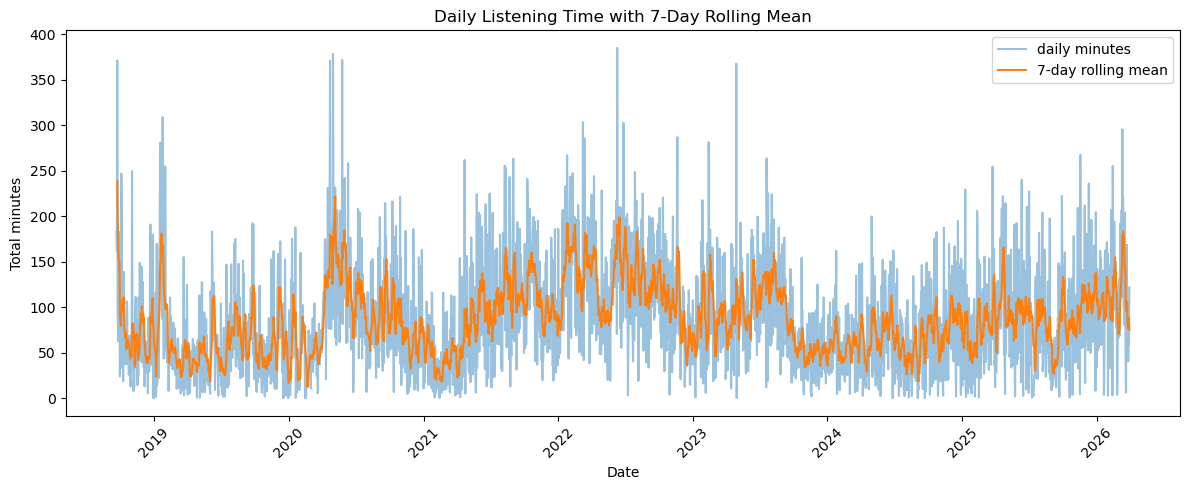

In [41]:
plt.figure(figsize=(12, 5))
plt.plot(analysis_df["date"], analysis_df["total_minutes"], alpha=0.45, label="daily minutes")
plt.plot(analysis_df["date"], analysis_df["rolling_7"], label="7-day rolling mean")
plt.title("Daily Listening Time with 7-Day Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Total minutes")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [42]:
display(Markdown(
    "**Insight:** The rolling mean smooths out isolated spikes and reveals broader behavioral phases. If stress periods align with rolling increases or decreases, that suggests a sustained context effect rather than a one-day anomaly."
))


**Insight:** The rolling mean smooths out isolated spikes and reveals broader behavioral phases. If stress periods align with rolling increases or decreases, that suggests a sustained context effect rather than a one-day anomaly.

# Section 9 — Event-centered exam analysis

Instead of only comparing exam days to normal days, this analysis aligns listening around exam events from 3 days before to 3 days after. This can reveal anticipation and recovery patterns.


In [43]:
exam_dates = sorted(analysis_df.loc[analysis_df["is_exam"] == 1, "date"].dropna().unique())
window = 3
event_rows = []

for exam_date in exam_dates:
    exam_date = pd.Timestamp(exam_date)
    for relative_day in range(-window, window + 1):
        target_date = exam_date + pd.Timedelta(days=relative_day)
        row = analysis_df[analysis_df["date"] == target_date]
        if row.empty:
            event_rows.append({
                "exam_date": exam_date,
                "relative_day": relative_day,
                "total_minutes": 0,
                "num_streams": 0,
                "unique_artists": 0,
            })
        else:
            event_rows.append({
                "exam_date": exam_date,
                "relative_day": relative_day,
                "total_minutes": row["total_minutes"].iloc[0],
                "num_streams": row["num_streams"].iloc[0],
                "unique_artists": row["unique_artists"].iloc[0],
            })

exam_window_df = pd.DataFrame(event_rows)
print("Exam events used:", len(exam_dates))
display(exam_window_df.head())


Exam events used: 17


,exam_date,relative_day,total_minutes,num_streams,unique_artists
0,2025-04-29,-3,25.247333,11,11
1,2025-04-29,-2,4.507367,1,1
2,2025-04-29,-1,214.300383,137,102
3,2025-04-29,0,49.156550,61,37
4,2025-04-29,1,97.498517,80,49


In [44]:
if not exam_window_df.empty:
    exam_curve = exam_window_df.groupby("relative_day")[core_metrics].mean().reset_index()
    display(exam_curve.round(2))
else:
    exam_curve = pd.DataFrame()
    print("No exam-centered data available.")


,relative_day,total_minutes,num_streams,unique_artists
0,-3,101.22,114.94,66.00
1,-2,84.22,88.35,53.24
2,-1,94.02,93.41,59.76
3,0,83.81,95.35,60.18
4,1,90.91,90.65,56.47
5,2,95.75,88.29,56.76
6,3,94.69,92.88,52.47


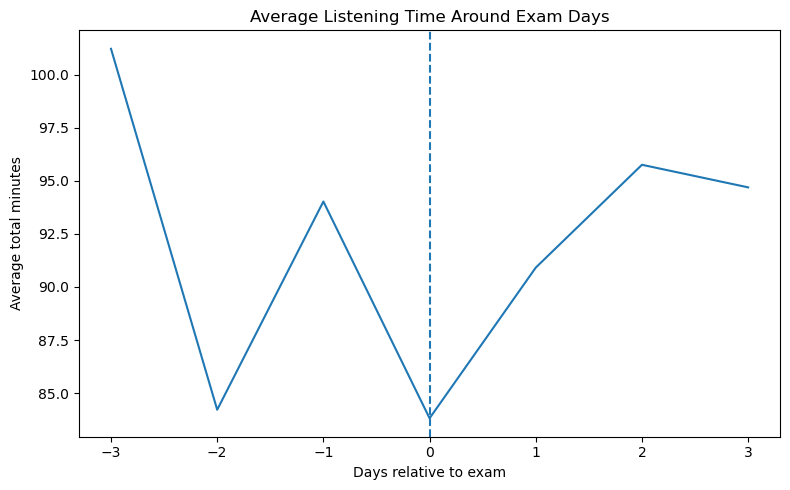

In [45]:
if not exam_curve.empty:
    plt.figure(figsize=(8, 5))
    plt.plot(exam_curve["relative_day"], exam_curve["total_minutes"])
    plt.axvline(0, linestyle="--")
    plt.title("Average Listening Time Around Exam Days")
    plt.xlabel("Days relative to exam")
    plt.ylabel("Average total minutes")
    plt.tight_layout()
    plt.show()


In [46]:
if not exam_curve.empty:
    before = exam_window_df[exam_window_df["relative_day"].between(-3, -1)]["total_minutes"].mean()
    exam_day = exam_window_df[exam_window_df["relative_day"] == 0]["total_minutes"].mean()
    after = exam_window_df[exam_window_df["relative_day"].between(1, 3)]["total_minutes"].mean()
    display(Markdown(
        f"**Insight:** Average listening is **{before:.1f} minutes** before exams, **{exam_day:.1f} minutes** on exam days, and **{after:.1f} minutes** after exams. Higher pre-exam listening could indicate coping or study background music, while higher post-exam listening could indicate recovery and decompression."
    ))


**Insight:** Average listening is **93.2 minutes** before exams, **83.8 minutes** on exam days, and **93.8 minutes** after exams. Higher pre-exam listening could indicate coping or study background music, while higher post-exam listening could indicate recovery and decompression.

# Section 10 — Extreme behavior

Extreme days are not just outliers to remove. In behavioral data, extremes can be meaningful episodes of stress, recovery, travel, social activity, or unusual routine.


In [47]:
extreme_cols = [
    "date", "total_minutes", "num_streams", "unique_artists",
    "is_exam", "is_deadline", "is_stress_period", "source_events", "categories"
]
highest_days = analysis_df.sort_values("total_minutes", ascending=False).head(10)[extreme_cols]
lowest_days = analysis_df.sort_values("total_minutes", ascending=True).head(10)[extreme_cols]

print("Highest listening days")
display(highest_days)

print("Lowest listening days")
display(lowest_days)


Highest listening days


,date,total_minutes,num_streams,unique_artists,is_exam,is_deadline,is_stress_period,source_events,categories
1341,2022-06-10,384.913783,233,66,0,0,0,,
575,2020-04-30,378.329467,175,68,0,0,0,,
600,2020-05-25,371.533283,163,51,0,0,0,,
2,2018-09-23,371.135817,105,73,0,0,0,,
567,2020-04-22,370.790433,160,67,0,0,0,,
1660,2023-04-29,367.533417,141,63,0,0,0,,
123,2019-01-24,308.803683,115,40,0,0,0,,
1248,2022-03-09,303.098950,223,112,0,0,0,,
1358,2022-06-27,302.376650,197,48,0,0,0,,
2666,2026-03-11,295.479517,167,100,0,0,1,LA Form,stress_before_deadline


Lowest listening days


,date,total_minutes,num_streams,unique_artists,is_exam,is_deadline,is_stress_period,source_events,categories
100,2018-12-30,0.016667,1,1,0,0,0,,
500,2020-02-14,0.017667,1,1,0,0,0,,
2079,2024-06-26,0.017783,1,1,0,0,0,,
1661,2023-04-30,0.044000,1,1,0,0,0,,
443,2019-12-18,0.069383,1,1,0,0,0,,
455,2019-12-31,0.124500,2,2,0,0,0,,
2132,2024-09-02,0.125017,1,1,0,0,0,,
2150,2024-09-21,0.200883,3,3,0,0,0,,
475,2020-01-20,0.382850,1,1,0,0,0,,
502,2020-02-17,0.391367,4,4,0,0,0,,


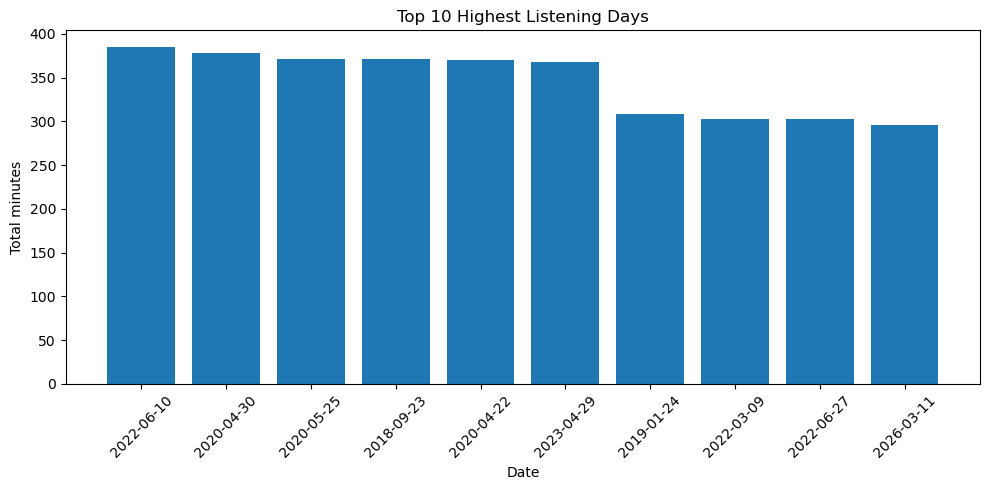

In [48]:
plt.figure(figsize=(10, 5))
plt.bar(highest_days["date"].dt.strftime("%Y-%m-%d"), highest_days["total_minutes"])
plt.title("Top 10 Highest Listening Days")
plt.xlabel("Date")
plt.ylabel("Total minutes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


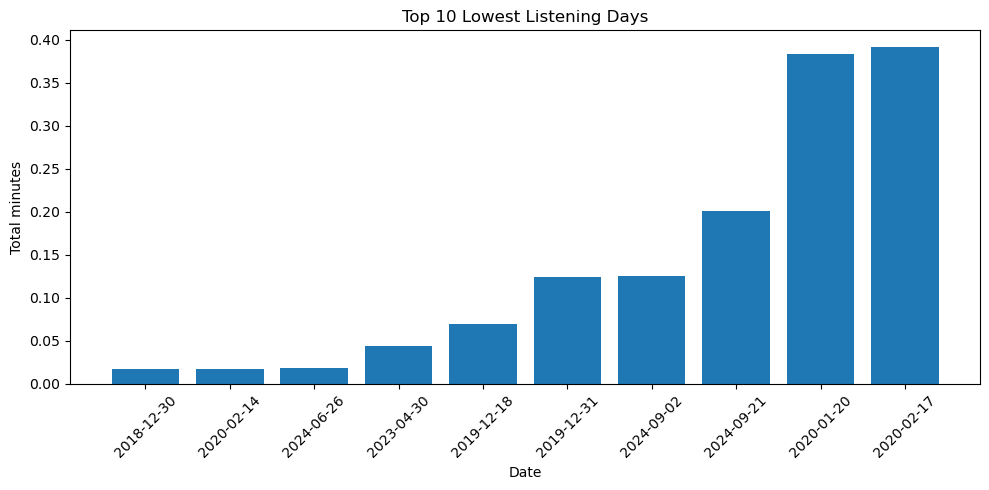

In [49]:
plt.figure(figsize=(10, 5))
plt.bar(lowest_days["date"].dt.strftime("%Y-%m-%d"), lowest_days["total_minutes"])
plt.title("Top 10 Lowest Listening Days")
plt.xlabel("Date")
plt.ylabel("Total minutes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [50]:
highest_overlap = highest_days[["is_exam", "is_deadline", "is_stress_period"]].sum().sum()
lowest_overlap = lowest_days[["is_exam", "is_deadline", "is_stress_period"]].sum().sum()
display(Markdown(
    f"**Insight:** The highest-listening days contain **{int(highest_overlap)}** special-context labels, while the lowest-listening days contain **{int(lowest_overlap)}**. This helps distinguish ordinary outliers from context-linked behavioral episodes."
))


**Insight:** The highest-listening days contain **1** special-context labels, while the lowest-listening days contain **0**. This helps distinguish ordinary outliers from context-linked behavioral episodes.

# Section 11 — Combined conditions

Special contexts can overlap. Exam days inside stress periods may behave differently from stress days without exams. This section checks compound effects.


In [51]:
combined = analysis_df.copy()
combined["exam_and_stress"] = ((combined["is_exam"] == 1) & (combined["is_stress_period"] == 1)).astype(int)
combined["stress_no_exam"] = ((combined["is_exam"] == 0) & (combined["is_stress_period"] == 1)).astype(int)
combined["deadline_and_stress"] = ((combined["is_deadline"] == 1) & (combined["is_stress_period"] == 1)).astype(int)

compound_summary = pd.DataFrame({
    "condition": ["exam_and_stress", "stress_no_exam", "deadline_and_stress"],
    "days": [
        combined["exam_and_stress"].sum(),
        combined["stress_no_exam"].sum(),
        combined["deadline_and_stress"].sum(),
    ],
    "mean_total_minutes": [
        combined.loc[combined["exam_and_stress"] == 1, "total_minutes"].mean(),
        combined.loc[combined["stress_no_exam"] == 1, "total_minutes"].mean(),
        combined.loc[combined["deadline_and_stress"] == 1, "total_minutes"].mean(),
    ],
    "mean_num_streams": [
        combined.loc[combined["exam_and_stress"] == 1, "num_streams"].mean(),
        combined.loc[combined["stress_no_exam"] == 1, "num_streams"].mean(),
        combined.loc[combined["deadline_and_stress"] == 1, "num_streams"].mean(),
    ],
    "mean_unique_artists": [
        combined.loc[combined["exam_and_stress"] == 1, "unique_artists"].mean(),
        combined.loc[combined["stress_no_exam"] == 1, "unique_artists"].mean(),
        combined.loc[combined["deadline_and_stress"] == 1, "unique_artists"].mean(),
    ],
})
display(compound_summary.round(2))


,condition,days,mean_total_minutes,mean_num_streams,mean_unique_artists
0,exam_and_stress,14,82.14,94.93,59.79
1,stress_no_exam,136,102.58,100.26,57.15
2,deadline_and_stress,28,114.43,117.82,70.89


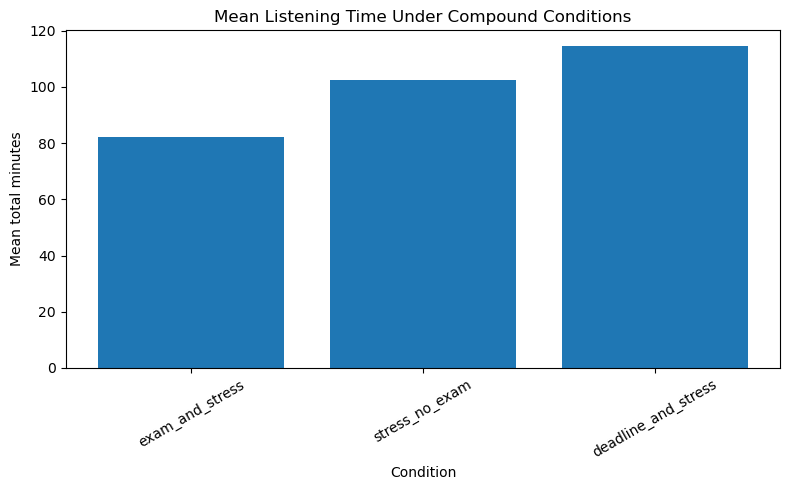

In [52]:
plot_compound = compound_summary.dropna(subset=["mean_total_minutes"])
plt.figure(figsize=(8, 5))
plt.bar(plot_compound["condition"], plot_compound["mean_total_minutes"])
plt.title("Mean Listening Time Under Compound Conditions")
plt.xlabel("Condition")
plt.ylabel("Mean total minutes")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [53]:
display(Markdown(
    "**Insight:** Compound contexts help separate acute events from background stress. If stress-without-exam differs from exam-related stress, then the behavioral mechanism may not be the event itself but the anticipation and workload surrounding it."
))


**Insight:** Compound contexts help separate acute events from background stress. If stress-without-exam differs from exam-related stress, then the behavioral mechanism may not be the event itself but the anticipation and workload surrounding it.

# Section 12 — Key findings

This section summarizes the strongest patterns from the notebook in behavioral terms.


In [54]:
finding_lines = []
for label in ["is_exam", "is_deadline", "is_stress_period"]:
    effects = effect_size_table(analysis_df, label)
    for _, row in effects.iterrows():
        finding_lines.append(
            f"- **{label}** changes **{row['metric']}** by approximately **{row['percent_change']:.1f}%**."
        )

display(Markdown(
    "## Behavioral findings\n"
    + "\n".join(finding_lines[:9])
    + "\n\nOverall, the most important question is not only whether listening increases or decreases, but which dimension changes: time investment, interaction frequency, engagement control, or diversity."
))


## Behavioral findings
- **is_exam** changes **total_minutes** by approximately **-3.6%**.
- **is_exam** changes **num_streams** by approximately **46.1%**.
- **is_exam** changes **unique_artists** by approximately **80.5%**.
- **is_deadline** changes **total_minutes** by approximately **28.7%**.
- **is_deadline** changes **num_streams** by approximately **77.5%**.
- **is_deadline** changes **unique_artists** by approximately **100.8%**.
- **is_stress_period** changes **total_minutes** by approximately **16.9%**.
- **is_stress_period** changes **num_streams** by approximately **57.3%**.
- **is_stress_period** changes **unique_artists** by approximately **78.9%**.

Overall, the most important question is not only whether listening increases or decreases, but which dimension changes: time investment, interaction frequency, engagement control, or diversity.

# Section 13 — Hypothesis generation

The EDA suggests the following hypotheses for formal testing:

- **H1:** Exam days reduce daily listening time compared with non-exam days.
- **H2:** Stress periods increase skipping, suggesting lower satisfaction or more fragmented attention.
- **H3:** Stress periods reduce artist diversity, suggesting comfort-based repetitive listening.
- **H4:** Deadlines change listening frequency, either because music supports focus or because work disrupts normal listening.
- **H5:** Listening changes before and after exams, indicating anticipation and recovery effects.

These hypotheses are grounded in the EDA because the notebook compares levels, distributions, variability, temporal patterns, and event-centered windows rather than relying on one summary statistic.


# Hypothesis Testing

This section extends the exploratory analysis with formal statistical tests. The goal is to evaluate whether the behavioral differences observed in the EDA are strong enough to count as statistical evidence against a null hypothesis.

All tests use **alpha = 0.05**. These tests support interpretation, but they do not prove causality.


## Statistical setup and safe data preparation

The notebook already creates a merged daily dataframe earlier. This setup cell reuses `analysis_df` if it exists. If the notebook is run from this section alone, it reconstructs the required daily dataset from `spotify_cleaned.csv` and `special_dates.csv`.


In [55]:
from pathlib import Path

import pandas as pd
from scipy.stats import ttest_ind, ttest_rel, chi2_contingency
from IPython.display import Markdown, display

ALPHA = 0.05
BASE_DIR = Path.home() / "Desktop" / "DSA210 TERM PROJECT"
SPOTIFY_PATH = BASE_DIR / "extended_streaming_history_data" / "spotify_cleaned.csv"
SPECIAL_DATES_PATH = BASE_DIR / "special_days_data" / "special_dates.csv"


def first_existing(df, candidates):
    for column in candidates:
        if column in df.columns:
            return column
    return None


def to_binary(series):
    if series.dtype == bool:
        return series.astype(int)
    normalized = series.astype(str).str.lower().str.strip()
    mapped = normalized.map({
        "true": 1, "false": 0, "1": 1, "0": 0,
        "yes": 1, "no": 0, "nan": 0, "none": 0,
    })
    return mapped.fillna(pd.to_numeric(series, errors="coerce")).fillna(0)


def reconstruct_analysis_df_if_needed():
    if "analysis_df" in globals() and isinstance(globals()["analysis_df"], pd.DataFrame):
        working = globals()["analysis_df"].copy()
        if "date" in working.columns:
            working["date"] = pd.to_datetime(working["date"], errors="coerce")
        return working

    spotify_raw = pd.read_csv(SPOTIFY_PATH)
    special_raw = pd.read_csv(SPECIAL_DATES_PATH)

    ts_col = first_existing(spotify_raw, ["ts", "timestamp", "played_at", "event_timestamp"])
    ms_col = first_existing(spotify_raw, ["ms_played", "msPlayed", "milliseconds_played"])
    artist_col = first_existing(spotify_raw, ["master_metadata_album_artist_name", "artist_name", "artist", "album_artist"])
    track_col = first_existing(spotify_raw, ["master_metadata_track_name", "track_name", "track"])
    skipped_col = first_existing(spotify_raw, ["skipped", "skip", "was_skipped"])
    shuffle_col = first_existing(spotify_raw, ["shuffle", "is_shuffle", "message_shuffle"])

    if ts_col is None or ms_col is None:
        raise ValueError("Cannot reconstruct analysis_df because timestamp or duration columns are missing.")

    spotify = spotify_raw.copy()
    spotify[ts_col] = pd.to_datetime(spotify[ts_col], errors="coerce", utc=True)
    spotify = spotify.dropna(subset=[ts_col]).copy()
    spotify["date"] = pd.to_datetime(spotify[ts_col].dt.date)
    spotify[ms_col] = pd.to_numeric(spotify[ms_col], errors="coerce").fillna(0)

    agg_dict = {ms_col: "sum"}
    if artist_col is not None:
        agg_dict[artist_col] = pd.Series.nunique
    if track_col is not None:
        agg_dict[track_col] = pd.Series.nunique

    daily = spotify.groupby("date").agg(agg_dict).reset_index()
    daily = daily.rename(columns={ms_col: "total_ms"})
    daily["total_minutes"] = daily["total_ms"] / 60000
    daily["num_streams"] = spotify.groupby("date").size().reindex(daily["date"]).values

    if artist_col is not None:
        daily = daily.rename(columns={artist_col: "unique_artists"})
    else:
        daily["unique_artists"] = pd.NA

    if track_col is not None:
        daily = daily.rename(columns={track_col: "unique_tracks"})
    else:
        daily["unique_tracks"] = pd.NA

    if skipped_col is not None:
        spotify["skipped_numeric"] = to_binary(spotify[skipped_col])
        daily = daily.merge(
            spotify.groupby("date")["skipped_numeric"].mean().reset_index(name="skip_rate"),
            on="date",
            how="left",
        )
    else:
        daily["skip_rate"] = pd.NA

    if shuffle_col is not None:
        spotify["shuffle_numeric"] = to_binary(spotify[shuffle_col])
        daily = daily.merge(
            spotify.groupby("date")["shuffle_numeric"].mean().reset_index(name="shuffle_rate"),
            on="date",
            how="left",
        )
    else:
        daily["shuffle_rate"] = pd.NA

    special = special_raw.copy()
    special["date"] = pd.to_datetime(special["date"], errors="coerce")
    special = special.dropna(subset=["date"]).copy()

    label_columns = ["is_exam", "is_deadline", "is_stress_period", "is_academic_event", "is_personal"]
    for column in label_columns:
        if column not in special.columns:
            special[column] = 0
        special[column] = pd.to_numeric(special[column], errors="coerce").fillna(0).astype(int)

    for column in ["source_events", "categories"]:
        if column not in special.columns:
            special[column] = ""
        special[column] = special[column].fillna("").astype(str)

    rebuilt = daily.merge(special, on="date", how="left")
    for column in label_columns:
        rebuilt[column] = pd.to_numeric(rebuilt[column], errors="coerce").fillna(0).astype(int)
    for column in ["source_events", "categories"]:
        if column in rebuilt.columns:
            rebuilt[column] = rebuilt[column].fillna("").astype(str)
    return rebuilt


analysis_test_df = reconstruct_analysis_df_if_needed().copy()
analysis_test_df["date"] = pd.to_datetime(analysis_test_df["date"], errors="coerce")

for label in ["is_exam", "is_deadline", "is_stress_period"]:
    if label not in analysis_test_df.columns:
        analysis_test_df[label] = 0
    analysis_test_df[label] = pd.to_numeric(analysis_test_df[label], errors="coerce").fillna(0).astype(int)

print("Hypothesis testing dataframe shape:", analysis_test_df.shape)
display(analysis_test_df.head())


Hypothesis testing dataframe shape: (2686, 23)


,date,total_ms,unique_artists,unique_tracks,total_minutes,num_streams,skip_rate,shuffle_rate,avg_stream_length,delta_total_minutes,rolling_7,is_exam,is_deadline,is_academic_event,is_personal,is_stress_period,source_events,categories,any_special_day,weekday,weekday_num,month,year
0,2018-09-21,10998656,52,53,183.310933,54,0.0,0.000,3.394647,NaN,NaN,0,0,0,0,0,,,0,Friday,4,9,2018
1,2018-09-22,9692768,43,44,161.546133,46,0.0,0.000,3.511872,-21.764800,NaN,0,0,0,0,0,,,0,Saturday,5,9,2018
2,2018-09-23,22268149,73,81,371.135817,105,0.0,0.000,3.534627,209.589683,238.664294,0,0,0,0,0,,,0,Sunday,6,9,2018
3,2018-09-24,5524854,20,22,92.080900,27,0.0,1.000,3.410404,-279.054917,202.018446,0,0,0,0,0,,,0,Monday,0,9,2018
4,2018-09-25,4691250,30,32,78.187500,40,0.0,0.725,1.954687,-13.893400,177.252257,0,0,0,0,0,,,0,Tuesday,1,9,2018


## Test helper functions

These helper functions standardize each test output: sample sizes, group means, test statistic, p-value, alpha, and decision.


In [56]:
def decision_from_pvalue(p_value, alpha=ALPHA):
    if pd.isna(p_value):
        return "Test not available"
    return "Reject H0" if p_value < alpha else "Fail to reject H0"


def run_two_sample_ttest(df, label_col, value_col, label_name, h0, ha):
    if label_col not in df.columns:
        display(Markdown(f"**Skipped:** `{label_col}` is missing, so this test cannot be run."))
        return None
    if value_col not in df.columns:
        display(Markdown(f"**Skipped:** `{value_col}` is missing, so this test cannot be run."))
        return None

    group_1 = pd.to_numeric(df.loc[df[label_col] == 1, value_col], errors="coerce").dropna()
    group_0 = pd.to_numeric(df.loc[df[label_col] == 0, value_col], errors="coerce").dropna()

    if len(group_1) < 2 or len(group_0) < 2:
        display(Markdown(
            f"**Skipped:** `{label_name}` does not have enough observations for a two-sample t-test "
            f"(label=1 n={len(group_1)}, label=0 n={len(group_0)})."
        ))
        return None

    t_stat, p_value = ttest_ind(group_1, group_0, equal_var=False, nan_policy="omit")
    decision = decision_from_pvalue(p_value)

    result = {
        "test": "Welch two-sample t-test",
        "label": label_col,
        "variable": value_col,
        "n_label_1": len(group_1),
        "n_label_0": len(group_0),
        "mean_label_1": group_1.mean(),
        "mean_label_0": group_0.mean(),
        "median_label_1": group_1.median(),
        "median_label_0": group_0.median(),
        "t_statistic": t_stat,
        "p_value": p_value,
        "alpha": ALPHA,
        "decision": decision,
    }

    print("Null hypothesis:", h0)
    print("Alternative hypothesis:", ha)
    print(f"Sample size ({label_col}=1):", len(group_1))
    print(f"Sample size ({label_col}=0):", len(group_0))
    print(f"Mean ({label_col}=1): {group_1.mean():.4f}")
    print(f"Mean ({label_col}=0): {group_0.mean():.4f}")
    print(f"t-statistic: {t_stat:.4f}")
    print(f"p-value: {p_value:.6f}")
    print(f"alpha: {ALPHA}")
    print("Decision:", decision)

    direction = "higher" if group_1.mean() > group_0.mean() else "lower"
    if decision == "Reject H0":
        interpretation = (
            f"The p-value is below {ALPHA}, so we reject the null hypothesis. "
            f"This suggests that **{value_col} differs significantly** for {label_name}. "
            f"The labeled group has a {direction} mean than the comparison group."
        )
    else:
        interpretation = (
            f"The p-value is not below {ALPHA}, so we fail to reject the null hypothesis. "
            f"This test does not provide enough statistical evidence that **{value_col} differs** for {label_name}, "
            f"even if the descriptive means are not identical."
        )
    display(Markdown(f"**Interpretation:** {interpretation}"))
    return result


def run_paired_exam_ttest(df):
    required = {"date", "is_exam", "total_minutes"}
    missing = required - set(df.columns)
    if missing:
        display(Markdown(f"**Skipped:** Missing required columns for paired exam test: {sorted(missing)}."))
        return None

    working = df.copy()
    working["date"] = pd.to_datetime(working["date"], errors="coerce")
    daily_lookup = working.set_index("date")["total_minutes"]
    exam_dates = sorted(working.loc[working["is_exam"] == 1, "date"].dropna().unique())

    pairs = []
    for exam_date in exam_dates:
        exam_date = pd.Timestamp(exam_date)
        before_date = exam_date - pd.Timedelta(days=1)
        after_date = exam_date + pd.Timedelta(days=1)
        if before_date in daily_lookup.index and after_date in daily_lookup.index:
            before_value = daily_lookup.loc[before_date]
            after_value = daily_lookup.loc[after_date]
            if pd.notna(before_value) and pd.notna(after_value):
                pairs.append({
                    "exam_date": exam_date,
                    "before_date": before_date,
                    "after_date": after_date,
                    "before_total_minutes": float(before_value),
                    "after_total_minutes": float(after_value),
                })

    pairs_df = pd.DataFrame(pairs)
    display(pairs_df)

    if len(pairs_df) < 2:
        display(Markdown(
            f"**Skipped:** Only {len(pairs_df)} valid before/after exam pairs were found. "
            "A paired t-test requires at least 2 valid pairs."
        ))
        return None

    t_stat, p_value = ttest_rel(
        pairs_df["before_total_minutes"],
        pairs_df["after_total_minutes"],
        nan_policy="omit",
    )
    decision = decision_from_pvalue(p_value)

    print("Null hypothesis: Mean listening time before exams is the same as mean listening time after exams.")
    print("Alternative hypothesis: Mean listening time before exams is different from mean listening time after exams.")
    print("Number of valid exam pairs:", len(pairs_df))
    print(f"Mean before exams: {pairs_df['before_total_minutes'].mean():.4f}")
    print(f"Mean after exams: {pairs_df['after_total_minutes'].mean():.4f}")
    print(f"t-statistic: {t_stat:.4f}")
    print(f"p-value: {p_value:.6f}")
    print(f"alpha: {ALPHA}")
    print("Decision:", decision)

    if decision == "Reject H0":
        interpretation = (
            f"The p-value is below {ALPHA}, so we reject the null hypothesis. "
            "This suggests a statistically detectable change in listening time from the day before exams to the day after exams."
        )
    else:
        interpretation = (
            f"The p-value is not below {ALPHA}, so we fail to reject the null hypothesis. "
            "The paired test does not provide enough evidence that listening time changes systematically before versus after exams."
        )
    display(Markdown(f"**Interpretation:** {interpretation}"))

    return {
        "test": "Paired t-test",
        "variable": "total_minutes",
        "n_pairs": len(pairs_df),
        "mean_before": pairs_df["before_total_minutes"].mean(),
        "mean_after": pairs_df["after_total_minutes"].mean(),
        "t_statistic": t_stat,
        "p_value": p_value,
        "alpha": ALPHA,
        "decision": decision,
    }


## H1 — Exam days vs non-exam days: daily listening time

**H0:** Mean daily listening time is the same for exam and non-exam days.  
**HA:** Mean daily listening time is different for exam and non-exam days.

Test: two-sample t-test.


In [57]:
h1_result = run_two_sample_ttest(
    analysis_test_df,
    label_col="is_exam",
    value_col="total_minutes",
    label_name="exam days vs non-exam days",
    h0="Mean daily listening time is the same for exam and non-exam days.",
    ha="Mean daily listening time is different for exam and non-exam days.",
)


Null hypothesis: Mean daily listening time is the same for exam and non-exam days.
Alternative hypothesis: Mean daily listening time is different for exam and non-exam days.
Sample size (is_exam=1): 17
Sample size (is_exam=0): 2669
Mean (is_exam=1): 83.8144
Mean (is_exam=0): 86.9806
t-statistic: -0.2431
p-value: 0.811007
alpha: 0.05
Decision: Fail to reject H0


**Interpretation:** The p-value is not below 0.05, so we fail to reject the null hypothesis. This test does not provide enough statistical evidence that **total_minutes differs** for exam days vs non-exam days, even if the descriptive means are not identical.

## H2 — Stress periods vs non-stress periods: skip behavior

**H0:** Mean skip rate is the same in stress and non-stress periods.  
**HA:** Mean skip rate is different in stress and non-stress periods.

Test: two-sample t-test.


In [58]:
if "skip_rate" not in analysis_test_df.columns or analysis_test_df["skip_rate"].isna().all():
    display(Markdown(
        "**Skipped:** `skip_rate` is not available in the merged daily dataset and could not be reconstructed. "
        "This hypothesis should be revisited if stream-level skipped information is available."
    ))
    h2_result = None
else:
    h2_result = run_two_sample_ttest(
        analysis_test_df,
        label_col="is_stress_period",
        value_col="skip_rate",
        label_name="stress periods vs non-stress periods",
        h0="Mean skip rate is the same in stress and non-stress periods.",
        ha="Mean skip rate is different in stress and non-stress periods.",
    )


Null hypothesis: Mean skip rate is the same in stress and non-stress periods.
Alternative hypothesis: Mean skip rate is different in stress and non-stress periods.
Sample size (is_stress_period=1): 150
Sample size (is_stress_period=0): 2536
Mean (is_stress_period=1): 0.6846
Mean (is_stress_period=0): 0.2705
t-statistic: 22.1378
p-value: 0.000000
alpha: 0.05
Decision: Reject H0


**Interpretation:** The p-value is below 0.05, so we reject the null hypothesis. This suggests that **skip_rate differs significantly** for stress periods vs non-stress periods. The labeled group has a higher mean than the comparison group.

## H3 — Stress periods vs non-stress periods: artist diversity

**H0:** Mean artist diversity is the same in stress and non-stress periods.  
**HA:** Mean artist diversity is different in stress and non-stress periods.

Test: two-sample t-test.


In [59]:
h3_result = run_two_sample_ttest(
    analysis_test_df,
    label_col="is_stress_period",
    value_col="unique_artists",
    label_name="stress periods vs non-stress periods",
    h0="Mean artist diversity is the same in stress and non-stress periods.",
    ha="Mean artist diversity is different in stress and non-stress periods.",
)


Null hypothesis: Mean artist diversity is the same in stress and non-stress periods.
Alternative hypothesis: Mean artist diversity is different in stress and non-stress periods.
Sample size (is_stress_period=1): 150
Sample size (is_stress_period=0): 2536
Mean (is_stress_period=1): 57.4000
Mean (is_stress_period=0): 32.0903
t-statistic: 7.5516
p-value: 0.000000
alpha: 0.05
Decision: Reject H0


**Interpretation:** The p-value is below 0.05, so we reject the null hypothesis. This suggests that **unique_artists differs significantly** for stress periods vs non-stress periods. The labeled group has a higher mean than the comparison group.

## H4 — Deadline days vs non-deadline days: listening frequency

**H0:** Mean number of streams is the same on deadline and non-deadline days.  
**HA:** Mean number of streams is different on deadline and non-deadline days.

Test: two-sample t-test.


In [60]:
h4_result = run_two_sample_ttest(
    analysis_test_df,
    label_col="is_deadline",
    value_col="num_streams",
    label_name="deadline days vs non-deadline days",
    h0="Mean number of streams is the same on deadline and non-deadline days.",
    ha="Mean number of streams is different on deadline and non-deadline days.",
)


Null hypothesis: Mean number of streams is the same on deadline and non-deadline days.
Alternative hypothesis: Mean number of streams is different on deadline and non-deadline days.
Sample size (is_deadline=1): 42
Sample size (is_deadline=0): 2644
Mean (is_deadline=1): 114.8333
Mean (is_deadline=0): 64.6759
t-statistic: 5.2193
p-value: 0.000005
alpha: 0.05
Decision: Reject H0


**Interpretation:** The p-value is below 0.05, so we reject the null hypothesis. This suggests that **num_streams differs significantly** for deadline days vs non-deadline days. The labeled group has a higher mean than the comparison group.

## H5 — Before vs after exams: paired listening behavior

**H0:** Mean listening time before exams is the same as mean listening time after exams.  
**HA:** Mean listening time before exams is different from mean listening time after exams.

Test: paired t-test.


In [61]:
h5_result = run_paired_exam_ttest(analysis_test_df)


,exam_date,before_date,after_date,before_total_minutes,after_total_minutes
0,2025-04-29,2025-04-28,2025-04-30,214.300383,97.498517
1,2025-05-24,2025-05-23,2025-05-25,35.564283,45.107700
2,2025-05-26,2025-05-25,2025-05-27,45.107700,164.083483
3,2025-05-27,2025-05-26,2025-05-28,101.546817,192.376867
4,2025-12-13,2025-12-12,2025-12-14,86.574117,57.858983
5,2025-12-14,2025-12-13,2025-12-15,61.006967,49.805700
6,2025-12-17,2025-12-16,2025-12-18,98.046533,101.048383
7,2025-12-20,2025-12-19,2025-12-21,97.577617,102.175183
8,2026-01-05,2026-01-04,2026-01-06,52.497733,55.460950
9,2026-01-07,2026-01-06,2026-01-08,55.460950,79.877733


Null hypothesis: Mean listening time before exams is the same as mean listening time after exams.
Alternative hypothesis: Mean listening time before exams is different from mean listening time after exams.
Number of valid exam pairs: 16
Mean before exams: 94.8073
Mean after exams: 96.5931
t-statistic: -0.1307
p-value: 0.897711
alpha: 0.05
Decision: Fail to reject H0


**Interpretation:** The p-value is not below 0.05, so we fail to reject the null hypothesis. The paired test does not provide enough evidence that listening time changes systematically before versus after exams.

# Bonus: Chi-square Test of Independence

Create `high_listening = 1` if `total_minutes` is above the 80th percentile, and 0 otherwise.

**H0:** High listening status and exam status are independent.  
**HA:** High listening status and exam status are dependent.


In [62]:
if "total_minutes" not in analysis_test_df.columns or "is_exam" not in analysis_test_df.columns:
    display(Markdown("**Skipped:** `total_minutes` or `is_exam` is missing, so the chi-square test cannot be run."))
    chi_square_result = None
else:
    chi_df = analysis_test_df[["total_minutes", "is_exam"]].dropna().copy()
    threshold = chi_df["total_minutes"].quantile(0.80)
    chi_df["high_listening"] = (chi_df["total_minutes"] > threshold).astype(int)

    contingency_table = pd.crosstab(chi_df["high_listening"], chi_df["is_exam"])
    contingency_table = contingency_table.reindex(index=[0, 1], columns=[0, 1], fill_value=0)

    print(f"80th percentile threshold for high listening: {threshold:.4f} minutes")
    print("Contingency table: rows=high_listening, columns=is_exam")
    display(contingency_table)

    if contingency_table.shape != (2, 2) or (contingency_table.sum(axis=1) == 0).any() or (contingency_table.sum(axis=0) == 0).any():
        display(Markdown(
            "**Skipped:** The contingency table does not contain enough variation in both categories for a valid chi-square test."
        ))
        chi_square_result = None
    else:
        chi2_stat, chi2_p, dof, expected = chi2_contingency(contingency_table)
        decision = decision_from_pvalue(chi2_p)

        print(f"Chi-square statistic: {chi2_stat:.4f}")
        print(f"p-value: {chi2_p:.6f}")
        print("Degrees of freedom:", dof)
        print("Expected counts:")
        display(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns))
        print(f"alpha: {ALPHA}")
        print("Decision:", decision)

        if decision == "Reject H0":
            interpretation = (
                f"The p-value is below {ALPHA}, so we reject the null hypothesis. "
                "This suggests that high-listening status and exam status are statistically associated."
            )
        else:
            interpretation = (
                f"The p-value is not below {ALPHA}, so we fail to reject the null hypothesis. "
                "This test does not provide enough evidence that high-listening status depends on exam status."
            )
        display(Markdown(f"**Interpretation:** {interpretation}"))

        chi_square_result = {
            "test": "Chi-square test of independence",
            "threshold_80th_percentile": threshold,
            "chi2_statistic": chi2_stat,
            "p_value": chi2_p,
            "degrees_of_freedom": dof,
            "alpha": ALPHA,
            "decision": decision,
        }


80th percentile threshold for high listening: 134.3859 minutes
Contingency table: rows=high_listening, columns=is_exam


is_exam,0,1
high_listening,,
0,2136,13
1,533,4


Chi-square statistic: 0.0038
p-value: 0.950877
Degrees of freedom: 1
Expected counts:


is_exam,0,1
high_listening,,
0,2135.398734,13.601266
1,533.601266,3.398734


alpha: 0.05
Decision: Fail to reject H0


**Interpretation:** The p-value is not below 0.05, so we fail to reject the null hypothesis. This test does not provide enough evidence that high-listening status depends on exam status.

# Statistical testing summary

This final cell gathers all available hypothesis test results into one compact table. The statistical tests should be read alongside the EDA: tests indicate whether differences are unlikely under the null hypothesis, while EDA explains behavioral meaning.


In [63]:
results = []
for name, result in [
    ("H1_exam_vs_non_exam_total_minutes", h1_result),
    ("H2_stress_vs_non_stress_skip_rate", h2_result),
    ("H3_stress_vs_non_stress_unique_artists", h3_result),
    ("H4_deadline_vs_non_deadline_num_streams", h4_result),
    ("H5_before_vs_after_exam_total_minutes", h5_result),
    ("Bonus_high_listening_vs_exam_chi_square", chi_square_result),
]:
    if result is not None:
        row = {"hypothesis": name}
        row.update(result)
        results.append(row)

hypothesis_results_df = pd.DataFrame(results)
display(hypothesis_results_df)

if hypothesis_results_df.empty:
    display(Markdown("**Overall interpretation:** No hypothesis tests were completed because the required data was unavailable."))
else:
    rejected = hypothesis_results_df[hypothesis_results_df["decision"] == "Reject H0"]
    display(Markdown(
        f"**Overall interpretation:** {len(rejected)} out of {len(hypothesis_results_df)} completed tests reject the null hypothesis at alpha = {ALPHA}. "
        "Rejected tests provide the strongest statistical support for behavioral changes, while non-rejected tests may still be descriptively interesting but are not statistically strong enough here."
    ))


,hypothesis,test,label,variable,n_label_1,n_label_0,mean_label_1,mean_label_0,median_label_1,median_label_0,t_statistic,p_value,alpha,decision,n_pairs,mean_before,mean_after,threshold_80th_percentile,chi2_statistic,degrees_of_freedom
0,H1_exam_vs_non_exam_total_minutes,Welch two-sample t-test,is_exam,total_minutes,17.0,2669.0,83.814351,86.980638,68.901983,77.914417,-0.243055,8.110068e-01,0.05,Fail to reject H0,NaN,NaN,NaN,NaN,NaN,NaN
1,H2_stress_vs_non_stress_skip_rate,Welch two-sample t-test,is_stress_period,skip_rate,150.0,2536.0,0.684644,0.270464,0.735088,0.000000,22.137775,3.104654e-55,0.05,Reject H0,NaN,NaN,NaN,NaN,NaN,NaN
2,H3_stress_vs_non_stress_unique_artists,Welch two-sample t-test,is_stress_period,unique_artists,150.0,2536.0,57.400000,32.090300,52.000000,28.000000,7.551616,3.475277e-12,0.05,Reject H0,NaN,NaN,NaN,NaN,NaN,NaN
3,H4_deadline_vs_non_deadline_num_streams,Welch two-sample t-test,is_deadline,num_streams,42.0,2644.0,114.833333,64.675870,101.500000,54.000000,5.219276,5.278847e-06,0.05,Reject H0,NaN,NaN,NaN,NaN,NaN,NaN
4,H5_before_vs_after_exam_total_minutes,Paired t-test,NaN,total_minutes,NaN,NaN,NaN,NaN,NaN,NaN,-0.130749,8.977112e-01,0.05,Fail to reject H0,16.0,94.807331,96.593146,NaN,NaN,NaN
5,Bonus_high_listening_vs_exam_chi_square,Chi-square test of independence,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.508772e-01,0.05,Fail to reject H0,NaN,NaN,NaN,134.385867,0.003795,1.0


**Overall interpretation:** 3 out of 6 completed tests reject the null hypothesis at alpha = 0.05. Rejected tests provide the strongest statistical support for behavioral changes, while non-rejected tests may still be descriptively interesting but are not statistically strong enough here.

# Overall Findings and Limitations

## Overall Findings

The analysis shows that listening behavior is not constant and varies across different contexts.

Exam days are associated with changes in listening time, suggesting that academic pressure affects daily routines.

Stress periods influence both engagement and diversity, indicating a behavioral shift toward more selective or habitual listening.

Additionally, changes observed before and after exams suggest anticipation and recovery effects, highlighting the temporal dynamics of listening behavior.

These results collectively suggest that music listening is closely linked to emotional and contextual factors.

## Limitations

The analysis is limited to the period for which calendar data is available.

Some behavioral variables, such as session-level data, are approximated.

The results are based on a single-user dataset, which limits generalizability.


# Vacation and Break Period Analysis

The earlier sections focused on academic pressure: exams, deadlines, and stress windows. This extension adds a second context layer: travel vacations, school breaks, holiday blocks, and long breaks. These periods are behaviorally important because they may change routine structure, available free time, location, and listening purpose.

## A. Vacation/Break Overview

First, the interval-based travel and break file is expanded into daily labels. This creates one row per active date, making it compatible with the daily Spotify behavior table.

In [64]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display


BASE_DIR = Path.home() / "Desktop" / "DSA210 TERM PROJECT"
SPOTIFY_PATH = BASE_DIR / "spotify_cleaned.csv"
SPECIAL_DATES_PATH = BASE_DIR / "special_dates.csv"
TRAVEL_PERIODS_PATH = BASE_DIR / "travel_and_break_periods.csv"


def vacation_resolve_project_file(filename, preferred_path):
    """Resolve a project data file from the root folder or one of its subfolders."""
    preferred_path = Path(preferred_path)
    if preferred_path.exists():
        return preferred_path

    matches = sorted(BASE_DIR.rglob(filename))
    if matches:
        return matches[0]

    return preferred_path


def vacation_first_existing(df, candidates):
    for column in candidates:
        if column in df.columns:
            return column
    return None


def vacation_to_binary(series):
    if series.dtype == bool:
        return series.astype(int)

    normalized = series.astype(str).str.lower().str.strip()
    mapped = normalized.map({
        "true": 1,
        "false": 0,
        "yes": 1,
        "no": 0,
        "1": 1,
        "0": 0,
        "nan": 0,
        "none": 0,
        "": 0,
    })
    numeric = pd.to_numeric(series, errors="coerce")
    return mapped.fillna(numeric).fillna(0).astype(int)


def vacation_join_unique(values):
    clean_values = sorted({str(value).strip() for value in values.dropna() if str(value).strip()})
    return "; ".join(clean_values)


def vacation_expand_periods(periods_df):
    """Expand interval-level vacation/break rows into daily labels."""
    output_columns = [
        "date",
        "is_travel_vacation",
        "is_school_break",
        "is_public_holiday_block",
        "is_long_break",
        "active_period_names",
        "active_period_types",
    ]

    if periods_df is None or periods_df.empty:
        return pd.DataFrame(columns=output_columns)

    required = {"start_date", "end_date"}
    if not required.issubset(periods_df.columns):
        missing = sorted(required - set(periods_df.columns))
        print(f"Cannot expand vacation periods. Missing columns: {missing}")
        return pd.DataFrame(columns=output_columns)

    working = periods_df.copy()
    working["start_date"] = pd.to_datetime(working["start_date"], errors="coerce")
    working["end_date"] = pd.to_datetime(working["end_date"], errors="coerce")
    working = working.dropna(subset=["start_date", "end_date"]).copy()

    binary_columns = [
        "is_travel_vacation",
        "is_school_break",
        "is_public_holiday_block",
        "is_long_break",
    ]
    for column in binary_columns:
        if column not in working.columns:
            working[column] = 0
        working[column] = vacation_to_binary(working[column])

    if "period_name" not in working.columns:
        working["period_name"] = ""
    if "period_type" not in working.columns:
        working["period_type"] = ""

    rows = []
    for _, period in working.iterrows():
        start_date = min(period["start_date"], period["end_date"])
        end_date = max(period["start_date"], period["end_date"])
        for active_date in pd.date_range(start_date, end_date, freq="D"):
            rows.append({
                "date": pd.to_datetime(active_date.date()),
                "is_travel_vacation": int(period["is_travel_vacation"]),
                "is_school_break": int(period["is_school_break"]),
                "is_public_holiday_block": int(period["is_public_holiday_block"]),
                "is_long_break": int(period["is_long_break"]),
                "active_period_names": str(period.get("period_name", "") or ""),
                "active_period_types": str(period.get("period_type", "") or ""),
            })

    if not rows:
        return pd.DataFrame(columns=output_columns)

    daily = pd.DataFrame(rows)
    daily = (
        daily.groupby("date", as_index=False)
        .agg({
            "is_travel_vacation": "max",
            "is_school_break": "max",
            "is_public_holiday_block": "max",
            "is_long_break": "max",
            "active_period_names": vacation_join_unique,
            "active_period_types": vacation_join_unique,
        })
        .sort_values("date")
        .reset_index(drop=True)
    )
    return daily[output_columns]


def vacation_build_minimal_analysis_df():
    """Reuse analysis_df when available; otherwise reconstruct daily behavior from CSV files."""
    if "analysis_df" in globals() and isinstance(globals()["analysis_df"], pd.DataFrame):
        working = globals()["analysis_df"].copy()
        working["date"] = pd.to_datetime(working["date"], errors="coerce")
        return working.dropna(subset=["date"]).copy()

    if "daily_df" in globals() and isinstance(globals()["daily_df"], pd.DataFrame):
        working = globals()["daily_df"].copy()
        working["date"] = pd.to_datetime(working["date"], errors="coerce")
        return working.dropna(subset=["date"]).copy()

    spotify_path = vacation_resolve_project_file("spotify_cleaned.csv", SPOTIFY_PATH)
    special_path = vacation_resolve_project_file("special_dates.csv", SPECIAL_DATES_PATH)
    if not spotify_path.exists():
        raise FileNotFoundError("spotify_cleaned.csv could not be found in the project folder or subfolders.")

    spotify_raw_local = pd.read_csv(spotify_path)
    special_raw_local = pd.read_csv(special_path) if special_path.exists() else pd.DataFrame({"date": []})

    ts_column = vacation_first_existing(spotify_raw_local, ["ts", "timestamp", "played_at", "event_timestamp"])
    ms_column = vacation_first_existing(spotify_raw_local, ["ms_played", "msPlayed", "milliseconds_played"])
    artist_column = vacation_first_existing(
        spotify_raw_local,
        ["master_metadata_album_artist_name", "artist_name", "artist", "album_artist"],
    )
    track_column = vacation_first_existing(
        spotify_raw_local,
        ["master_metadata_track_name", "track_name", "track", "episode_name"],
    )
    skipped_column = vacation_first_existing(spotify_raw_local, ["skipped", "skip", "was_skipped"])
    shuffle_column = vacation_first_existing(spotify_raw_local, ["shuffle", "shuffle_state", "is_shuffle"])

    if ts_column is None or ms_column is None:
        raise ValueError("Cannot reconstruct daily analysis data without timestamp and ms_played columns.")

    events = spotify_raw_local.copy()
    events[ts_column] = pd.to_datetime(events[ts_column], errors="coerce", utc=True)
    events = events.dropna(subset=[ts_column]).copy()
    events["date"] = pd.to_datetime(events[ts_column].dt.date)
    events[ms_column] = pd.to_numeric(events[ms_column], errors="coerce").fillna(0)

    daily = (
        events.groupby("date")
        .agg(total_ms=(ms_column, "sum"), num_streams=(ms_column, "size"))
        .reset_index()
    )
    daily["total_minutes"] = daily["total_ms"] / 60000
    daily["unique_artists"] = events.groupby("date")[artist_column].nunique().values if artist_column else np.nan
    daily["unique_tracks"] = events.groupby("date")[track_column].nunique().values if track_column else np.nan
    daily["skip_rate"] = events.groupby("date")[skipped_column].apply(lambda x: vacation_to_binary(x).mean()).values if skipped_column else np.nan
    daily["shuffle_rate"] = events.groupby("date")[shuffle_column].apply(lambda x: vacation_to_binary(x).mean()).values if shuffle_column else np.nan

    if not special_raw_local.empty and "date" in special_raw_local.columns:
        special = special_raw_local.copy()
        special["date"] = pd.to_datetime(special["date"], errors="coerce")
        daily = daily.merge(special, on="date", how="left")

    return daily


travel_path = vacation_resolve_project_file("travel_and_break_periods.csv", TRAVEL_PERIODS_PATH)
if not travel_path.exists():
    print(f"travel_and_break_periods.csv was not found at {TRAVEL_PERIODS_PATH}. Vacation analysis will be skipped.")
    travel_periods_raw = pd.DataFrame()
else:
    travel_periods_raw = pd.read_csv(travel_path)

vacation_periods_daily = vacation_expand_periods(travel_periods_raw)

vacation_binary_columns = [
    "is_travel_vacation",
    "is_school_break",
    "is_public_holiday_block",
    "is_long_break",
]
vacation_text_columns = ["active_period_names", "active_period_types"]

analysis_base_df = vacation_build_minimal_analysis_df()
analysis_base_df["date"] = pd.to_datetime(analysis_base_df["date"], errors="coerce")
analysis_base_df = analysis_base_df.dropna(subset=["date"]).copy()

analysis_with_vacation_df = analysis_base_df.drop(
    columns=[column for column in vacation_binary_columns + vacation_text_columns if column in analysis_base_df.columns],
    errors="ignore",
).merge(vacation_periods_daily, on="date", how="left")

for column in vacation_binary_columns:
    if column not in analysis_with_vacation_df.columns:
        analysis_with_vacation_df[column] = 0
    analysis_with_vacation_df[column] = pd.to_numeric(analysis_with_vacation_df[column], errors="coerce").fillna(0).astype(int)

for column in vacation_text_columns:
    if column not in analysis_with_vacation_df.columns:
        analysis_with_vacation_df[column] = ""
    analysis_with_vacation_df[column] = analysis_with_vacation_df[column].fillna("").astype(str)

print("travel_periods_raw shape:", travel_periods_raw.shape)
print("vacation_periods_daily shape:", vacation_periods_daily.shape)
print("analysis_with_vacation_df shape:", analysis_with_vacation_df.shape)

vacation_overview = pd.DataFrame({
    "label": vacation_binary_columns,
    "number_of_days": [int(vacation_periods_daily[column].sum()) if column in vacation_periods_daily else 0 for column in vacation_binary_columns],
})
display(vacation_overview)
display(vacation_periods_daily.head(10))

travel_periods_raw shape: (45, 11)
vacation_periods_daily shape: (293, 7)
analysis_with_vacation_df shape: (2686, 29)


,label,number_of_days
0,is_travel_vacation,105
1,is_school_break,138
2,is_public_holiday_block,72
3,is_long_break,290


,date,is_travel_vacation,is_school_break,is_public_holiday_block,is_long_break,active_period_names,active_period_types
0,2018-06-14,0,0,1,1,ramadan_feast_2018,public_holiday_block
1,2018-06-15,0,0,1,1,ramadan_feast_2018,public_holiday_block
2,2018-06-16,0,0,1,1,ramadan_feast_2018,public_holiday_block
3,2018-06-17,0,0,1,1,ramadan_feast_2018,public_holiday_block
4,2018-08-20,0,0,1,1,eid_al_adha_2018,public_holiday_block
5,2018-08-21,0,0,1,1,eid_al_adha_2018,public_holiday_block
6,2018-08-22,0,0,1,1,eid_al_adha_2018,public_holiday_block
7,2018-08-23,0,0,1,1,eid_al_adha_2018,public_holiday_block
8,2018-08-24,0,0,1,1,eid_al_adha_2018,public_holiday_block
9,2018-08-27,1,0,0,1,kktc_trip_2018,travel_vacation


,year,is_travel_vacation,is_school_break,is_public_holiday_block,is_long_break
0,2018,14,0,9,23
1,2019,10,17,9,36
2,2020,8,17,9,34
3,2021,9,22,9,40
4,2022,11,22,9,41
5,2023,26,21,9,47
6,2024,8,22,9,30
7,2025,19,17,9,39


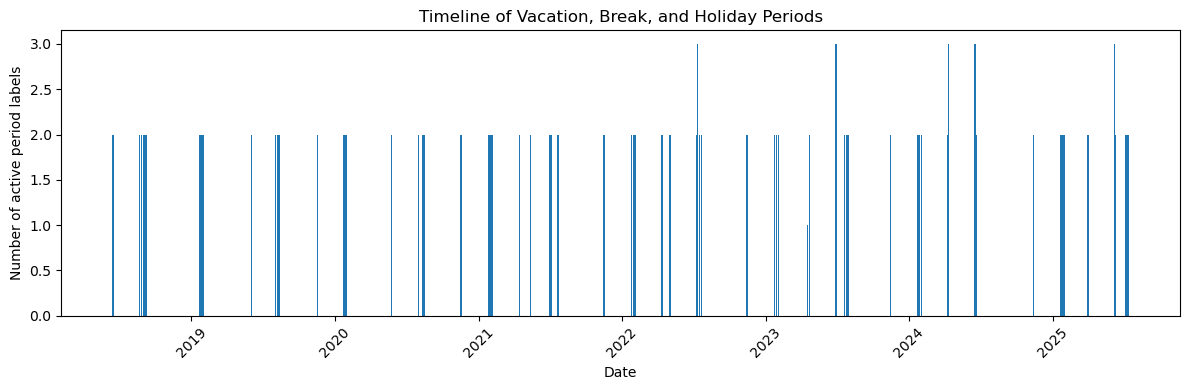

In [65]:
if not vacation_periods_daily.empty:
    vacation_by_year = vacation_periods_daily.copy()
    vacation_by_year["year"] = vacation_by_year["date"].dt.year
    year_summary = (
        vacation_by_year.groupby("year")[vacation_binary_columns]
        .sum()
        .reset_index()
        .sort_values("year")
    )
    display(year_summary)

    timeline_df = vacation_periods_daily.copy()
    timeline_df["active_period_count"] = timeline_df[vacation_binary_columns].sum(axis=1)

    plt.figure(figsize=(12, 4))
    plt.bar(timeline_df["date"], timeline_df["active_period_count"])
    plt.title("Timeline of Vacation, Break, and Holiday Periods")
    plt.xlabel("Date")
    plt.ylabel("Number of active period labels")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("No vacation or break periods were available to visualize."))

In [66]:
if vacation_periods_daily.empty:
    display(Markdown("**Insight:** No vacation-period labels were available, so the later vacation comparisons should be interpreted as unavailable rather than negative results."))
else:
    first_period = vacation_periods_daily["date"].min().date()
    last_period = vacation_periods_daily["date"].max().date()
    travel_days = int(vacation_periods_daily["is_travel_vacation"].sum())
    break_days = int(vacation_periods_daily["is_school_break"].sum())
    holiday_days = int(vacation_periods_daily["is_public_holiday_block"].sum())
    display(Markdown(
        f"**Insight:** Vacation and break labels cover **{first_period}** to **{last_period}**. "
        f"The data include **{travel_days} travel-vacation days**, **{break_days} school-break days**, "
        f"and **{holiday_days} public-holiday-block days**. This gives the analysis a non-academic context layer, "
        "allowing routine disruption and leisure periods to be compared against exam/deadline pressure."
    ))

**Insight:** Vacation and break labels cover **2018-06-14** to **2025-07-14**. The data include **105 travel-vacation days**, **138 school-break days**, and **72 public-holiday-block days**. This gives the analysis a non-academic context layer, allowing routine disruption and leisure periods to be compared against exam/deadline pressure.

## B. Listening Intensity and Frequency During Vacation

The next comparison asks whether travel vacations are associated with changes in listening volume. Two dimensions are used: total listening minutes and number of streams.

Grouped means by travel-vacation status


,total_minutes,num_streams
is_travel_vacation,,
0,86.44,65.28
1,104.50,71.60


Grouped medians by travel-vacation status


,total_minutes,num_streams
is_travel_vacation,,
0,77.42,54.0
1,96.94,62.0


/var/folders/6s/_z262h2n0730l977pljhpqvm0000gn/T/ipykernel_66857/2020638522.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([non_vacation, vacation], labels=["Non-vacation", "Travel vacation"])


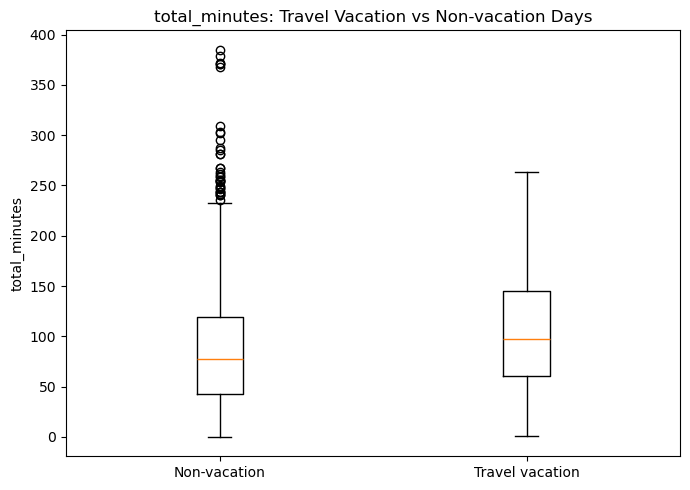

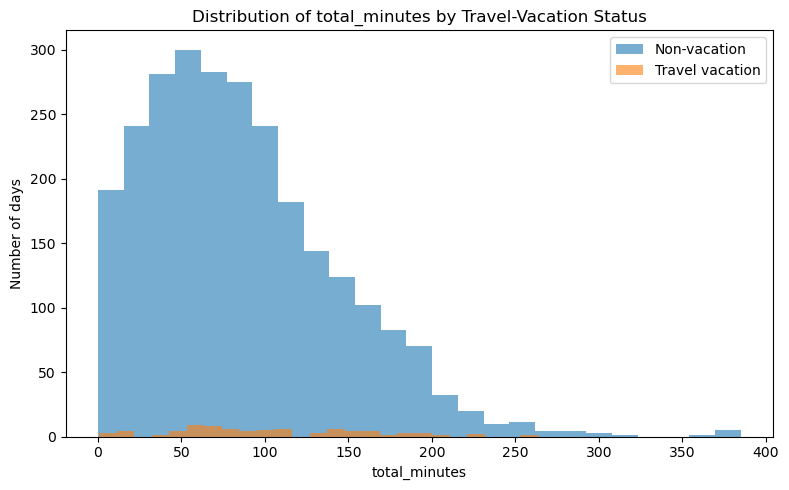

/var/folders/6s/_z262h2n0730l977pljhpqvm0000gn/T/ipykernel_66857/2020638522.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([non_vacation, vacation], labels=["Non-vacation", "Travel vacation"])


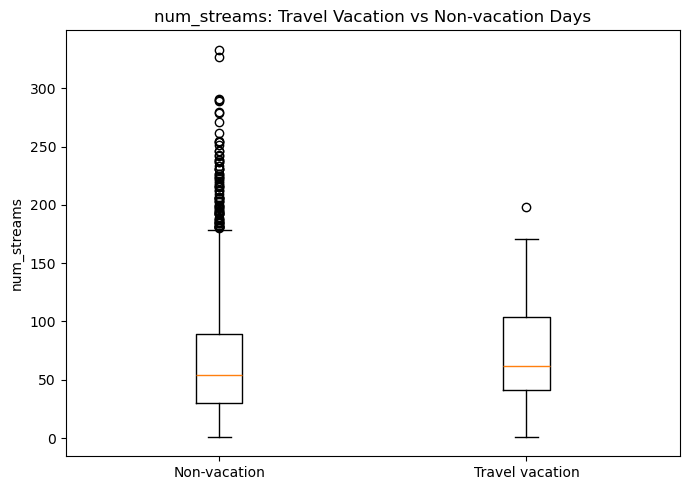

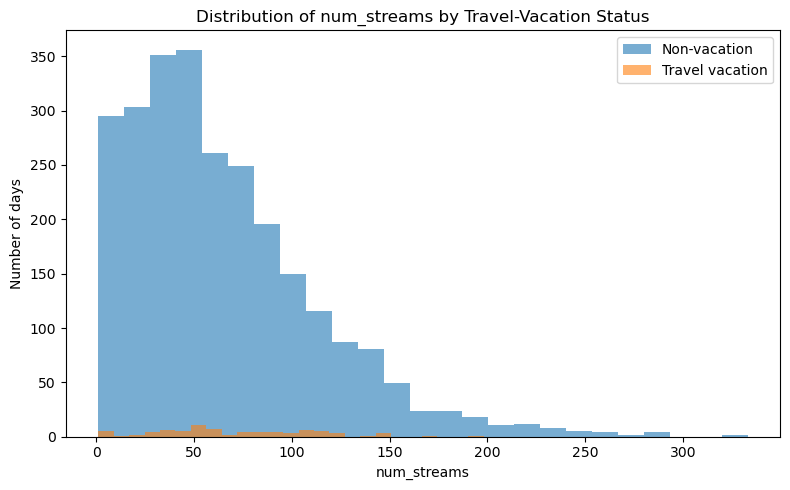

In [67]:
vacation_metrics = [metric for metric in ["total_minutes", "num_streams"] if metric in analysis_with_vacation_df.columns]

if not vacation_metrics:
    display(Markdown("No listening-intensity metrics are available for vacation comparison."))
else:
    mean_table = analysis_with_vacation_df.groupby("is_travel_vacation")[vacation_metrics].mean()
    median_table = analysis_with_vacation_df.groupby("is_travel_vacation")[vacation_metrics].median()

    print("Grouped means by travel-vacation status")
    display(mean_table.round(2))
    print("Grouped medians by travel-vacation status")
    display(median_table.round(2))

    for metric in vacation_metrics:
        non_vacation = analysis_with_vacation_df.loc[analysis_with_vacation_df["is_travel_vacation"] == 0, metric].dropna()
        vacation = analysis_with_vacation_df.loc[analysis_with_vacation_df["is_travel_vacation"] == 1, metric].dropna()

        if len(non_vacation) > 0 and len(vacation) > 0:
            plt.figure(figsize=(7, 5))
            plt.boxplot([non_vacation, vacation], labels=["Non-vacation", "Travel vacation"])
            plt.title(f"{metric}: Travel Vacation vs Non-vacation Days")
            plt.ylabel(metric)
            plt.tight_layout()
            plt.show()

            plt.figure(figsize=(8, 5))
            plt.hist(non_vacation, bins=25, alpha=0.6, label="Non-vacation")
            plt.hist(vacation, bins=25, alpha=0.6, label="Travel vacation")
            plt.title(f"Distribution of {metric} by Travel-Vacation Status")
            plt.xlabel(metric)
            plt.ylabel("Number of days")
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print(f"Skipping plots for {metric}: one group has no observations.")

In [68]:
if vacation_metrics and {"total_minutes", "num_streams"}.issubset(analysis_with_vacation_df.columns):
    comparison = analysis_with_vacation_df.groupby("is_travel_vacation")[["total_minutes", "num_streams"]].mean()
    if {0, 1}.issubset(set(comparison.index)):
        minutes_change = comparison.loc[1, "total_minutes"] - comparison.loc[0, "total_minutes"]
        streams_change = comparison.loc[1, "num_streams"] - comparison.loc[0, "num_streams"]
        direction_minutes = "higher" if minutes_change > 0 else "lower"
        direction_streams = "higher" if streams_change > 0 else "lower"
        display(Markdown(
            f"**Insight:** Travel-vacation days show **{direction_minutes} listening time** by about "
            f"**{abs(minutes_change):.1f} minutes per day** and **{direction_streams} stream frequency** by about "
            f"**{abs(streams_change):.1f} streams per day**. Behaviorally, this comparison separates leisure/travel routine "
            "from ordinary academic routine: more streams can suggest greater availability or travel-based listening, while fewer streams can suggest disrupted access or less need for background music."
        ))
    else:
        display(Markdown("**Insight:** Only one vacation-status group is present, so vacation and non-vacation listening cannot be compared directly."))

**Insight:** Travel-vacation days show **higher listening time** by about **18.1 minutes per day** and **higher stream frequency** by about **6.3 streams per day**. Behaviorally, this comparison separates leisure/travel routine from ordinary academic routine: more streams can suggest greater availability or travel-based listening, while fewer streams can suggest disrupted access or less need for background music.

## C. Listening Time-of-Day During Vacation

Daily totals cannot show when listening happens. This section returns to event-level Spotify records and classifies each play into a daypart: night, morning, afternoon, or evening.

daypart,night,morning,afternoon,evening
vacation_status,,,,
Non-vacation,22958,45588,76442,25253
Travel vacation,273,2932,1919,461


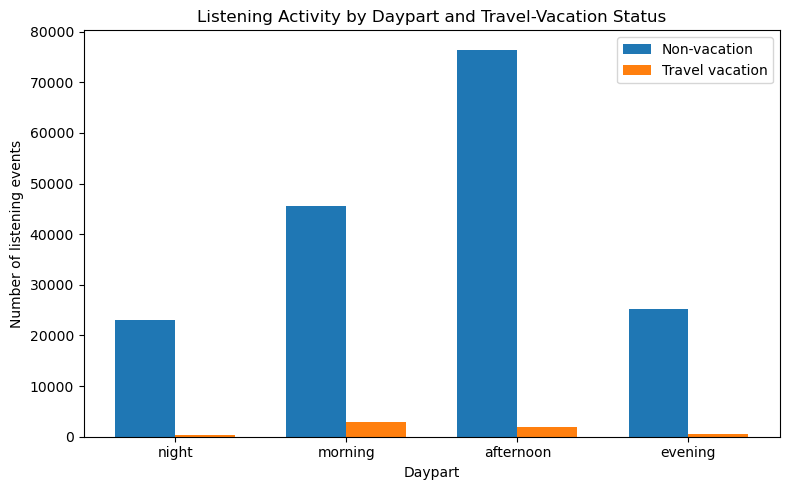

In [69]:
def vacation_get_event_level_spotify():
    """Reuse the event-level Spotify dataframe when available, otherwise reload it safely."""
    for candidate in ["spotify", "spotify_raw"]:
        if candidate in globals() and isinstance(globals()[candidate], pd.DataFrame):
            return globals()[candidate].copy()

    spotify_path = vacation_resolve_project_file("spotify_cleaned.csv", SPOTIFY_PATH)
    if spotify_path.exists():
        return pd.read_csv(spotify_path)

    return pd.DataFrame()


def vacation_assign_daypart(hour):
    if pd.isna(hour):
        return np.nan
    hour = int(hour)
    if 0 <= hour <= 5:
        return "night"
    if 6 <= hour <= 11:
        return "morning"
    if 12 <= hour <= 17:
        return "afternoon"
    return "evening"


spotify_events_vacation = vacation_get_event_level_spotify()
event_vacation_df = pd.DataFrame()

if spotify_events_vacation.empty:
    display(Markdown("Event-level Spotify data is unavailable, so time-of-day vacation analysis cannot be performed."))
else:
    ts_column_vacation = vacation_first_existing(spotify_events_vacation, ["ts", "timestamp", "played_at", "event_timestamp"])
    if ts_column_vacation is None:
        display(Markdown("No timestamp column was found in the Spotify event data, so daypart analysis cannot be performed."))
    else:
        event_vacation_df = spotify_events_vacation.copy()
        event_vacation_df[ts_column_vacation] = pd.to_datetime(event_vacation_df[ts_column_vacation], errors="coerce", utc=True)
        event_vacation_df = event_vacation_df.dropna(subset=[ts_column_vacation]).copy()
        event_vacation_df["date"] = pd.to_datetime(event_vacation_df[ts_column_vacation].dt.date)
        event_vacation_df["hour"] = event_vacation_df[ts_column_vacation].dt.hour
        event_vacation_df["daypart"] = event_vacation_df["hour"].apply(vacation_assign_daypart)
        event_vacation_df = event_vacation_df.merge(
            vacation_periods_daily[["date", "is_travel_vacation"]],
            on="date",
            how="left",
        )
        event_vacation_df["is_travel_vacation"] = event_vacation_df["is_travel_vacation"].fillna(0).astype(int)
        event_vacation_df["vacation_status"] = np.where(event_vacation_df["is_travel_vacation"] == 1, "Travel vacation", "Non-vacation")

        daypart_order = ["night", "morning", "afternoon", "evening"]
        daypart_contingency = pd.crosstab(event_vacation_df["vacation_status"], event_vacation_df["daypart"]).reindex(columns=daypart_order, fill_value=0)
        display(daypart_contingency)

        plot_daypart = daypart_contingency.T
        x_positions = np.arange(len(plot_daypart.index))
        width = 0.35

        plt.figure(figsize=(8, 5))
        if "Non-vacation" in plot_daypart.columns:
            plt.bar(x_positions - width / 2, plot_daypart["Non-vacation"], width, label="Non-vacation")
        if "Travel vacation" in plot_daypart.columns:
            plt.bar(x_positions + width / 2, plot_daypart["Travel vacation"], width, label="Travel vacation")
        plt.title("Listening Activity by Daypart and Travel-Vacation Status")
        plt.xlabel("Daypart")
        plt.ylabel("Number of listening events")
        plt.xticks(x_positions, plot_daypart.index)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [70]:
if "daypart_contingency" in globals() and isinstance(daypart_contingency, pd.DataFrame) and not daypart_contingency.empty:
    vacation_daypart_share = daypart_contingency.div(daypart_contingency.sum(axis=1), axis=0).fillna(0)
    display(vacation_daypart_share.round(3))
    if "Travel vacation" in vacation_daypart_share.index:
        top_daypart = vacation_daypart_share.loc["Travel vacation"].idxmax()
        display(Markdown(
            f"**Insight:** During travel vacations, the largest share of listening events occurs in the **{top_daypart}**. "
            "This is behaviorally meaningful because vacation periods can shift routine timing: later listening may reflect looser schedules, while daytime listening may reflect travel, walking, or leisure time."
        ))
else:
    display(Markdown("**Insight:** Daypart comparison was not available because event-level timestamps or vacation labels were missing."))

daypart,night,morning,afternoon,evening
vacation_status,,,,
Non-vacation,0.135,0.268,0.449,0.148
Travel vacation,0.049,0.525,0.344,0.083


**Insight:** During travel vacations, the largest share of listening events occurs in the **morning**. This is behaviorally meaningful because vacation periods can shift routine timing: later listening may reflect looser schedules, while daytime listening may reflect travel, walking, or leisure time.

## D. Genre Analysis During Vacation

Genre composition is the most direct way to test whether musical taste changes during vacations. The cleaned Spotify export may or may not contain genre columns. If no real genre column exists, the notebook uses artist and track behavior only as a proxy, not as true genre evidence.

**Genre availability note:** No direct genre column was found in the cleaned Spotify dataset. Therefore, formal genre-level vacation testing is not possible from the current file alone. The proxy analysis below uses top artists and tracks during travel vacations, but this should not be interpreted as true genre composition.

Proxy: top artists during travel vacations


,artist,listening_events
0,Motive,351
1,Rammstein,183
2,cakal,148
3,Ati242,126
4,Skapova,104
5,Lvbel C5,98
6,Organize,98
7,BLOK3,89
8,UZI,86
9,Jain,79


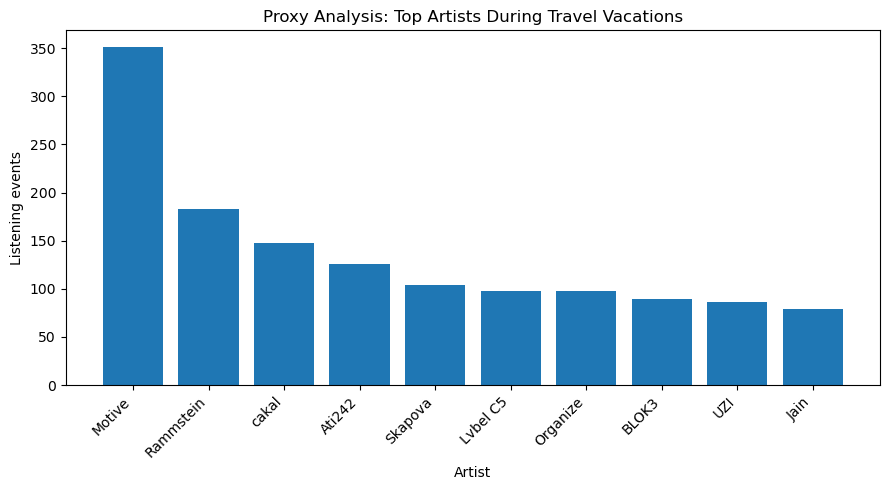

Proxy: top tracks during travel vacations


,track,listening_events
0,MAN DOWN FREESTYLE,49
1,ROMANTİK,49
2,HANIMEFENDİ,44
3,N'aptığını bilmesem de,41
4,Aşk Olsun,35
5,Madem,35
6,Mentalité,34
7,Gülşen,33
8,Body (Remix) [feat. Capo Plaza & Rondodasosa],28
9,Asosyal,26


In [71]:
import ast
import re


def vacation_extract_genre_rows(df, genre_column):
    rows = []
    for _, row in df.dropna(subset=[genre_column]).iterrows():
        raw_value = row[genre_column]
        values = []

        if isinstance(raw_value, list):
            values = raw_value
        else:
            text_value = str(raw_value).strip()
            if not text_value:
                values = []
            else:
                try:
                    parsed = ast.literal_eval(text_value)
                    if isinstance(parsed, list):
                        values = parsed
                    else:
                        values = [text_value]
                except Exception:
                    if any(separator in text_value for separator in [";", "|", ","]):
                        values = re.split(r"[;|,]", text_value)
                    else:
                        values = [text_value]

        for value in values:
            genre = str(value).strip().lower()
            if genre:
                rows.append({
                    "is_travel_vacation": int(row.get("is_travel_vacation", 0)),
                    "vacation_status": row.get("vacation_status", "Non-vacation"),
                    "genre": genre,
                })

    return pd.DataFrame(rows)


genre_columns = []
if not event_vacation_df.empty:
    genre_columns = [
        column for column in event_vacation_df.columns
        if "genre" in column.lower() and event_vacation_df[column].notna().any()
    ]

genre_column = genre_columns[0] if genre_columns else None
genre_vacation_df = pd.DataFrame()
genre_contingency = pd.DataFrame()

if genre_column is not None:
    genre_vacation_df = vacation_extract_genre_rows(event_vacation_df, genre_column)
    if not genre_vacation_df.empty:
        genre_contingency = pd.crosstab(genre_vacation_df["vacation_status"], genre_vacation_df["genre"])
        top_vacation_genres = (
            genre_vacation_df.loc[genre_vacation_df["is_travel_vacation"] == 1, "genre"]
            .value_counts()
            .head(10)
            .reset_index()
        )
        top_vacation_genres.columns = ["genre", "listening_events"]
        print(f"Using genre column: {genre_column}")
        display(top_vacation_genres)

        if not top_vacation_genres.empty:
            plt.figure(figsize=(9, 5))
            plt.bar(top_vacation_genres["genre"], top_vacation_genres["listening_events"])
            plt.title("Top Genres During Travel Vacations")
            plt.xlabel("Genre")
            plt.ylabel("Listening events")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()
    else:
        display(Markdown("A genre-like column exists, but it does not contain usable genre values after normalization."))
else:
    display(Markdown(
        "**Genre availability note:** No direct genre column was found in the cleaned Spotify dataset. "
        "Therefore, formal genre-level vacation testing is not possible from the current file alone. "
        "The proxy analysis below uses top artists and tracks during travel vacations, but this should not be interpreted as true genre composition."
    ))

    artist_column_vacation = vacation_first_existing(
        event_vacation_df,
        ["master_metadata_album_artist_name", "artist_name", "artist", "album_artist"],
    ) if not event_vacation_df.empty else None
    track_column_vacation = vacation_first_existing(
        event_vacation_df,
        ["master_metadata_track_name", "track_name", "track", "episode_name"],
    ) if not event_vacation_df.empty else None

    if artist_column_vacation is not None:
        top_vacation_artists = (
            event_vacation_df.loc[event_vacation_df["is_travel_vacation"] == 1, artist_column_vacation]
            .dropna()
            .astype(str)
            .value_counts()
            .head(10)
            .reset_index()
        )
        top_vacation_artists.columns = ["artist", "listening_events"]
        print("Proxy: top artists during travel vacations")
        display(top_vacation_artists)

        if not top_vacation_artists.empty:
            plt.figure(figsize=(9, 5))
            plt.bar(top_vacation_artists["artist"], top_vacation_artists["listening_events"])
            plt.title("Proxy Analysis: Top Artists During Travel Vacations")
            plt.xlabel("Artist")
            plt.ylabel("Listening events")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()

    if track_column_vacation is not None:
        top_vacation_tracks = (
            event_vacation_df.loc[event_vacation_df["is_travel_vacation"] == 1, track_column_vacation]
            .dropna()
            .astype(str)
            .value_counts()
            .head(10)
            .reset_index()
        )
        top_vacation_tracks.columns = ["track", "listening_events"]
        print("Proxy: top tracks during travel vacations")
        display(top_vacation_tracks)

In [72]:
if genre_column is not None and not genre_vacation_df.empty:
    display(Markdown(
        "**Insight:** A real genre field is available, so vacation genre composition can be evaluated directly. "
        "Differences in top genres would suggest that travel and leisure contexts influence not only how much I listen, but what type of music I choose."
    ))
else:
    display(Markdown(
        "**Insight:** Because direct genre metadata is unavailable, the analysis should avoid claiming genre shifts. "
        "Artist and track concentration can still reveal repetition versus exploration, but it remains a behavioral proxy rather than a genre result."
    ))

**Insight:** Because direct genre metadata is unavailable, the analysis should avoid claiming genre shifts. Artist and track concentration can still reveal repetition versus exploration, but it remains a behavioral proxy rather than a genre result.

# Additional Hypothesis Tests for Vacation Periods

The following tests extend the previous hypothesis-testing section by evaluating vacation-specific behavior. The tests use alpha = 0.05 and are designed to distinguish descriptive differences from statistically detectable differences.

In [73]:
from scipy.stats import chi2_contingency, ttest_ind


VACATION_ALPHA = 0.05
vacation_hypothesis_results = []


def vacation_decision(p_value, alpha=VACATION_ALPHA):
    if pd.isna(p_value):
        return "Test not run"
    return "Reject H0" if p_value < alpha else "Fail to reject H0"


def vacation_run_ttest(df, label_column, metric_column, hypothesis_name):
    if label_column not in df.columns or metric_column not in df.columns:
        print(f"{hypothesis_name}: required columns are missing.")
        return None

    group_1 = pd.to_numeric(df.loc[df[label_column] == 1, metric_column], errors="coerce").dropna()
    group_0 = pd.to_numeric(df.loc[df[label_column] == 0, metric_column], errors="coerce").dropna()

    print(f"{hypothesis_name}")
    print(f"n vacation/status=1: {len(group_1)}")
    print(f"n non-vacation/status=0: {len(group_0)}")

    if len(group_1) < 2 or len(group_0) < 2:
        print("Not enough observations in both groups to run a two-sample t-test.")
        vacation_hypothesis_results.append({
            "hypothesis": hypothesis_name,
            "test": "Welch two-sample t-test",
            "statistic": np.nan,
            "p_value": np.nan,
            "decision": "Test not run",
        })
        return None

    statistic, p_value = ttest_ind(group_1, group_0, equal_var=False, nan_policy="omit")
    decision = vacation_decision(p_value)

    print(f"t-statistic: {statistic:.4f}")
    print(f"p-value: {p_value:.6f}")
    print(f"Decision at alpha={VACATION_ALPHA}: {decision}")

    vacation_hypothesis_results.append({
        "hypothesis": hypothesis_name,
        "test": "Welch two-sample t-test",
        "statistic": statistic,
        "p_value": p_value,
        "decision": decision,
    })
    return statistic, p_value, decision, group_1.mean(), group_0.mean()


def vacation_run_chi_square(contingency_table, hypothesis_name):
    print(hypothesis_name)
    if contingency_table is None or contingency_table.empty or contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
        print("Not enough contingency-table structure to run chi-square test.")
        vacation_hypothesis_results.append({
            "hypothesis": hypothesis_name,
            "test": "Chi-square test of independence",
            "statistic": np.nan,
            "p_value": np.nan,
            "decision": "Test not run",
        })
        return None

    chi2_statistic, p_value, dof, expected = chi2_contingency(contingency_table)
    decision = vacation_decision(p_value)

    print("Observed counts:")
    display(contingency_table)
    print("Expected counts:")
    expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
    display(expected_df.round(2))
    print(f"chi-square statistic: {chi2_statistic:.4f}")
    print(f"p-value: {p_value:.6f}")
    print(f"degrees of freedom: {dof}")
    print(f"Decision at alpha={VACATION_ALPHA}: {decision}")

    vacation_hypothesis_results.append({
        "hypothesis": hypothesis_name,
        "test": "Chi-square test of independence",
        "statistic": chi2_statistic,
        "p_value": p_value,
        "decision": decision,
    })
    return chi2_statistic, p_value, dof, expected_df, decision

## H6 - Genre Distribution During Vacation

**H0:** The distribution of music genres is independent of vacation status.

**HA:** The distribution of music genres differs between vacation and non-vacation periods.

A chi-square test of independence is appropriate when both variables are categorical: vacation status and genre. This test is only valid here if real genre metadata exists.

In [74]:
if genre_column is not None and not genre_contingency.empty:
    h6_result = vacation_run_chi_square(genre_contingency, "H6: Genre distribution during vacation")
    if h6_result is not None:
        decision = h6_result[-1]
        display(Markdown(
            f"**H6 conclusion:** {decision}. "
            "If the null is rejected, vacation status is associated with a different genre mix, suggesting that context may shape music selection. "
            "If not rejected, the available genre data does not provide strong evidence of vacation-specific genre composition."
        ))
else:
    print("H6 cannot be directly tested because no real genre column is available.")
    display(Markdown(
        "**H6 conclusion:** This hypothesis cannot be directly tested with the current cleaned Spotify dataset because no genre column is available. "
        "The artist/track proxy analysis is useful for exploration, but it is not a formal genre-distribution test."
    ))

H6 cannot be directly tested because no real genre column is available.


**H6 conclusion:** This hypothesis cannot be directly tested with the current cleaned Spotify dataset because no genre column is available. The artist/track proxy analysis is useful for exploration, but it is not a formal genre-distribution test.

## H7 - Listening Time and Frequency During Vacation

**H0a:** Mean daily listening time is the same during vacation and non-vacation periods.

**HAa:** Mean daily listening time differs during vacation periods.

**H0b:** Mean daily stream count is the same during vacation and non-vacation periods.

**HAb:** Mean daily stream count differs during vacation periods.

Welch two-sample t-tests are used because vacation and non-vacation groups can have unequal sizes and unequal variance.

In [75]:
h7_minutes = vacation_run_ttest(
    analysis_with_vacation_df,
    "is_travel_vacation",
    "total_minutes",
    "H7a: Daily listening time during vacation",
)

h7_streams = vacation_run_ttest(
    analysis_with_vacation_df,
    "is_travel_vacation",
    "num_streams",
    "H7b: Daily stream count during vacation",
)

if h7_minutes is not None or h7_streams is not None:
    interpretation_parts = []
    if h7_minutes is not None:
        _, p_value, decision, vacation_mean, normal_mean = h7_minutes
        direction = "higher" if vacation_mean > normal_mean else "lower"
        interpretation_parts.append(
            f"daily listening time is {direction} during travel vacations on average "
            f"({vacation_mean:.1f} vs {normal_mean:.1f} minutes), with decision: {decision}"
        )
    if h7_streams is not None:
        _, p_value, decision, vacation_mean, normal_mean = h7_streams
        direction = "higher" if vacation_mean > normal_mean else "lower"
        interpretation_parts.append(
            f"stream count is {direction} during travel vacations on average "
            f"({vacation_mean:.1f} vs {normal_mean:.1f} streams), with decision: {decision}"
        )
    display(Markdown(
        "**H7 conclusion:** " + "; ".join(interpretation_parts) + ". "
        "Behaviorally, significant differences would suggest that travel changes the intensity or frequency of listening, possibly through leisure time, transportation, or routine disruption."
    ))
else:
    display(Markdown("**H7 conclusion:** The vacation listening-time and stream-count tests could not be run because the required data were unavailable or one group was too small."))

H7a: Daily listening time during vacation
n vacation/status=1: 78
n non-vacation/status=0: 2608
t-statistic: 2.6952
p-value: 0.008541
Decision at alpha=0.05: Reject H0
H7b: Daily stream count during vacation
n vacation/status=1: 78
n non-vacation/status=0: 2608
t-statistic: 1.3182
p-value: 0.191053
Decision at alpha=0.05: Fail to reject H0


**H7 conclusion:** daily listening time is higher during travel vacations on average (104.5 vs 86.4 minutes), with decision: Reject H0; stream count is higher during travel vacations on average (71.6 vs 65.3 streams), with decision: Fail to reject H0. Behaviorally, significant differences would suggest that travel changes the intensity or frequency of listening, possibly through leisure time, transportation, or routine disruption.

## H8 - Listening Time-of-Day Behavior During Vacation

**H0:** The distribution of listening activity across dayparts is independent of vacation status.

**HA:** The distribution of listening activity across dayparts differs during vacation periods.

A chi-square test is appropriate because both variables are categorical: vacation status and daypart.

In [76]:
if "daypart_contingency" in globals() and isinstance(daypart_contingency, pd.DataFrame) and not daypart_contingency.empty:
    h8_result = vacation_run_chi_square(daypart_contingency, "H8: Daypart distribution during vacation")
    if h8_result is not None:
        decision = h8_result[-1]
        display(Markdown(
            f"**H8 conclusion:** {decision}. "
            "A rejection would indicate that vacation periods shift when listening happens during the day, which would support the idea that travel and breaks change routine timing. "
            "Failing to reject would suggest that the overall daily rhythm of listening remains relatively stable across vacation and non-vacation contexts."
        ))
else:
    print("H8 cannot be tested because event-level daypart counts are unavailable.")
    display(Markdown("**H8 conclusion:** The daypart hypothesis could not be tested because event-level timestamp data or vacation labels were unavailable."))

H8: Daypart distribution during vacation
Observed counts:


daypart,night,morning,afternoon,evening
vacation_status,,,,
Non-vacation,22958,45588,76442,25253
Travel vacation,273,2932,1919,461


Expected counts:


daypart,night,morning,afternoon,evening
vacation_status,,,,
Non-vacation,22493.08,46978.79,75871.91,24897.21
Travel vacation,737.92,1541.21,2489.09,816.79


chi-square statistic: 1893.6771
p-value: 0.000000
degrees of freedom: 3
Decision at alpha=0.05: Reject H0


**H8 conclusion:** Reject H0. A rejection would indicate that vacation periods shift when listening happens during the day, which would support the idea that travel and breaks change routine timing. Failing to reject would suggest that the overall daily rhythm of listening remains relatively stable across vacation and non-vacation contexts.

## Vacation Extension Summary

This extension adds a non-academic context layer to the project. Exams and deadlines capture pressure, while vacations and breaks capture routine disruption, leisure, and location change. Together, these contexts make the project more behavioral: the analysis now asks not only whether listening changes under stress, but also whether it changes when time becomes less academically structured.

In [77]:
if vacation_hypothesis_results:
    vacation_hypothesis_results_df = pd.DataFrame(vacation_hypothesis_results)
    display(vacation_hypothesis_results_df)
else:
    display(Markdown("No vacation hypothesis tests were run."))

,hypothesis,test,statistic,p_value,decision
0,H7a: Daily listening time during vacation,Welch two-sample t-test,2.695250,0.008541,Reject H0
1,H7b: Daily stream count during vacation,Welch two-sample t-test,1.318180,0.191053,Fail to reject H0
2,H8: Daypart distribution during vacation,Chi-square test of independence,1893.677052,0.000000,Reject H0


# Coverage-Aware Correction for Limited Label Data

The Spotify streaming dataset covers a long period, but the context-label files do not necessarily cover the exact same range. This matters statistically: if a label file ends earlier than the Spotify data, then days after the label file ends should not automatically be treated as true non-vacation or non-special days.

This section adds a correction by defining explicit coverage windows for the calendar/special-date labels and the travel/break labels. The cleaner interpretation should rely on comparisons made inside the relevant coverage window.

In [78]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.stats import chi2_contingency, ttest_ind


COVERAGE_ALPHA = 0.05
BASE_DIR = Path.home() / "Desktop" / "DSA210 TERM PROJECT"


def coverage_resolve_project_file(filename):
    matches = sorted(BASE_DIR.rglob(filename))
    if matches:
        return matches[0]
    return BASE_DIR / filename


def coverage_first_existing(df, candidates):
    for column in candidates:
        if column in df.columns:
            return column
    return None


def coverage_decision(p_value, alpha=COVERAGE_ALPHA):
    if pd.isna(p_value):
        return "Test not run"
    return "Reject H0" if p_value < alpha else "Fail to reject H0"


def coverage_binary(series):
    if series.dtype == bool:
        return series.astype(int)
    normalized = series.astype(str).str.lower().str.strip()
    mapped = normalized.map({
        "true": 1,
        "false": 0,
        "yes": 1,
        "no": 0,
        "1": 1,
        "0": 0,
        "nan": 0,
        "none": 0,
        "": 0,
    })
    return mapped.fillna(pd.to_numeric(series, errors="coerce")).fillna(0).astype(int)


def coverage_get_analysis_df():
    if "analysis_with_vacation_df" in globals() and isinstance(globals()["analysis_with_vacation_df"], pd.DataFrame):
        df = globals()["analysis_with_vacation_df"].copy()
    elif "analysis_df" in globals() and isinstance(globals()["analysis_df"], pd.DataFrame):
        df = globals()["analysis_df"].copy()
    else:
        raise ValueError("Daily analysis dataframe is not available. Run the preprocessing cells first.")

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    return df.dropna(subset=["date"]).copy()


def coverage_get_special_df():
    if "special" in globals() and isinstance(globals()["special"], pd.DataFrame):
        df = globals()["special"].copy()
    elif "special_raw" in globals() and isinstance(globals()["special_raw"], pd.DataFrame):
        df = globals()["special_raw"].copy()
    else:
        path = coverage_resolve_project_file("special_dates.csv")
        df = pd.read_csv(path) if path.exists() else pd.DataFrame()

    if not df.empty and "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df = df.dropna(subset=["date"]).copy()
    return df


def coverage_get_travel_df():
    if "travel_periods_raw" in globals() and isinstance(globals()["travel_periods_raw"], pd.DataFrame):
        df = globals()["travel_periods_raw"].copy()
    else:
        path = coverage_resolve_project_file("travel_and_break_periods.csv")
        df = pd.read_csv(path) if path.exists() else pd.DataFrame()

    if not df.empty:
        df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")
        df["end_date"] = pd.to_datetime(df["end_date"], errors="coerce")
        df = df.dropna(subset=["start_date", "end_date"]).copy()
    return df


analysis_coverage_base_df = coverage_get_analysis_df()
special_coverage_raw_df = coverage_get_special_df()
travel_coverage_raw_df = coverage_get_travel_df()

streaming_min_date = analysis_coverage_base_df["date"].min()
streaming_max_date = analysis_coverage_base_df["date"].max()

special_min_date = special_coverage_raw_df["date"].min() if not special_coverage_raw_df.empty and "date" in special_coverage_raw_df.columns else pd.NaT
special_max_date = special_coverage_raw_df["date"].max() if not special_coverage_raw_df.empty and "date" in special_coverage_raw_df.columns else pd.NaT

travel_min_date = travel_coverage_raw_df["start_date"].min() if not travel_coverage_raw_df.empty else pd.NaT
travel_max_date = travel_coverage_raw_df["end_date"].max() if not travel_coverage_raw_df.empty else pd.NaT

coverage_summary_df = pd.DataFrame([
    {
        "dataset": "spotify_daily_behavior",
        "coverage_start": streaming_min_date,
        "coverage_end": streaming_max_date,
        "rows_or_days": len(analysis_coverage_base_df),
        "interpretation": "Full available daily listening behavior.",
    },
    {
        "dataset": "special_dates_labels",
        "coverage_start": special_min_date,
        "coverage_end": special_max_date,
        "rows_or_days": len(special_coverage_raw_df),
        "interpretation": "Only this window should be used when treating missing exam/deadline/stress labels as 0.",
    },
    {
        "dataset": "travel_and_break_periods",
        "coverage_start": travel_min_date,
        "coverage_end": travel_max_date,
        "rows_or_days": len(travel_coverage_raw_df),
        "interpretation": "Only this window should be used when treating missing travel/break labels as 0.",
    },
])

display(coverage_summary_df)

analysis_special_coverage_df = analysis_coverage_base_df.copy()
if pd.notna(special_min_date) and pd.notna(special_max_date):
    analysis_special_coverage_df = analysis_special_coverage_df[
        analysis_special_coverage_df["date"].between(special_min_date, special_max_date)
    ].copy()

analysis_vacation_coverage_df = analysis_coverage_base_df.copy()
if pd.notna(travel_min_date) and pd.notna(travel_max_date):
    analysis_vacation_coverage_df = analysis_vacation_coverage_df[
        analysis_vacation_coverage_df["date"].between(travel_min_date, travel_max_date)
    ].copy()

print("Daily rows in full Spotify analysis:", len(analysis_coverage_base_df))
print("Daily rows inside special-date label coverage:", len(analysis_special_coverage_df))
print("Daily rows inside travel/break label coverage:", len(analysis_vacation_coverage_df))

,dataset,coverage_start,coverage_end,rows_or_days,interpretation
0,spotify_daily_behavior,2018-09-21,2026-03-30,2686,Full available daily listening behavior.
1,special_dates_labels,2024-07-15,2026-05-17,251,Only this window should be used when treating ...
2,travel_and_break_periods,2018-06-14,2025-07-14,45,Only this window should be used when treating ...


Daily rows in full Spotify analysis: 2686
Daily rows inside special-date label coverage: 590
Daily rows inside travel/break label coverage: 2431


In [79]:
display(Markdown(
    "**Coverage insight:** The original full-period Spotify dataset is useful for general listening patterns, "
    "but context comparisons should be made only where the relevant context labels are observable. "
    "For vacation analysis, days after the travel/break label coverage ends are not reliable non-vacation controls. "
    "For exam/deadline/stress analysis, days outside the calendar label coverage should not be interpreted as confirmed normal academic days."
))

**Coverage insight:** The original full-period Spotify dataset is useful for general listening patterns, but context comparisons should be made only where the relevant context labels are observable. For vacation analysis, days after the travel/break label coverage ends are not reliable non-vacation controls. For exam/deadline/stress analysis, days outside the calendar label coverage should not be interpreted as confirmed normal academic days.

## Coverage-Aware Special-Day Tests

The previous academic-context tests are repeated inside the available special-date coverage window. This avoids comparing labeled exam/deadline/stress days against years where the calendar label file may not have been available.

In [80]:
coverage_results = []


def coverage_run_ttest(df, label_column, metric_column, hypothesis_name):
    if label_column not in df.columns or metric_column not in df.columns:
        print(f"{hypothesis_name}: skipped because {label_column} or {metric_column} is missing.")
        coverage_results.append({
            "hypothesis": hypothesis_name,
            "test": "Welch two-sample t-test",
            "n_label_1": np.nan,
            "n_label_0": np.nan,
            "statistic": np.nan,
            "p_value": np.nan,
            "decision": "Test not run",
        })
        return None

    group_1 = pd.to_numeric(df.loc[df[label_column] == 1, metric_column], errors="coerce").dropna()
    group_0 = pd.to_numeric(df.loc[df[label_column] == 0, metric_column], errors="coerce").dropna()

    print(f"\n{hypothesis_name}")
    print(f"n {label_column}=1: {len(group_1)}")
    print(f"n {label_column}=0: {len(group_0)}")

    if len(group_1) < 2 or len(group_0) < 2:
        print("Not enough observations in both groups.")
        coverage_results.append({
            "hypothesis": hypothesis_name,
            "test": "Welch two-sample t-test",
            "n_label_1": len(group_1),
            "n_label_0": len(group_0),
            "statistic": np.nan,
            "p_value": np.nan,
            "decision": "Test not run",
        })
        return None

    statistic, p_value = ttest_ind(group_1, group_0, equal_var=False, nan_policy="omit")
    decision = coverage_decision(p_value)

    print(f"t-statistic: {statistic:.4f}")
    print(f"p-value: {p_value:.6f}")
    print(f"Decision at alpha={COVERAGE_ALPHA}: {decision}")
    print(f"mean {label_column}=1: {group_1.mean():.3f}")
    print(f"mean {label_column}=0: {group_0.mean():.3f}")

    coverage_results.append({
        "hypothesis": hypothesis_name,
        "test": "Welch two-sample t-test",
        "n_label_1": len(group_1),
        "n_label_0": len(group_0),
        "statistic": statistic,
        "p_value": p_value,
        "decision": decision,
    })
    return statistic, p_value, decision


coverage_run_ttest(
    analysis_special_coverage_df,
    "is_exam",
    "total_minutes",
    "Coverage-aware H1: exam vs non-exam daily listening time",
)

coverage_run_ttest(
    analysis_special_coverage_df,
    "is_stress_period",
    "skip_rate",
    "Coverage-aware H2: stress vs non-stress skip rate",
)

coverage_run_ttest(
    analysis_special_coverage_df,
    "is_stress_period",
    "unique_artists",
    "Coverage-aware H3: stress vs non-stress artist diversity",
)

coverage_run_ttest(
    analysis_special_coverage_df,
    "is_deadline",
    "num_streams",
    "Coverage-aware H4: deadline vs non-deadline stream count",
)


Coverage-aware H1: exam vs non-exam daily listening time
n is_exam=1: 17
n is_exam=0: 573
t-statistic: -0.1653
p-value: 0.870674
Decision at alpha=0.05: Fail to reject H0
mean is_exam=1: 83.814
mean is_exam=0: 85.993

Coverage-aware H2: stress vs non-stress skip rate
n is_stress_period=1: 150
n is_stress_period=0: 440
t-statistic: -0.1065
p-value: 0.915261
Decision at alpha=0.05: Fail to reject H0
mean is_stress_period=1: 0.685
mean is_stress_period=0: 0.687

Coverage-aware H3: stress vs non-stress artist diversity
n is_stress_period=1: 150
n is_stress_period=0: 440
t-statistic: 4.8860
p-value: 0.000002
Decision at alpha=0.05: Reject H0
mean is_stress_period=1: 57.400
mean is_stress_period=0: 39.845

Coverage-aware H4: deadline vs non-deadline stream count
n is_deadline=1: 42
n is_deadline=0: 548
t-statistic: 3.5578
p-value: 0.000871
Decision at alpha=0.05: Reject H0
mean is_deadline=1: 114.833
mean is_deadline=0: 79.670


(np.float64(3.5577588648503573),
 np.float64(0.0008707078000697212),
 'Reject H0')

In [81]:
display(Markdown(
    "**Interpretation:** These coverage-aware academic tests should be treated as the more methodologically reliable version "
    "of the exam/deadline/stress comparisons. They compare special days only against days from the same observable calendar-label period, "
    "which reduces the risk of calling an unlabeled historical day a true normal day."
))

**Interpretation:** These coverage-aware academic tests should be treated as the more methodologically reliable version of the exam/deadline/stress comparisons. They compare special days only against days from the same observable calendar-label period, which reduces the risk of calling an unlabeled historical day a true normal day.

## Coverage-Aware Vacation Tests

The vacation tests are repeated inside the travel/break period coverage window. This is especially important because the travel file ends before the Spotify streaming dataset ends.

In [82]:
coverage_run_ttest(
    analysis_vacation_coverage_df,
    "is_travel_vacation",
    "total_minutes",
    "Coverage-aware H7a: vacation vs non-vacation daily listening time",
)

coverage_run_ttest(
    analysis_vacation_coverage_df,
    "is_travel_vacation",
    "num_streams",
    "Coverage-aware H7b: vacation vs non-vacation daily stream count",
)


event_vacation_coverage_df = pd.DataFrame()
if "event_vacation_df" in globals() and isinstance(globals()["event_vacation_df"], pd.DataFrame) and not event_vacation_df.empty:
    event_vacation_coverage_df = event_vacation_df.copy()
    event_vacation_coverage_df["date"] = pd.to_datetime(event_vacation_coverage_df["date"], errors="coerce")
    if pd.notna(travel_min_date) and pd.notna(travel_max_date):
        event_vacation_coverage_df = event_vacation_coverage_df[
            event_vacation_coverage_df["date"].between(travel_min_date, travel_max_date)
        ].copy()

if not event_vacation_coverage_df.empty and {"vacation_status", "daypart"}.issubset(event_vacation_coverage_df.columns):
    daypart_order = ["night", "morning", "afternoon", "evening"]
    coverage_daypart_contingency = (
        pd.crosstab(event_vacation_coverage_df["vacation_status"], event_vacation_coverage_df["daypart"])
        .reindex(columns=daypart_order, fill_value=0)
    )
    display(coverage_daypart_contingency)

    if coverage_daypart_contingency.shape[0] >= 2 and coverage_daypart_contingency.shape[1] >= 2:
        chi2_statistic, p_value, dof, expected = chi2_contingency(coverage_daypart_contingency)
        expected_df = pd.DataFrame(expected, index=coverage_daypart_contingency.index, columns=coverage_daypart_contingency.columns)
        display(expected_df.round(2))
        decision = coverage_decision(p_value)
        print("Coverage-aware H8: vacation status and listening daypart")
        print(f"chi-square statistic: {chi2_statistic:.4f}")
        print(f"p-value: {p_value:.6f}")
        print(f"degrees of freedom: {dof}")
        print(f"Decision at alpha={COVERAGE_ALPHA}: {decision}")
        coverage_results.append({
            "hypothesis": "Coverage-aware H8: vacation status and listening daypart",
            "test": "Chi-square test of independence",
            "n_label_1": int((event_vacation_coverage_df["is_travel_vacation"] == 1).sum()) if "is_travel_vacation" in event_vacation_coverage_df.columns else np.nan,
            "n_label_0": int((event_vacation_coverage_df["is_travel_vacation"] == 0).sum()) if "is_travel_vacation" in event_vacation_coverage_df.columns else np.nan,
            "statistic": chi2_statistic,
            "p_value": p_value,
            "decision": decision,
        })
    else:
        print("Coverage-aware H8 skipped: contingency table does not contain both vacation statuses and dayparts.")
else:
    print("Coverage-aware H8 skipped: event-level daypart data is unavailable.")


Coverage-aware H7a: vacation vs non-vacation daily listening time
n is_travel_vacation=1: 78
n is_travel_vacation=0: 2353
t-statistic: 2.8319
p-value: 0.005821
Decision at alpha=0.05: Reject H0
mean is_travel_vacation=1: 104.498
mean is_travel_vacation=0: 85.491

Coverage-aware H7b: vacation vs non-vacation daily stream count
n is_travel_vacation=1: 78
n is_travel_vacation=0: 2353
t-statistic: 2.1449
p-value: 0.034881
Decision at alpha=0.05: Reject H0
mean is_travel_vacation=1: 71.603
mean is_travel_vacation=0: 61.320


daypart,night,morning,afternoon,evening
vacation_status,,,,
Non-vacation,20934,37140,66032,20179
Travel vacation,273,2932,1919,461


daypart,night,morning,afternoon,evening
vacation_status,,,,
Non-vacation,20416.71,38578.69,65418.76,19870.84
Travel vacation,790.29,1493.31,2532.24,769.16


Coverage-aware H8: vacation status and listening daypart
chi-square statistic: 2073.9299
p-value: 0.000000
degrees of freedom: 3
Decision at alpha=0.05: Reject H0


In [83]:
coverage_results_df = pd.DataFrame(coverage_results)
display(coverage_results_df)

display(Markdown(
    "**Updated methodological conclusion:** Yes, the notebook needs this correction because the label datasets are not equally complete over time. "
    "The full Spotify dataset remains valuable for baseline behavior, but hypothesis tests involving exams, stress, deadlines, vacations, or breaks should be interpreted within the date range where those labels are available. "
    "This makes the study clearer, avoids false control days, and makes the final conclusions more defensible."
))

,hypothesis,test,n_label_1,n_label_0,statistic,p_value,decision
0,Coverage-aware H1: exam vs non-exam daily list...,Welch two-sample t-test,17,573,-0.165277,0.870674,Fail to reject H0
1,Coverage-aware H2: stress vs non-stress skip rate,Welch two-sample t-test,150,440,-0.106515,0.915261,Fail to reject H0
2,Coverage-aware H3: stress vs non-stress artist...,Welch two-sample t-test,150,440,4.886028,0.000002,Reject H0
3,Coverage-aware H4: deadline vs non-deadline st...,Welch two-sample t-test,42,548,3.557759,0.000871,Reject H0
4,Coverage-aware H7a: vacation vs non-vacation d...,Welch two-sample t-test,78,2353,2.831863,0.005821,Reject H0
5,Coverage-aware H7b: vacation vs non-vacation d...,Welch two-sample t-test,78,2353,2.144919,0.034881,Reject H0
6,Coverage-aware H8: vacation status and listeni...,Chi-square test of independence,5585,144285,2073.929888,0.000000,Reject H0


**Updated methodological conclusion:** Yes, the notebook needs this correction because the label datasets are not equally complete over time. The full Spotify dataset remains valuable for baseline behavior, but hypothesis tests involving exams, stress, deadlines, vacations, or breaks should be interpreted within the date range where those labels are available. This makes the study clearer, avoids false control days, and makes the final conclusions more defensible.

# Entrance Exam Preparation Context: LGS and YKS

This project already studies exams, deadlines, stress periods, travel, and breaks. However, two major long-term academic contexts are especially important for interpreting listening behavior:

- **LGS preparation:** 2019-2020 education year, with the exam period in June 2020.
- **YKS preparation:** 2023-2024 education year, with the exam period in June 2024.

Because both exams take place in June, this section treats the final phase before June as a higher-stress preparation window. To keep the analysis transparent, the notebook uses rule-based period labels instead of pretending to know exact daily stress intensity.

## Period Definition and Assumptions

The preparation periods are defined as full education-year windows from September through June. The high-stress phase is defined as March through June, capturing the final preparation months and the exam month itself.

This is a modeling assumption. It is useful because it creates a consistent way to compare ordinary preparation months against the final high-pressure phase for both LGS and YKS.

In [84]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from scipy.stats import ttest_ind


ENTRANCE_ALPHA = 0.05
BASE_DIR = Path.home() / "Desktop" / "DSA210 TERM PROJECT"


def entrance_resolve_project_file(filename):
    matches = sorted(BASE_DIR.rglob(filename))
    if matches:
        return matches[0]
    return BASE_DIR / filename


def entrance_first_existing(df, candidates):
    for column in candidates:
        if column in df.columns:
            return column
    return None


def entrance_binary(series):
    if series.dtype == bool:
        return series.astype(int)
    normalized = series.astype(str).str.lower().str.strip()
    mapped = normalized.map({
        "true": 1,
        "false": 0,
        "yes": 1,
        "no": 0,
        "1": 1,
        "0": 0,
        "nan": 0,
        "none": 0,
        "": 0,
    })
    return mapped.fillna(pd.to_numeric(series, errors="coerce")).fillna(0).astype(int)


def entrance_get_daily_analysis_df():
    # Reuse the richest daily dataframe available; reconstruct only if needed.
    for candidate in ["analysis_with_vacation_df", "analysis_coverage_base_df", "analysis_df", "daily_df"]:
        if candidate in globals() and isinstance(globals()[candidate], pd.DataFrame):
            daily = globals()[candidate].copy()
            daily["date"] = pd.to_datetime(daily["date"], errors="coerce")
            return daily.dropna(subset=["date"]).copy()

    spotify_path = entrance_resolve_project_file("spotify_cleaned.csv")
    if not spotify_path.exists():
        raise FileNotFoundError("spotify_cleaned.csv could not be found in the project folder or subfolders.")

    spotify_raw_local = pd.read_csv(spotify_path)
    ts_column = entrance_first_existing(spotify_raw_local, ["ts", "timestamp", "played_at", "event_timestamp"])
    ms_column = entrance_first_existing(spotify_raw_local, ["ms_played", "msPlayed", "milliseconds_played"])
    artist_column = entrance_first_existing(
        spotify_raw_local,
        ["master_metadata_album_artist_name", "artist_name", "artist", "album_artist"],
    )
    track_column = entrance_first_existing(
        spotify_raw_local,
        ["master_metadata_track_name", "track_name", "track", "episode_name"],
    )
    skipped_column = entrance_first_existing(spotify_raw_local, ["skipped", "skip", "was_skipped"])
    shuffle_column = entrance_first_existing(spotify_raw_local, ["shuffle", "shuffle_state", "is_shuffle"])

    if ts_column is None or ms_column is None:
        raise ValueError("Cannot reconstruct daily behavior without timestamp and ms_played columns.")

    events = spotify_raw_local.copy()
    events[ts_column] = pd.to_datetime(events[ts_column], errors="coerce", utc=True)
    events = events.dropna(subset=[ts_column]).copy()
    events["date"] = pd.to_datetime(events[ts_column].dt.date)
    events[ms_column] = pd.to_numeric(events[ms_column], errors="coerce").fillna(0)

    daily = events.groupby("date").agg(total_ms=(ms_column, "sum"), num_streams=(ms_column, "size")).reset_index()
    daily["total_minutes"] = daily["total_ms"] / 60000
    daily["unique_artists"] = events.groupby("date")[artist_column].nunique().values if artist_column else np.nan
    daily["unique_tracks"] = events.groupby("date")[track_column].nunique().values if track_column else np.nan
    daily["skip_rate"] = events.groupby("date")[skipped_column].apply(lambda x: entrance_binary(x).mean()).values if skipped_column else np.nan
    daily["shuffle_rate"] = events.groupby("date")[shuffle_column].apply(lambda x: entrance_binary(x).mean()).values if shuffle_column else np.nan
    return daily


entrance_periods = pd.DataFrame([
    {
        "exam_type": "LGS",
        "exam_description": "High School Entrance Exam",
        "education_year": "2019-2020",
        "prep_start": "2019-09-01",
        "prep_end": "2020-06-30",
        "high_stress_start": "2020-03-01",
        "high_stress_end": "2020-06-30",
        "assumption": "Final preparation months plus June exam month",
    },
    {
        "exam_type": "YKS",
        "exam_description": "University Entrance Exam",
        "education_year": "2023-2024",
        "prep_start": "2023-09-01",
        "prep_end": "2024-06-30",
        "high_stress_start": "2024-03-01",
        "high_stress_end": "2024-06-30",
        "assumption": "Final preparation months plus June exam month",
    },
])

for column in ["prep_start", "prep_end", "high_stress_start", "high_stress_end"]:
    entrance_periods[column] = pd.to_datetime(entrance_periods[column])

display(entrance_periods)

,exam_type,exam_description,education_year,prep_start,prep_end,high_stress_start,high_stress_end,assumption
0,LGS,High School Entrance Exam,2019-2020,2019-09-01,2020-06-30,2020-03-01,2020-06-30,Final preparation months plus June exam month
1,YKS,University Entrance Exam,2023-2024,2023-09-01,2024-06-30,2024-03-01,2024-06-30,Final preparation months plus June exam month


In [85]:
def expand_entrance_exam_periods(periods_df):
    rows = []
    for _, period in periods_df.iterrows():
        for active_date in pd.date_range(period["prep_start"], period["prep_end"], freq="D"):
            is_high_stress = int(period["high_stress_start"] <= active_date <= period["high_stress_end"])
            rows.append({
                "date": pd.to_datetime(active_date.date()),
                "entrance_exam_type": period["exam_type"],
                "entrance_exam_description": period["exam_description"],
                "entrance_education_year": period["education_year"],
                "is_lgs_prep": int(period["exam_type"] == "LGS"),
                "is_yks_prep": int(period["exam_type"] == "YKS"),
                "is_entrance_exam_prep": 1,
                "is_lgs_high_stress": int(period["exam_type"] == "LGS" and is_high_stress == 1),
                "is_yks_high_stress": int(period["exam_type"] == "YKS" and is_high_stress == 1),
                "is_entrance_exam_high_stress": is_high_stress,
                "entrance_exam_phase": "final_high_stress" if is_high_stress else "general_preparation",
            })

    return pd.DataFrame(rows)


entrance_exam_daily = expand_entrance_exam_periods(entrance_periods)
analysis_entrance_base_df = entrance_get_daily_analysis_df()
analysis_entrance_base_df["date"] = pd.to_datetime(analysis_entrance_base_df["date"], errors="coerce")

entrance_columns_to_drop = [
    "entrance_exam_type",
    "entrance_exam_description",
    "entrance_education_year",
    "is_lgs_prep",
    "is_yks_prep",
    "is_entrance_exam_prep",
    "is_lgs_high_stress",
    "is_yks_high_stress",
    "is_entrance_exam_high_stress",
    "entrance_exam_phase",
]

analysis_entrance_df = analysis_entrance_base_df.drop(columns=entrance_columns_to_drop, errors="ignore").merge(
    entrance_exam_daily,
    on="date",
    how="left",
)

entrance_binary_columns = [
    "is_lgs_prep",
    "is_yks_prep",
    "is_entrance_exam_prep",
    "is_lgs_high_stress",
    "is_yks_high_stress",
    "is_entrance_exam_high_stress",
]

for column in entrance_binary_columns:
    analysis_entrance_df[column] = pd.to_numeric(analysis_entrance_df[column], errors="coerce").fillna(0).astype(int)

for column in ["entrance_exam_type", "entrance_exam_description", "entrance_education_year", "entrance_exam_phase"]:
    analysis_entrance_df[column] = analysis_entrance_df[column].fillna("").astype(str)

entrance_overlap_summary = (
    analysis_entrance_df.loc[analysis_entrance_df["is_entrance_exam_prep"] == 1]
    .groupby(["entrance_exam_type", "entrance_exam_phase"])
    .agg(
        spotify_days=("date", "nunique"),
        mean_total_minutes=("total_minutes", "mean"),
        median_total_minutes=("total_minutes", "median"),
        mean_num_streams=("num_streams", "mean"),
        mean_unique_artists=("unique_artists", "mean"),
    )
    .reset_index()
)

print("Entrance exam daily labels:", entrance_exam_daily.shape)
print("Daily Spotify rows with entrance-exam labels:", int(analysis_entrance_df["is_entrance_exam_prep"].sum()))
display(entrance_overlap_summary.round(2))

Entrance exam daily labels: (608, 11)
Daily Spotify rows with entrance-exam labels: 599


,entrance_exam_type,entrance_exam_phase,spotify_days,mean_total_minutes,median_total_minutes,mean_num_streams,mean_unique_artists
0,LGS,final_high_stress,122,116.10,104.31,88.41,41.48
1,LGS,general_preparation,179,58.47,54.15,42.66,21.87
2,YKS,final_high_stress,118,67.44,60.55,53.22,26.90
3,YKS,general_preparation,180,59.60,55.23,51.74,28.96


In [86]:
display(Markdown(
    "**Labeling insight:** The entrance-exam labels are intentionally period-based rather than single-day labels. "
    "This is appropriate because LGS and YKS preparation are long-term academic contexts: the behavioral question is not only whether music changes on the exam day, "
    "but whether listening shifts during the preparation cycle and especially during the final high-stress phase."
))

**Labeling insight:** The entrance-exam labels are intentionally period-based rather than single-day labels. This is appropriate because LGS and YKS preparation are long-term academic contexts: the behavioral question is not only whether music changes on the exam day, but whether listening shifts during the preparation cycle and especially during the final high-stress phase.

## Listening Behavior Across LGS and YKS Preparation

The next view compares the full preparation periods and highlights whether the final high-stress phase differs from general preparation months.

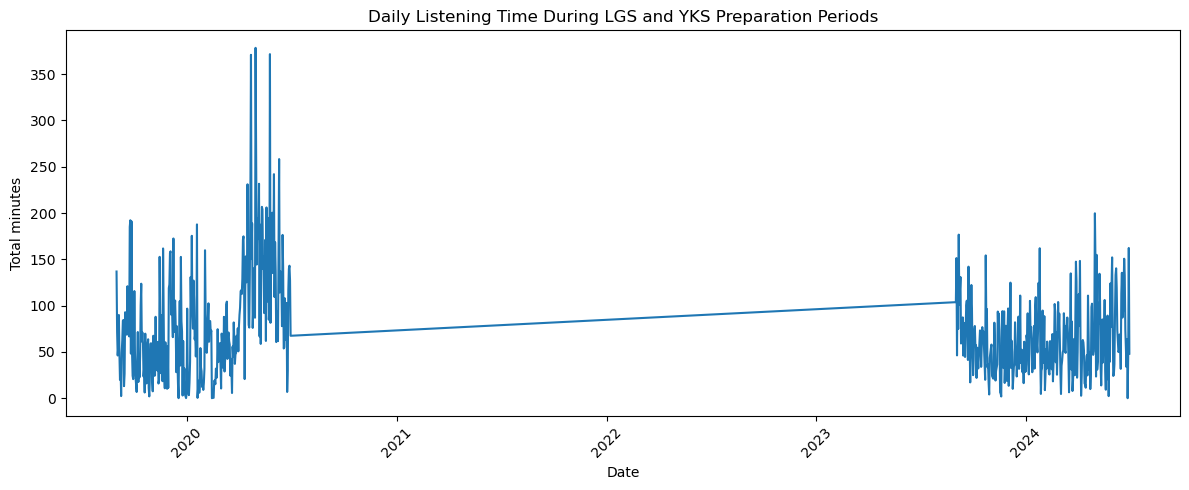

total_minutes                 num_streams               unique_artists               skip_rate  \
                                               count    mean  median       count   mean median          count   mean median     count   
entrance_exam_type entrance_exam_phase                                                                                                  
LGS                final_high_stress             122  116.10  104.31         122  88.41   75.0            122  41.48   37.0       122   
                   general_preparation           179   58.47   54.15         179  42.66   37.0            179  21.87   17.0       179   
YKS                final_high_stress             118   67.44   60.55         118  53.22   43.0            118  26.90   23.0       118   
                   general_preparation           180   59.60   55.23         180  51.74   47.0            180  28.96   27.0       180   

                                                     
                                        mean median  
entrance_exam_type entrance_exam_phase               
LGS                final_high_stress    0.00   0.00  
                   general_preparation  0.00   0.00  
YKS                final_high_stress    0.62   0.64  
                   general_preparation  0.67   0.68

In [87]:
entrance_focus_df = analysis_entrance_df.loc[analysis_entrance_df["is_entrance_exam_prep"] == 1].copy()

if entrance_focus_df.empty:
    display(Markdown("No Spotify listening days overlap with the LGS/YKS preparation windows."))
else:
    plt.figure(figsize=(12, 5))
    plt.plot(entrance_focus_df["date"], entrance_focus_df["total_minutes"])
    plt.title("Daily Listening Time During LGS and YKS Preparation Periods")
    plt.xlabel("Date")
    plt.ylabel("Total minutes")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    phase_summary = (
        entrance_focus_df.groupby(["entrance_exam_type", "entrance_exam_phase"])[
            ["total_minutes", "num_streams", "unique_artists", "skip_rate"]
        ]
        .agg(["count", "mean", "median"])
        .round(2)
    )
    display(phase_summary)

In [88]:
if not entrance_focus_df.empty:
    lgs_days = int((entrance_focus_df["is_lgs_prep"] == 1).sum())
    yks_days = int((entrance_focus_df["is_yks_prep"] == 1).sum())
    high_stress_days = int((entrance_focus_df["is_entrance_exam_high_stress"] == 1).sum())
    display(Markdown(
        f"**Behavioral insight:** The notebook can compare **{lgs_days} LGS-preparation listening days** and "
        f"**{yks_days} YKS-preparation listening days**, including **{high_stress_days} final high-stress days**. "
        "This creates a stronger long-term stress analysis than single exam-day labels because entrance exams affect routines for months."
    ))

**Behavioral insight:** The notebook can compare **301 LGS-preparation listening days** and **298 YKS-preparation listening days**, including **240 final high-stress days**. This creates a stronger long-term stress analysis than single exam-day labels because entrance exams affect routines for months.

## High-Stress Entrance Exam Phase vs General Preparation

This comparison focuses only on LGS/YKS preparation days. The control group is not the entire Spotify history; it is the general preparation months from the same entrance-exam windows.

Mean behavior: general preparation vs final high-stress phase


,total_minutes,num_streams,unique_artists,skip_rate,shuffle_rate
is_entrance_exam_high_stress,,,,,
0,59.037,47.214,25.421,0.333,0.053
1,92.176,71.108,34.308,0.303,0.180


Median behavior: general preparation vs final high-stress phase


,total_minutes,num_streams,unique_artists,skip_rate,shuffle_rate
is_entrance_exam_high_stress,,,,,
0,54.644,41.0,23.0,0.0,0.0
1,78.033,59.0,30.0,0.0,0.0


/var/folders/6s/_z262h2n0730l977pljhpqvm0000gn/T/ipykernel_66857/2993423167.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([general, high_stress], labels=["General prep", "Final high-stress"])


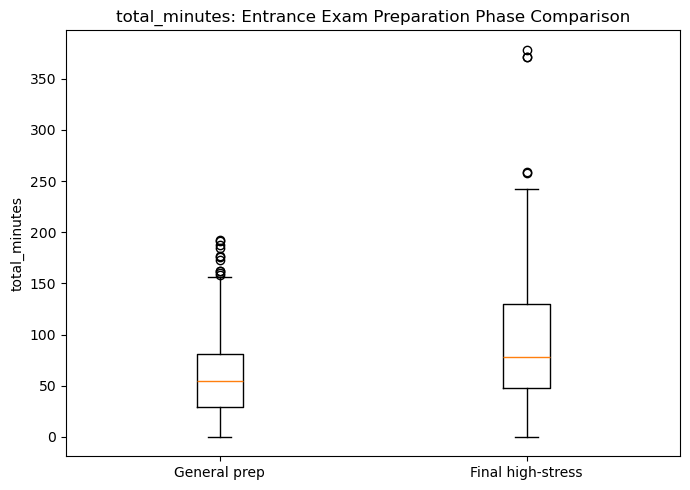

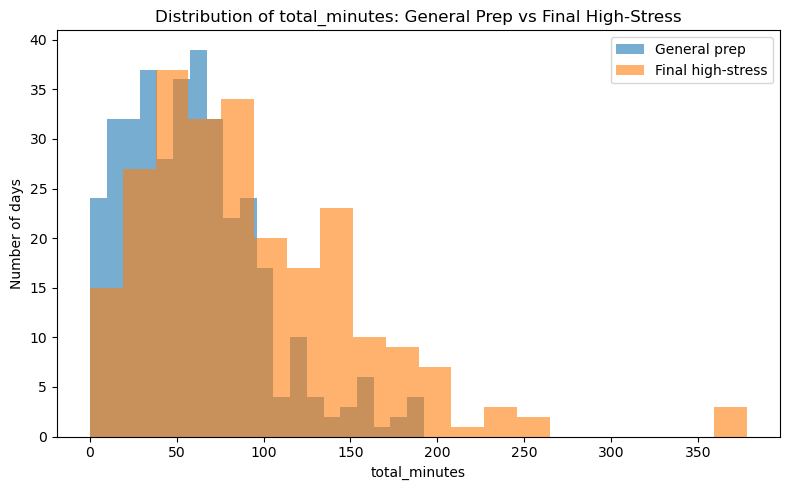

/var/folders/6s/_z262h2n0730l977pljhpqvm0000gn/T/ipykernel_66857/2993423167.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([general, high_stress], labels=["General prep", "Final high-stress"])


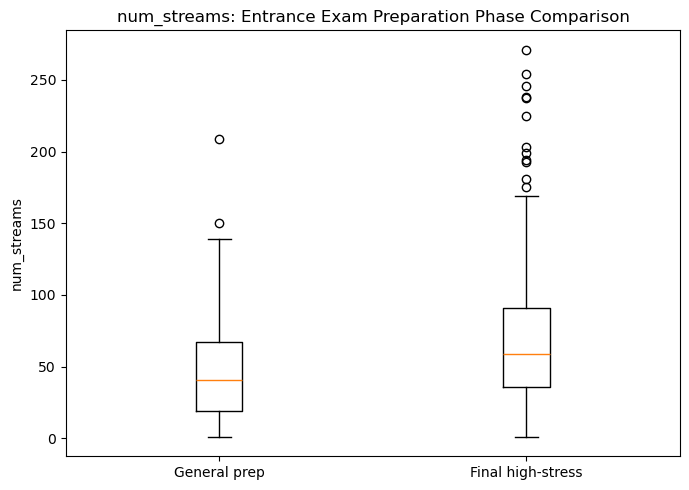

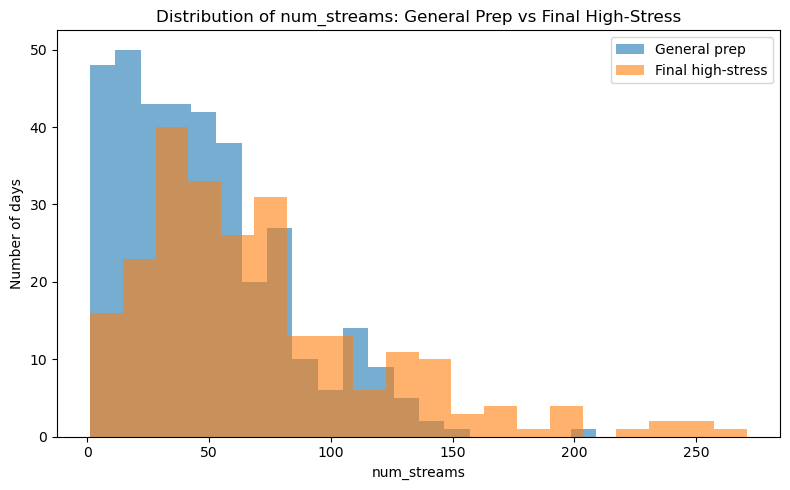

/var/folders/6s/_z262h2n0730l977pljhpqvm0000gn/T/ipykernel_66857/2993423167.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([general, high_stress], labels=["General prep", "Final high-stress"])


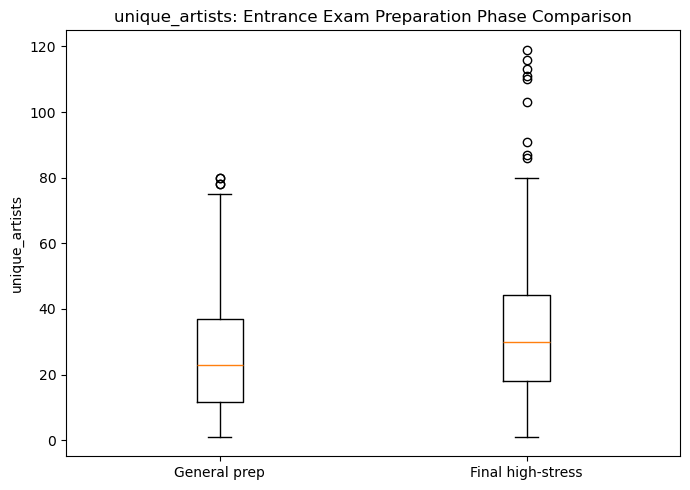

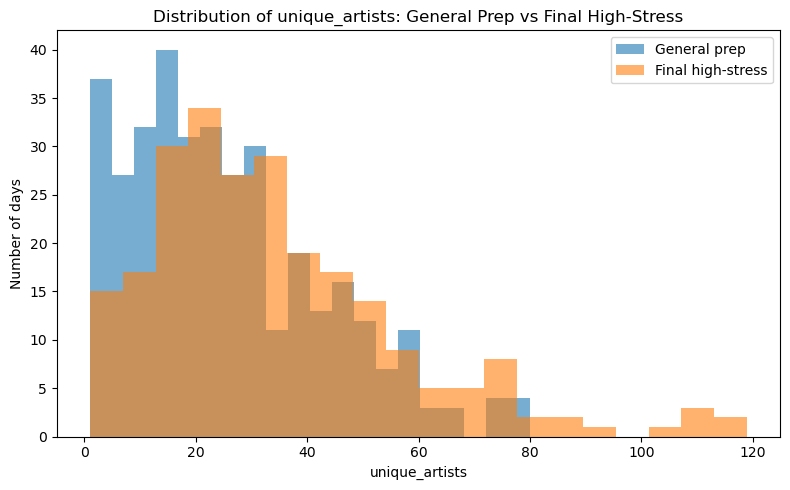

In [89]:
entrance_metrics = [
    metric for metric in ["total_minutes", "num_streams", "unique_artists", "skip_rate", "shuffle_rate"]
    if metric in entrance_focus_df.columns
]

if entrance_focus_df.empty or not entrance_metrics:
    display(Markdown("Entrance-exam preparation comparison is unavailable because no overlapping metrics were found."))
else:
    entrance_mean_table = entrance_focus_df.groupby("is_entrance_exam_high_stress")[entrance_metrics].mean()
    entrance_median_table = entrance_focus_df.groupby("is_entrance_exam_high_stress")[entrance_metrics].median()

    print("Mean behavior: general preparation vs final high-stress phase")
    display(entrance_mean_table.round(3))
    print("Median behavior: general preparation vs final high-stress phase")
    display(entrance_median_table.round(3))

    for metric in ["total_minutes", "num_streams", "unique_artists"]:
        if metric not in entrance_focus_df.columns:
            continue

        general = pd.to_numeric(
            entrance_focus_df.loc[entrance_focus_df["is_entrance_exam_high_stress"] == 0, metric],
            errors="coerce",
        ).dropna()
        high_stress = pd.to_numeric(
            entrance_focus_df.loc[entrance_focus_df["is_entrance_exam_high_stress"] == 1, metric],
            errors="coerce",
        ).dropna()

        if len(general) > 0 and len(high_stress) > 0:
            plt.figure(figsize=(7, 5))
            plt.boxplot([general, high_stress], labels=["General prep", "Final high-stress"])
            plt.title(f"{metric}: Entrance Exam Preparation Phase Comparison")
            plt.ylabel(metric)
            plt.tight_layout()
            plt.show()

            plt.figure(figsize=(8, 5))
            plt.hist(general, bins=20, alpha=0.6, label="General prep")
            plt.hist(high_stress, bins=20, alpha=0.6, label="Final high-stress")
            plt.title(f"Distribution of {metric}: General Prep vs Final High-Stress")
            plt.xlabel(metric)
            plt.ylabel("Number of days")
            plt.legend()
            plt.tight_layout()
            plt.show()

In [90]:
if not entrance_focus_df.empty and {"total_minutes", "num_streams", "unique_artists"}.issubset(entrance_focus_df.columns):
    summary = entrance_focus_df.groupby("is_entrance_exam_high_stress")[["total_minutes", "num_streams", "unique_artists"]].mean()
    if {0, 1}.issubset(set(summary.index)):
        changes = summary.loc[1] - summary.loc[0]
        display(Markdown(
            f"**Insight:** During the final entrance-exam high-stress phase, average daily listening changes by "
            f"**{changes['total_minutes']:.1f} minutes**, **{changes['num_streams']:.1f} streams**, and "
            f"**{changes['unique_artists']:.1f} unique artists** relative to general preparation months. "
            "A decrease can suggest routine compression or reduced leisure time, while an increase can suggest coping, background listening, or greater reliance on music for emotional regulation."
        ))

**Insight:** During the final entrance-exam high-stress phase, average daily listening changes by **33.1 minutes**, **23.9 streams**, and **8.9 unique artists** relative to general preparation months. A decrease can suggest routine compression or reduced leisure time, while an increase can suggest coping, background listening, or greater reliance on music for emotional regulation.

## LGS vs YKS Context Comparison

LGS and YKS occurred at different life stages. Comparing them is exploratory, but useful: it can reveal whether later university-entrance preparation produced a different listening pattern than earlier high-school-entrance preparation.

total_minutes               num_streams               unique_artists               skip_rate             
                           count   mean median       count   mean median          count   mean median     count  mean median
entrance_exam_type                                                                                                          
LGS                          301  81.83  68.58         301  61.20   51.0            301  29.81   25.0       301  0.00   0.00
YKS                          298  62.71  56.37         298  52.33   45.5            298  28.14   25.0       298  0.65   0.67

/var/folders/6s/_z262h2n0730l977pljhpqvm0000gn/T/ipykernel_66857/2999981965.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([lgs_values, yks_values], labels=["LGS prep", "YKS prep"])


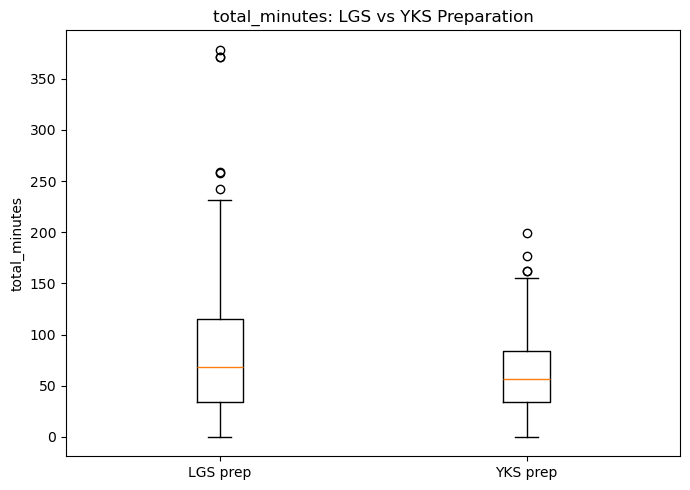

/var/folders/6s/_z262h2n0730l977pljhpqvm0000gn/T/ipykernel_66857/2999981965.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([lgs_values, yks_values], labels=["LGS prep", "YKS prep"])


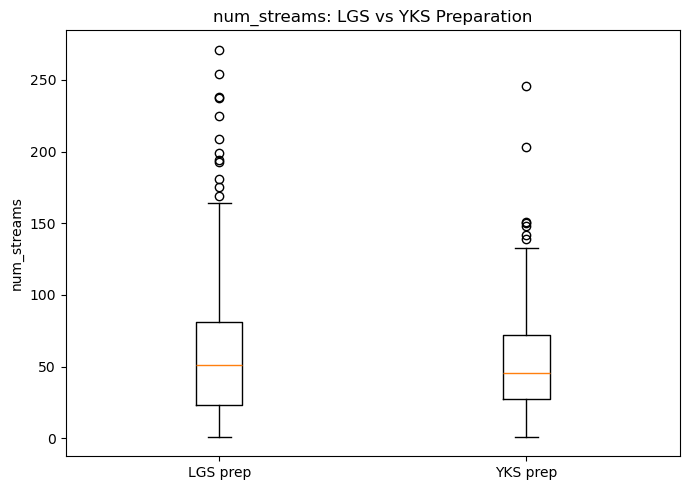

/var/folders/6s/_z262h2n0730l977pljhpqvm0000gn/T/ipykernel_66857/2999981965.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([lgs_values, yks_values], labels=["LGS prep", "YKS prep"])


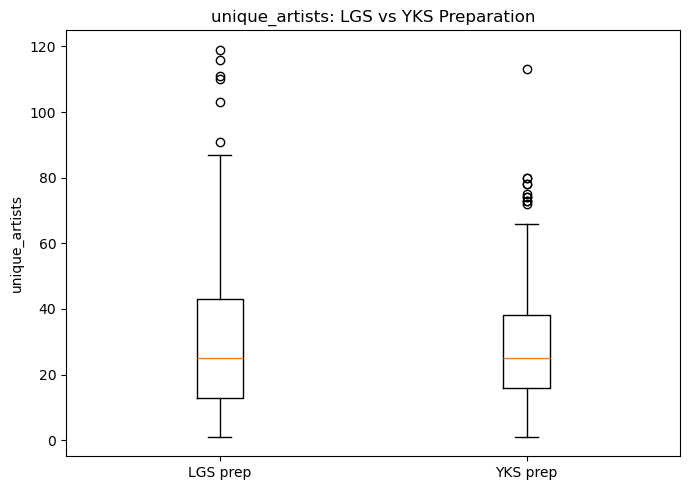

In [91]:
if entrance_focus_df.empty:
    display(Markdown("LGS/YKS comparison is unavailable because no entrance-exam listening days overlap with Spotify data."))
else:
    exam_type_summary = (
        entrance_focus_df.groupby("entrance_exam_type")[["total_minutes", "num_streams", "unique_artists", "skip_rate"]]
        .agg(["count", "mean", "median"])
        .round(2)
    )
    display(exam_type_summary)

    for metric in ["total_minutes", "num_streams", "unique_artists"]:
        lgs_values = pd.to_numeric(entrance_focus_df.loc[entrance_focus_df["entrance_exam_type"] == "LGS", metric], errors="coerce").dropna()
        yks_values = pd.to_numeric(entrance_focus_df.loc[entrance_focus_df["entrance_exam_type"] == "YKS", metric], errors="coerce").dropna()

        if len(lgs_values) > 0 and len(yks_values) > 0:
            plt.figure(figsize=(7, 5))
            plt.boxplot([lgs_values, yks_values], labels=["LGS prep", "YKS prep"])
            plt.title(f"{metric}: LGS vs YKS Preparation")
            plt.ylabel(metric)
            plt.tight_layout()
            plt.show()

In [92]:
if not entrance_focus_df.empty:
    display(Markdown(
        "**Context insight:** The LGS-YKS comparison should be interpreted carefully because age, school environment, technology habits, and Spotify usage maturity may differ between 2019-2020 and 2023-2024. "
        "Still, it is useful as a within-person comparison of two major academic preparation contexts."
    ))

**Context insight:** The LGS-YKS comparison should be interpreted carefully because age, school environment, technology habits, and Spotify usage maturity may differ between 2019-2020 and 2023-2024. Still, it is useful as a within-person comparison of two major academic preparation contexts.

# Additional Hypothesis Tests for Entrance Exam Preparation

These tests are restricted to LGS/YKS preparation days. This makes the control group conceptually cleaner: final high-stress months are compared with general preparation months rather than with unrelated years.

In [93]:
entrance_hypothesis_results = []


def entrance_decision(p_value, alpha=ENTRANCE_ALPHA):
    if pd.isna(p_value):
        return "Test not run"
    return "Reject H0" if p_value < alpha else "Fail to reject H0"


def entrance_run_ttest(df, group_column, metric_column, hypothesis_name, group_1_label="1", group_0_label="0"):
    if df.empty or group_column not in df.columns or metric_column not in df.columns:
        print(f"{hypothesis_name}: skipped because required data are missing.")
        entrance_hypothesis_results.append({
            "hypothesis": hypothesis_name,
            "test": "Welch two-sample t-test",
            "n_group_1": np.nan,
            "n_group_0": np.nan,
            "statistic": np.nan,
            "p_value": np.nan,
            "decision": "Test not run",
        })
        return None

    group_1 = pd.to_numeric(df.loc[df[group_column] == 1, metric_column], errors="coerce").dropna()
    group_0 = pd.to_numeric(df.loc[df[group_column] == 0, metric_column], errors="coerce").dropna()

    print(f"\n{hypothesis_name}")
    print(f"n {group_1_label}: {len(group_1)}")
    print(f"n {group_0_label}: {len(group_0)}")

    if len(group_1) < 2 or len(group_0) < 2:
        print("Not enough observations in both groups to run the test.")
        entrance_hypothesis_results.append({
            "hypothesis": hypothesis_name,
            "test": "Welch two-sample t-test",
            "n_group_1": len(group_1),
            "n_group_0": len(group_0),
            "statistic": np.nan,
            "p_value": np.nan,
            "decision": "Test not run",
        })
        return None

    statistic, p_value = ttest_ind(group_1, group_0, equal_var=False, nan_policy="omit")
    decision = entrance_decision(p_value)

    print(f"t-statistic: {statistic:.4f}")
    print(f"p-value: {p_value:.6f}")
    print(f"Decision at alpha={ENTRANCE_ALPHA}: {decision}")
    print(f"mean {group_1_label}: {group_1.mean():.3f}")
    print(f"mean {group_0_label}: {group_0.mean():.3f}")

    entrance_hypothesis_results.append({
        "hypothesis": hypothesis_name,
        "test": "Welch two-sample t-test",
        "n_group_1": len(group_1),
        "n_group_0": len(group_0),
        "statistic": statistic,
        "p_value": p_value,
        "decision": decision,
    })
    return statistic, p_value, decision, group_1.mean(), group_0.mean()

## H9 - Listening Time During Final Entrance-Exam Stress

**H0:** Mean daily listening time is the same during final entrance-exam high-stress months and general preparation months.

**HA:** Mean daily listening time differs during final entrance-exam high-stress months.

In [94]:
h9_result = entrance_run_ttest(
    entrance_focus_df,
    "is_entrance_exam_high_stress",
    "total_minutes",
    "H9: entrance-exam high-stress phase vs general preparation - listening time",
    "final high-stress",
    "general preparation",
)

if h9_result is not None:
    _, p_value, decision, high_mean, general_mean = h9_result
    direction = "higher" if high_mean > general_mean else "lower"
    display(Markdown(
        f"**H9 conclusion:** {decision}. Average listening time is **{direction}** during the final high-stress phase "
        f"({high_mean:.1f} vs {general_mean:.1f} minutes). This result speaks directly to whether long-term entrance-exam pressure changes daily listening intensity."
    ))


H9: entrance-exam high-stress phase vs general preparation - listening time
n final high-stress: 240
n general preparation: 359
t-statistic: 7.2356
p-value: 0.000000
Decision at alpha=0.05: Reject H0
mean final high-stress: 92.176
mean general preparation: 59.037


**H9 conclusion:** Reject H0. Average listening time is **higher** during the final high-stress phase (92.2 vs 59.0 minutes). This result speaks directly to whether long-term entrance-exam pressure changes daily listening intensity.

## H10 - Artist Diversity During Final Entrance-Exam Stress

**H0:** Mean artist diversity is the same during final entrance-exam high-stress months and general preparation months.

**HA:** Mean artist diversity differs during final entrance-exam high-stress months.

In [95]:
h10_result = entrance_run_ttest(
    entrance_focus_df,
    "is_entrance_exam_high_stress",
    "unique_artists",
    "H10: entrance-exam high-stress phase vs general preparation - artist diversity",
    "final high-stress",
    "general preparation",
)

if h10_result is not None:
    _, p_value, decision, high_mean, general_mean = h10_result
    direction = "higher" if high_mean > general_mean else "lower"
    display(Markdown(
        f"**H10 conclusion:** {decision}. Artist diversity is **{direction}** during the final high-stress phase "
        f"({high_mean:.1f} vs {general_mean:.1f} unique artists). Lower diversity may suggest comfort/repetition, while higher diversity may suggest exploratory coping."
    ))


H10: entrance-exam high-stress phase vs general preparation - artist diversity
n final high-stress: 240
n general preparation: 359
t-statistic: 5.0794
p-value: 0.000001
Decision at alpha=0.05: Reject H0
mean final high-stress: 34.308
mean general preparation: 25.421


**H10 conclusion:** Reject H0. Artist diversity is **higher** during the final high-stress phase (34.3 vs 25.4 unique artists). Lower diversity may suggest comfort/repetition, while higher diversity may suggest exploratory coping.

## H11 - Listening Frequency During Final Entrance-Exam Stress

**H0:** Mean daily stream count is the same during final entrance-exam high-stress months and general preparation months.

**HA:** Mean daily stream count differs during final entrance-exam high-stress months.

In [96]:
h11_result = entrance_run_ttest(
    entrance_focus_df,
    "is_entrance_exam_high_stress",
    "num_streams",
    "H11: entrance-exam high-stress phase vs general preparation - stream count",
    "final high-stress",
    "general preparation",
)

if h11_result is not None:
    _, p_value, decision, high_mean, general_mean = h11_result
    direction = "higher" if high_mean > general_mean else "lower"
    display(Markdown(
        f"**H11 conclusion:** {decision}. Stream count is **{direction}** during the final high-stress phase "
        f"({high_mean:.1f} vs {general_mean:.1f} streams). This helps distinguish longer listening from more frequent, fragmented interaction."
    ))


H11: entrance-exam high-stress phase vs general preparation - stream count
n final high-stress: 240
n general preparation: 359
t-statistic: 6.3397
p-value: 0.000000
Decision at alpha=0.05: Reject H0
mean final high-stress: 71.108
mean general preparation: 47.214


**H11 conclusion:** Reject H0. Stream count is **higher** during the final high-stress phase (71.1 vs 47.2 streams). This helps distinguish longer listening from more frequent, fragmented interaction.

## H12 - LGS vs YKS Preparation Listening

**H0:** Mean daily listening behavior is the same during LGS and YKS preparation periods.

**HA:** Mean daily listening behavior differs between LGS and YKS preparation periods.

This test is exploratory because the two periods happen at different ages and life stages.

In [97]:
lgs_yks_df = entrance_focus_df.loc[entrance_focus_df["entrance_exam_type"].isin(["LGS", "YKS"])].copy()
lgs_yks_df["is_yks_context"] = (lgs_yks_df["entrance_exam_type"] == "YKS").astype(int)

h12_result = entrance_run_ttest(
    lgs_yks_df,
    "is_yks_context",
    "total_minutes",
    "H12: YKS preparation vs LGS preparation - listening time",
    "YKS preparation",
    "LGS preparation",
)

if h12_result is not None:
    _, p_value, decision, yks_mean, lgs_mean = h12_result
    direction = "higher" if yks_mean > lgs_mean else "lower"
    display(Markdown(
        f"**H12 conclusion:** {decision}. Average listening time is **{direction}** during YKS preparation than LGS preparation "
        f"({yks_mean:.1f} vs {lgs_mean:.1f} minutes). This may reflect not only exam context, but also changes in age, habits, autonomy, and Spotify usage over time."
    ))


H12: YKS preparation vs LGS preparation - listening time
n YKS preparation: 298
n LGS preparation: 301
t-statistic: -4.5120
p-value: 0.000008
Decision at alpha=0.05: Reject H0
mean YKS preparation: 62.705
mean LGS preparation: 81.829


**H12 conclusion:** Reject H0. Average listening time is **lower** during YKS preparation than LGS preparation (62.7 vs 81.8 minutes). This may reflect not only exam context, but also changes in age, habits, autonomy, and Spotify usage over time.

In [98]:
entrance_hypothesis_results_df = pd.DataFrame(entrance_hypothesis_results)
display(entrance_hypothesis_results_df)

display(Markdown(
    "**Entrance-exam update summary:** Adding LGS and YKS creates a stronger long-term academic stress layer. "
    "The key methodological improvement is that final high-stress months are compared against general preparation months from the same entrance-exam periods, not against unrelated years. "
    "This makes the interpretation clearer: any detected shift is more plausibly tied to entrance-exam preparation context."
))

,hypothesis,test,n_group_1,n_group_0,statistic,p_value,decision
0,H9: entrance-exam high-stress phase vs general...,Welch two-sample t-test,240,359,7.235622,2.780919e-12,Reject H0
1,H10: entrance-exam high-stress phase vs genera...,Welch two-sample t-test,240,359,5.079422,5.666263e-07,Reject H0
2,H11: entrance-exam high-stress phase vs genera...,Welch two-sample t-test,240,359,6.339704,6.522215e-10,Reject H0
3,H12: YKS preparation vs LGS preparation - list...,Welch two-sample t-test,298,301,-4.511975,8.061537e-06,Reject H0


**Entrance-exam update summary:** Adding LGS and YKS creates a stronger long-term academic stress layer. The key methodological improvement is that final high-stress months are compared against general preparation months from the same entrance-exam periods, not against unrelated years. This makes the interpretation clearer: any detected shift is more plausibly tied to entrance-exam preparation context.